## 1. Instalación de librerías y configuración del entorno reproducible

**Objetivo de esta celda:** preparar un entorno de ejecución determinista y dotado
de todas las librerías que se emplearán a lo largo del pipeline (forecasting
clásico, forecasting con aprendizaje profundo, gradient boosting y optimización
matemática para la fase de inventario).

**Por qué es necesario justificarlo:**
- La **fijación de semillas** (SEMILLA_GLOBAL) es lo que permite que los
  resultados reportados en la memoria sean reproducibles por el tribunal si
  se re-ejecuta el notebook.
- Se documenta explícitamente si el entorno dispone de GPU, porque esto
  condiciona los tiempos de entrenamiento de los modelos de PyTorch
  Forecasting/Darts que se usarán en celdas posteriores.
- La estructura de carpetas (datos_crudos, datos_procesados,
  modelos_entrenados, figuras, resultados) refleja una separación
  metodológica estándar en proyectos de ciencia de datos (principio de
  raw vs. processed data), evitando sobrescribir el dataset original.

In [ ]:
# ==============================================================================
# CELDA 1: INSTALACIÓN DE LIBRERÍAS Y CONFIGURACIÓN INICIAL DEL ENTORNO
# TFM: Pipeline de Forecasting y Optimización de Supply Chain Farmacéutico
# ==============================================================================
# JUSTIFICACIÓN METODOLÓGICA DE ESTA CELDA (para la defensa oral):
# Esta celda no realiza ningún análisis: su única función es dejar el entorno
# de Google Colab en un estado CONTROLADO y REPRODUCIBLE antes de tocar el
# dataset. Esto es un requisito de rigor científico: cualquier resultado
# posterior (métricas de error, pesos de un modelo, política de inventario
# óptima) debe poder reproducirse ejecutando este mismo notebook de nuevo.
# ==============================================================================

# ------------------------------------------------------------------------
# 1.1 Instalación de librerías necesarias en el entorno de Google Colab
# ------------------------------------------------------------------------
# Se agrupan por la fase del pipeline en la que se emplearán, para que quede
# trazable qué librería sirve a qué parte de la memoria del TFM:
#   - torch / pytorch-lightning / pytorch-forecasting / darts -> Modelos de
#     forecasting basados en aprendizaje profundo (TFT, N-BEATS, DeepAR, etc.)
#   - lightgbm / xgboost / catboost -> Modelos de gradient boosting, empleados
#     como baseline robusto frente a los modelos de deep learning.
#   - statsmodels / pmdarima / prophet -> Modelos estadísticos clásicos de
#     series temporales (ARIMA/SARIMAX, descomposición, Prophet), usados como
#     baseline de referencia y para el análisis exploratorio de estacionalidad.
#   - pulp -> Resolución de problemas de optimización lineal entera, empleado
#     en la fase final de optimización de inventario (cantidad económica de
#     pedido, política de reabastecimiento, restricciones de capacidad).
#   - holidays -> Construcción de la covariable exógena de festivos oficiales
#     por país, relevante porque el dataset cubre 19 países distintos.
!pip install --quiet --upgrade pip

!pip install --quiet torch torchvision torchaudio
!pip install --quiet pytorch-lightning
!pip install --quiet pytorch-forecasting
!pip install --quiet darts
!pip install --quiet lightgbm
!pip install --quiet xgboost
!pip install --quiet catboost
!pip install --quiet statsmodels
!pip install --quiet pmdarima
!pip install --quiet prophet
!pip install --quiet pulp
!pip install --quiet scikit-learn
!pip install --quiet optuna
!pip install --quiet shap
!pip install --quiet holidays
!pip install --quiet plotly
!pip install --quiet kaleido
!pip install --quiet openpyxl
!pip install --quiet pyarrow
!pip install --quiet missingno

# ------------------------------------------------------------------------
# 1.2 Importación de librerías base
# ------------------------------------------------------------------------
import os
import sys
import random
import warnings
import datetime
import math
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import torch
import pytorch_lightning as pl

import lightgbm as lgb
import xgboost as xgb
import catboost as cb

import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss

import pulp

import holidays

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# ------------------------------------------------------------------------
# 1.3 Configuración de warnings y visualización
# ------------------------------------------------------------------------
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: "%.4f" % x)

sns.set_style("whitegrid")
sns.set_context("notebook")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# ------------------------------------------------------------------------
# 1.4 Fijación de semillas para garantizar reproducibilidad total
# ------------------------------------------------------------------------
SEMILLA_GLOBAL = 42

def fijar_semillas_reproducibilidad(semilla: int = SEMILLA_GLOBAL) -> None:
    """
    Fija todas las semillas aleatorias relevantes en el entorno de ejecución
    para garantizar la reproducibilidad exacta de los resultados del pipeline
    a lo largo de todas las celdas del Trabajo Fin de Máster. Esto cubre tanto
    la generación de números aleatorios de Python y NumPy como la de PyTorch
    (CPU y GPU), que es la fuente de aleatoriedad más habitual en modelos de
    aprendizaje profundo (inicialización de pesos, dropout, mezclado de lotes).
    """
    random.seed(semilla)
    np.random.seed(semilla)
    os.environ["PYTHONHASHSEED"] = str(semilla)
    torch.manual_seed(semilla)
    torch.cuda.manual_seed(semilla)
    torch.cuda.manual_seed_all(semilla)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    pl.seed_everything(semilla, workers=True)

fijar_semillas_reproducibilidad(SEMILLA_GLOBAL)

# ------------------------------------------------------------------------
# 1.5 Verificación del entorno de cómputo disponible (CPU / GPU)
# ------------------------------------------------------------------------
DISPOSITIVO_COMPUTO = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 80)
print("CONFIGURACIÓN DEL ENTORNO DE EJECUCIÓN")
print("=" * 80)
print(f"Versión de Python en ejecución            : {sys.version.split()[0]}")
print(f"Versión de PyTorch instalada               : {torch.__version__}")
print(f"Versión de PyTorch Lightning instalada     : {pl.__version__}")
print(f"Disponibilidad de GPU (CUDA)                : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Nombre de la GPU asignada                  : {torch.cuda.get_device_name(0)}")
print(f"Dispositivo de cómputo seleccionado         : {DISPOSITIVO_COMPUTO}")
print(f"Semilla global fijada                       : {SEMILLA_GLOBAL}")
print("=" * 80)

# ------------------------------------------------------------------------
# 1.6 Creación de estructura de directorios de trabajo del proyecto
# ------------------------------------------------------------------------
# Se separan datos crudos (inmutables, tal cual se descargaron) de datos
# procesados (resultado de la Celda 2), modelos entrenados, figuras y
# resultados numéricos finales. Esta separación evita el error metodológico
# habitual de sobrescribir accidentalmente el dataset original.
RUTA_BASE_PROYECTO = "/content/tfm_supply_chain_farmaceutico"
RUTA_DATOS_CRUDOS = os.path.join(RUTA_BASE_PROYECTO, "datos_crudos")
RUTA_DATOS_PROCESADOS = os.path.join(RUTA_BASE_PROYECTO, "datos_procesados")
RUTA_MODELOS = os.path.join(RUTA_BASE_PROYECTO, "modelos_entrenados")
RUTA_FIGURAS = os.path.join(RUTA_BASE_PROYECTO, "figuras")
RUTA_RESULTADOS = os.path.join(RUTA_BASE_PROYECTO, "resultados")

for ruta in [RUTA_BASE_PROYECTO, RUTA_DATOS_CRUDOS, RUTA_DATOS_PROCESADOS,
             RUTA_MODELOS, RUTA_FIGURAS, RUTA_RESULTADOS]:
    os.makedirs(ruta, exist_ok=True)

print("\nEstructura de directorios del proyecto creada correctamente en:")
print(RUTA_BASE_PROYECTO)

# ------------------------------------------------------------------------
# 1.7 Log metodológico de la celda (resumen para preparar la defensa)
# ------------------------------------------------------------------------
print("\n" + "=" * 80)
print("LOG METODOLÓGICO — CELDA 1")
print("=" * 80)
print(
    "Decisión 1: Se fija SEMILLA_GLOBAL = 42 en Python, NumPy, PyTorch y "
    "PyTorch Lightning simultáneamente, porque un pipeline con múltiples "
    "familias de modelos (deep learning, boosting, estadístico) necesita "
    "reproducibilidad en TODAS las fuentes de aleatoriedad, no solo en una."
)
print(
    "Decisión 2: Se separan cinco directorios de trabajo (crudos, procesados, "
    "modelos, figuras, resultados) siguiendo el principio de trazabilidad de "
    "datos: el archivo original nunca se sobrescribe, de modo que cualquier "
    "paso del pipeline pueda repetirse desde cero sin volver a descargar nada."
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 38.8 MB/s eta 0:00:00


INFO:lightning_fabric.utilities.seed:Seed set to 42


CONFIGURACIÓN DEL ENTORNO DE EJECUCIÓN
Versión de Python en ejecución            : 3.12.13
Versión de PyTorch instalada               : 2.11.0+cu128
Versión de PyTorch Lightning instalada     : 2.6.5
Disponibilidad de GPU (CUDA)                : True
Nombre de la GPU asignada                  : Tesla T4
Dispositivo de cómputo seleccionado         : cuda
Semilla global fijada                       : 42

Estructura de directorios del proyecto creada correctamente en:
/content/tfm_supply_chain_farmaceutico

LOG METODOLÓGICO — CELDA 1
Decisión 1: Se fija SEMILLA_GLOBAL = 42 en Python, NumPy, PyTorch y PyTorch Lightning simultáneamente, porque un pipeline con múltiples familias de modelos (deep learning, boosting, estadístico) necesita reproducibilidad en TODAS las fuentes de aleatoriedad, no solo en una.
Decisión 2: Se separan cinco directorios de trabajo (crudos, procesados, modelos, figuras, resultados) siguiendo el principio de trazabilidad de datos: el archivo original nunca se sobresc

## 2. Carga, limpieza, covariables temporales y módulo sociodemográfico Patient-Centric

**Objetivo de esta celda:** convertir el dataset transaccional crudo en una
serie temporal diaria continua, limpia, con covariables de calendario,
festivos y crisis sanitaria, y con el cruce sociodemográfico obligatorio
(edad del paciente × ubicación geográfica).

**Hallazgo metodológico que se explica y justifica dentro del código:**
el dataset real, pese a llamarse "daily dataset", no contiene una fila por
cada día y combinación (país, medicamento, grupo de edad): la demanda es
intermitente (solo entre un 6% y un 9% de los días tienen transacción
registrada para una combinación dada). Por tanto, "garantizar formato diario"
exige densificar el calendario mediante reindexado, imputando cero ventas
en los días sin transacción. Esta decisión se justifica explícitamente porque
condiciona qué modelos son apropiados más adelante (demanda intermitente vs.
demanda continua).

In [ ]:
# ==============================================================================
# CELDA 2: CARGA DEL DATASET, LIMPIEZA, INGENIERÍA DE COVARIABLES TEMPORALES
# Y MÓDULO OBLIGATORIO SOCIODEMOGRÁFICO (PATIENT-CENTRIC)
# ==============================================================================
# JUSTIFICACIÓN METODOLÓGICA GENERAL DE ESTA CELDA (para la defensa oral):
# El dataset original ("global_pharmacy_sales_2020_2025_daily_dataset.csv")
# es de naturaleza TRANSACCIONAL: cada fila es una venta registrada de un
# medicamento concreto, en un país concreto, para un grupo de edad concreto,
# en una fecha concreta. NO es, pese a su nombre, una serie temporal diaria
# ya construida. Por tanto esta celda tiene dos responsabilidades distintas
# y bien diferenciadas, que se documentan por separado:
#   (A) Limpieza y transformación del dato transaccional (duplicados, nulos,
#       tipado de fechas).
#   (B) Construcción de la SERIE TEMPORAL propiamente dicha, mediante
#       agregación diaria por combinación (país, medicamento, grupo de edad)
#       y posterior densificación del calendario.
# ==============================================================================

# ------------------------------------------------------------------------
# 2.1 Definición de rutas y mapeo de nombres de columnas del dataset real
# ------------------------------------------------------------------------
# El archivo fue inspeccionado previamente y su esquema real es el siguiente:
#   date, year, month, day, region, country, category, medicine, age_group,
#   units_sold, unit_price, stock_level, expiry_days_remaining, covid_flag
# No existen columnas de tienda (store_id), producto individual (product_id),
# ciudad (city), ingresos (revenue), género (gender) ni receta (prescription).
# Esto es relevante para el TFM: el nivel de granularidad geográfica más fino
# disponible es el PAÍS (no la ciudad), y el nivel de "unidad de venta" más
# fino es la combinación (país, medicamento, grupo de edad), no una farmacia
# individual. Esta limitación se declara explícitamente en la memoria.

NOMBRE_ARCHIVO_ORIGEN = "global_pharmacy_sales_2020_2025_daily_dataset.csv"
RUTA_ARCHIVO_ORIGEN = os.path.join(RUTA_DATOS_CRUDOS, NOMBRE_ARCHIVO_ORIGEN)

# Si el archivo se subió directamente al panel de archivos de Colab en lugar
# de a la carpeta de trabajo del proyecto, se busca también en /content y en
# /mnt/user-data/uploads (ruta habitual cuando se sube desde el chat).
RUTAS_ALTERNATIVAS_BUSQUEDA = [
    RUTA_ARCHIVO_ORIGEN,
    os.path.join("/content", NOMBRE_ARCHIVO_ORIGEN),
    os.path.join("/mnt/user-data/uploads", NOMBRE_ARCHIVO_ORIGEN),
]

RUTA_ARCHIVO_ENCONTRADA = None
for ruta_candidata in RUTAS_ALTERNATIVAS_BUSQUEDA:
    if os.path.exists(ruta_candidata):
        RUTA_ARCHIVO_ENCONTRADA = ruta_candidata
        break

if RUTA_ARCHIVO_ENCONTRADA is None:
    raise FileNotFoundError(
        f"No se ha encontrado '{NOMBRE_ARCHIVO_ORIGEN}' en ninguna de las "
        f"rutas esperadas: {RUTAS_ALTERNATIVAS_BUSQUEDA}. Suba el archivo a "
        "la carpeta 'datos_crudos' o al panel de archivos de Colab."
    )

MAPEO_COLUMNAS_ORIGEN = {
    "date": "fecha",
    "region": "region",
    "country": "pais",
    "category": "categoria_producto",
    "medicine": "medicamento",
    "age_group": "grupo_edad",
    "units_sold": "unidades_vendidas",
    "unit_price": "precio_unitario",
    "stock_level": "nivel_inventario",
    "expiry_days_remaining": "dias_restantes_caducidad",
    "covid_flag": "indicador_covid_fuente_original",
}

# ------------------------------------------------------------------------
# 2.2 Carga del dataset transaccional crudo
# ------------------------------------------------------------------------
dataframe_transaccional_crudo = pd.read_csv(RUTA_ARCHIVO_ENCONTRADA)
dataframe_transaccional_crudo = dataframe_transaccional_crudo.rename(columns=MAPEO_COLUMNAS_ORIGEN)

# Las columnas year/month/day del archivo original son redundantes respecto
# a 'date': se descartan aquí y se reconstruyen más adelante a partir de la
# columna 'fecha' ya tipada como datetime, para evitar inconsistencias entre
# ambas fuentes de la misma información.
for columna_redundante in ["year", "month", "day"]:
    if columna_redundante in dataframe_transaccional_crudo.columns:
        dataframe_transaccional_crudo = dataframe_transaccional_crudo.drop(columns=[columna_redundante])

print("=" * 80)
print("CARGA INICIAL DEL DATASET TRANSACCIONAL")
print("=" * 80)
print(f"Archivo cargado desde                       : {RUTA_ARCHIVO_ENCONTRADA}")
print(f"Número de filas cargadas                    : {dataframe_transaccional_crudo.shape[0]}")
print(f"Número de columnas cargadas                 : {dataframe_transaccional_crudo.shape[1]}")
print(f"Columnas disponibles tras el mapeo           : {list(dataframe_transaccional_crudo.columns)}")
print("=" * 80)

# ------------------------------------------------------------------------
# 2.3 Conversión de tipos y validación de la columna temporal
# ------------------------------------------------------------------------
dataframe_transaccional_crudo["fecha"] = pd.to_datetime(
    dataframe_transaccional_crudo["fecha"], errors="coerce"
)

numero_fechas_invalidas = dataframe_transaccional_crudo["fecha"].isna().sum()
if numero_fechas_invalidas > 0:
    print(f"Se han detectado {numero_fechas_invalidas} registros con fecha inválida. Serán eliminados.")
    dataframe_transaccional_crudo = dataframe_transaccional_crudo.dropna(subset=["fecha"])

# ------------------------------------------------------------------------
# 2.4 Eliminación de duplicados exactos
# ------------------------------------------------------------------------
# Se comprobó en la exploración previa que existen 2.630 filas duplicadas de
# forma EXACTA (idénticas en todas sus columnas), probablemente producto de
# un doble registro en el sistema de origen. Se eliminan por ser información
# redundante, no por ser transacciones legítimas repetidas.
numero_duplicados_detectados = dataframe_transaccional_crudo.duplicated().sum()
dataframe_transaccional_crudo = dataframe_transaccional_crudo.drop_duplicates().reset_index(drop=True)
print(f"Número de filas duplicadas exactas eliminadas: {numero_duplicados_detectados}")

# ------------------------------------------------------------------------
# 2.5 Verificación y tratamiento de valores nulos
# ------------------------------------------------------------------------
# La inspección previa confirmó 0 valores nulos en el archivo original. No
# obstante, se mantiene esta verificación de forma explícita en el pipeline
# (en lugar de omitirla) porque es una buena práctica de robustez: si en el
# futuro se sustituye el archivo de origen por una versión con más registros
# o de otra fuente, el pipeline debe seguir siendo capaz de tratar nulos sin
# fallar silenciosamente.
reporte_nulos = dataframe_transaccional_crudo.isna().sum()
reporte_nulos = reporte_nulos[reporte_nulos > 0].sort_values(ascending=False)

print("\nReporte de valores nulos tras la carga y deduplicación:")
if len(reporte_nulos) > 0:
    print(reporte_nulos)
    dataframe_transaccional_crudo = dataframe_transaccional_crudo.dropna(subset=["unidades_vendidas"])
    dataframe_transaccional_crudo = dataframe_transaccional_crudo[dataframe_transaccional_crudo["unidades_vendidas"] >= 0]
    for columna_categorica in ["pais", "region", "categoria_producto", "medicamento", "grupo_edad"]:
        if columna_categorica in dataframe_transaccional_crudo.columns:
            dataframe_transaccional_crudo[columna_categorica] = dataframe_transaccional_crudo[columna_categorica].fillna("Desconocido")
    for columna_numerica in ["precio_unitario", "nivel_inventario", "dias_restantes_caducidad"]:
        if columna_numerica in dataframe_transaccional_crudo.columns:
            mediana_por_medicamento = dataframe_transaccional_crudo.groupby("medicamento")[columna_numerica].transform("median")
            dataframe_transaccional_crudo[columna_numerica] = dataframe_transaccional_crudo[columna_numerica].fillna(mediana_por_medicamento)
else:
    print("No se detectaron valores nulos: no es necesaria ninguna imputación en este dataset.")

print(f"\nNúmero de filas tras limpieza de duplicados y nulos: {dataframe_transaccional_crudo.shape[0]}")

# ------------------------------------------------------------------------
# 2.6 Cálculo de la variable de ingresos (no presente en el dataset original)
# ------------------------------------------------------------------------
# El dataset origen no incluye una columna de ingresos monetarios: solo
# unidades vendidas y precio unitario. Se deriva 'ingresos_estimados' como
# el producto de ambas, dejando constancia explícita de que es una variable
# CALCULADA y no observada directamente, para no inducir a error en la
# memoria del TFM al presentarla como si fuese un dato bruto de origen.
dataframe_transaccional_crudo["ingresos_estimados"] = (
    dataframe_transaccional_crudo["unidades_vendidas"] * dataframe_transaccional_crudo["precio_unitario"]
)

# ------------------------------------------------------------------------
# 2.7 Definición de la clave de agregación de la serie temporal
# ------------------------------------------------------------------------
# Se eligen (pais, medicamento, grupo_edad) como clave de agregación de la
# serie temporal por tres motivos, que constituyen una decisión de diseño
# a defender explícitamente:
#   1) Es la granularidad geográfica más fina disponible en el dataset
#      (no existe 'city' ni 'store_id').
#   2) 'categoria_producto' es completamente redundante respecto a
#      'medicamento' (mapeo 1 a 1 verificado en la exploración: cada
#      medicamento pertenece siempre a una única categoría), por lo que no
#      es necesario incluirla en la clave sin perder información.
#   3) Mantener 'grupo_edad' como parte de la clave es IMPRESCINDIBLE para
#      preservar la resolución sociodemográfica exigida por el módulo
#      Patient-Centric: si se agregase por encima del grupo de edad, se
#      perdería la capacidad de detectar picos pediátricos vs. geriátricos.
CLAVES_AGRUPACION_SERIE = ["pais", "medicamento", "grupo_edad"]

print(f"\nNúmero de combinaciones únicas (país, medicamento, grupo de edad): "
      f"{dataframe_transaccional_crudo.groupby(CLAVES_AGRUPACION_SERIE).ngroups}")

# Se conserva un mapeo auxiliar (pais -> region, medicamento -> categoria)
# para poder reincorporar esas columnas tras la agregación diaria sin
# duplicar información dentro de la propia clave de agrupación.
mapa_pais_a_region = (
    dataframe_transaccional_crudo[["pais", "region"]]
    .drop_duplicates(subset=["pais"])
    .set_index("pais")["region"]
    .to_dict()
)
mapa_medicamento_a_categoria = (
    dataframe_transaccional_crudo[["medicamento", "categoria_producto"]]
    .drop_duplicates(subset=["medicamento"])
    .set_index("medicamento")["categoria_producto"]
    .to_dict()
)

# ------------------------------------------------------------------------
# 2.8 Agregación diaria por clave (colapsa posibles registros duplicados
# a nivel de negocio que ya no son duplicados exactos de fila)
# ------------------------------------------------------------------------
dataframe_diario_agregado = (
    dataframe_transaccional_crudo
    .groupby(CLAVES_AGRUPACION_SERIE + ["fecha"], as_index=False)
    .agg(
        unidades_vendidas=("unidades_vendidas", "sum"),
        ingresos_estimados=("ingresos_estimados", "sum"),
        precio_unitario=("precio_unitario", "mean"),
        nivel_inventario=("nivel_inventario", "mean"),
        dias_restantes_caducidad=("dias_restantes_caducidad", "mean"),
    )
)

# ------------------------------------------------------------------------
# 2.9 Densificación del calendario: de venta intermitente a serie diaria
# continua (paso metodológico central de esta celda)
# ------------------------------------------------------------------------
# COMO SE EXPLICA EN LA CELDA MARKDOWN ANTERIOR: para una combinación dada de
# (país, medicamento, grupo de edad) solo existe transacción registrada en
# una fracción minoritaria de los días del rango temporal total. Un modelo
# de forecasting necesita, sin embargo, una rejilla temporal COMPLETA y
# regular: los días sin transacción representan demanda real igual a cero
# unidades, no datos ausentes que deban imputarse por interpolación. Esta es
# la diferencia conceptual clave: un hueco en la serie NO es un dato perdido,
# es una observación válida de "cero ventas ese día".
#
# Se construye, por tanto, el producto cartesiano de todas las combinaciones
# (país, medicamento, grupo de edad) observadas frente al rango diario
# completo del dataset (2020-01-01 a 2025-12-31), y se rellenan los huecos.

fecha_minima_dataset = dataframe_diario_agregado["fecha"].min()
fecha_maxima_dataset = dataframe_diario_agregado["fecha"].max()
rango_calendario_completo = pd.date_range(start=fecha_minima_dataset, end=fecha_maxima_dataset, freq="D")

combinaciones_unicas_observadas = (
    dataframe_diario_agregado[CLAVES_AGRUPACION_SERIE]
    .drop_duplicates()
    .reset_index(drop=True)
)

indice_multiple_completo = pd.MultiIndex.from_product(
    [
        combinaciones_unicas_observadas["pais"].unique(),
        combinaciones_unicas_observadas["medicamento"].unique(),
        combinaciones_unicas_observadas["grupo_edad"].unique(),
        rango_calendario_completo,
    ],
    names=CLAVES_AGRUPACION_SERIE + ["fecha"],
)

# NOTA METODOLÓGICA: el producto cartesiano por unique() de cada columna por
# separado generaría combinaciones (país, medicamento, grupo_edad) que nunca
# existieron en los datos originales. Se filtra a continuación quedándonos
# únicamente con las combinaciones realmente observadas en el dataset crudo,
# evitando así "inventar" series completas de ceros para combinaciones que
# el dataset original nunca contempló.
dataframe_calendario_completo = pd.DataFrame(index=indice_multiple_completo).reset_index()
dataframe_calendario_completo = dataframe_calendario_completo.merge(
    combinaciones_unicas_observadas,
    on=CLAVES_AGRUPACION_SERIE,
    how="inner",
)

dataframe_diario = dataframe_calendario_completo.merge(
    dataframe_diario_agregado,
    on=CLAVES_AGRUPACION_SERIE + ["fecha"],
    how="left",
)

dataframe_diario["unidades_vendidas"] = dataframe_diario["unidades_vendidas"].fillna(0.0)
dataframe_diario["ingresos_estimados"] = dataframe_diario["ingresos_estimados"].fillna(0.0)

dataframe_diario = dataframe_diario.sort_values(CLAVES_AGRUPACION_SERIE + ["fecha"]).reset_index(drop=True)
dataframe_diario["precio_unitario"] = (
    dataframe_diario.groupby(CLAVES_AGRUPACION_SERIE)["precio_unitario"].ffill().bfill()
)
dataframe_diario["nivel_inventario"] = (
    dataframe_diario.groupby(CLAVES_AGRUPACION_SERIE)["nivel_inventario"].ffill().bfill()
)
dataframe_diario["dias_restantes_caducidad"] = (
    dataframe_diario.groupby(CLAVES_AGRUPACION_SERIE)["dias_restantes_caducidad"].ffill().bfill()
)

dataframe_diario["region"] = dataframe_diario["pais"].map(mapa_pais_a_region)
dataframe_diario["categoria_producto"] = dataframe_diario["medicamento"].map(mapa_medicamento_a_categoria)

porcentaje_dias_con_venta_real = (
    (dataframe_diario_agregado.shape[0] / dataframe_diario.shape[0]) * 100
)

print("\n" + "=" * 80)
print("DENSIFICACIÓN DEL CALENDARIO: RESULTADO")
print("=" * 80)
print(f"Filas antes de densificar (solo días con venta observada) : {dataframe_diario_agregado.shape[0]}")
print(f"Filas después de densificar (calendario diario completo)  : {dataframe_diario.shape[0]}")
print(f"Porcentaje de días con venta real sobre el total          : {porcentaje_dias_con_venta_real:.2f} %")
print("Esta cifra es la evidencia cuantitativa de la intermitencia de la")
print("demanda y debe citarse en la memoria como justificación del enfoque.")

# ------------------------------------------------------------------------
# 2.10 Ingeniería de covariables temporales de calendario
# ------------------------------------------------------------------------
dataframe_diario["anio"] = dataframe_diario["fecha"].dt.year
dataframe_diario["mes"] = dataframe_diario["fecha"].dt.month
dataframe_diario["dia_del_mes"] = dataframe_diario["fecha"].dt.day
dataframe_diario["dia_de_la_semana"] = dataframe_diario["fecha"].dt.dayofweek
dataframe_diario["nombre_dia_semana"] = dataframe_diario["fecha"].dt.day_name()
dataframe_diario["semana_del_anio"] = dataframe_diario["fecha"].dt.isocalendar().week.astype(int)
dataframe_diario["trimestre"] = dataframe_diario["fecha"].dt.quarter
dataframe_diario["es_fin_de_semana"] = (dataframe_diario["dia_de_la_semana"] >= 5).astype(int)
dataframe_diario["es_inicio_de_mes"] = dataframe_diario["fecha"].dt.is_month_start.astype(int)
dataframe_diario["es_fin_de_mes"] = dataframe_diario["fecha"].dt.is_month_end.astype(int)

# Codificación cíclica (seno/coseno): se emplea en lugar de variables enteras
# simples porque preserva la continuidad circular del calendario (el 31 de
# diciembre y el 1 de enero deben quedar "cerca" en el espacio de la
# covariable, algo que una variable entera 1-365 no representa).
dataframe_diario["seno_dia_del_anio"] = np.sin(2 * np.pi * dataframe_diario["fecha"].dt.dayofyear / 365.25)
dataframe_diario["coseno_dia_del_anio"] = np.cos(2 * np.pi * dataframe_diario["fecha"].dt.dayofyear / 365.25)
dataframe_diario["seno_dia_semana"] = np.sin(2 * np.pi * dataframe_diario["dia_de_la_semana"] / 7)
dataframe_diario["coseno_dia_semana"] = np.cos(2 * np.pi * dataframe_diario["dia_de_la_semana"] / 7)
dataframe_diario["seno_mes"] = np.sin(2 * np.pi * dataframe_diario["mes"] / 12)
dataframe_diario["coseno_mes"] = np.cos(2 * np.pi * dataframe_diario["mes"] / 12)

# ------------------------------------------------------------------------
# 2.11 Covariable exógena de festivos oficiales por país
# ------------------------------------------------------------------------
DICCIONARIO_CODIGOS_PAIS_FESTIVOS = {
    "USA": "US", "UK": "GB", "Germany": "DE", "France": "FR", "India": "IN",
    "China": "CN", "Brazil": "BR", "Canada": "CA", "Australia": "AU",
    "Japan": "JP", "South Korea": "KR", "UAE": "AE", "Saudi Arabia": "SA",
    "Nigeria": "NG", "Kenya": "KE", "New Zealand": "NZ", "Argentina": "AR",
    "Sri Lanka": "LK", "Bangladesh": "BD",
}

diccionario_calendarios_festivos_por_pais = {}
for pais_unico in dataframe_diario["pais"].unique():
    codigo_pais_iso = DICCIONARIO_CODIGOS_PAIS_FESTIVOS.get(pais_unico, "US")
    try:
        diccionario_calendarios_festivos_por_pais[pais_unico] = holidays.CountryHoliday(
            codigo_pais_iso,
            years=range(dataframe_diario["anio"].min(), dataframe_diario["anio"].max() + 1),
        )
    except Exception:
        diccionario_calendarios_festivos_por_pais[pais_unico] = holidays.CountryHoliday(
            "US", years=range(dataframe_diario["anio"].min(), dataframe_diario["anio"].max() + 1)
        )

def calcular_indicador_festivo(fila: pd.Series) -> int:
    calendario_festivos_pais = diccionario_calendarios_festivos_por_pais[fila["pais"]]
    return int(fila["fecha"] in calendario_festivos_pais)

dataframe_diario["es_dia_festivo"] = dataframe_diario.apply(calcular_indicador_festivo, axis=1)

# ------------------------------------------------------------------------
# 2.12 Covariable exógena de pandemia / crisis sanitaria
# ------------------------------------------------------------------------
# El dataset original incluía una columna 'covid_flag' (renombrada aquí a
# 'indicador_covid_fuente_original'), pero esa columna NO sobrevivió a la
# agregación diaria del paso 2.8 ni a la densificación del paso 2.9, ya que
# ninguno de esos dos pasos la incluía explícitamente en sus operaciones.
# En lugar de complicar la agregación para "arrastrar" una columna que ya
# sabemos, por la exploración inicial del dataset, que es COMPLETAMENTE
# DETERMINISTA POR AÑO CALENDARIO (vale 1 en todo 2020 y 2021, y 0 en todo
# 2022-2025), se opta por la solución más simple, transparente y auditable:
# reconstruirla directamente a partir de la columna 'anio' ya calculada en
# el paso 2.10, reproduciendo exactamente la misma regla verificada sobre
# el dataset original.
dataframe_diario["indicador_covid_fuente_original"] = (
    dataframe_diario["anio"].isin([2020, 2021]).astype(int)
)  # <-- LÍNEA AÑADIDA: corrige el KeyError reconstruyendo la columna original

# Por transparencia y trazabilidad hacia la fuente, se conserva dicha columna
# reconstruida, y ADEMÁS se construye una versión propia, más granular, en
# tres niveles de intensidad, que se emplea como covariable adicional en el
# modelado y que sí distingue, por ejemplo, entre el pico agudo de marzo de
# 2020 y una fecha de diciembre de 2021 ya en fase de vacunación avanzada.
FECHA_INICIO_PANDEMIA_COVID = pd.Timestamp("2020-03-11")   # Declaración OMS
FECHA_FIN_FASE_AGUDA_COVID = pd.Timestamp("2021-12-31")
FECHA_INICIO_FASE_ENDEMICA = pd.Timestamp("2022-01-01")
FECHA_FIN_FASE_ENDEMICA = pd.Timestamp("2023-05-05")        # Fin PHEIC OMS

def clasificar_fase_pandemica(fecha_actual: pd.Timestamp) -> int:
    """
    Asigna un indicador de intensidad de crisis sanitaria a cada fecha:
    0 = normalidad, 1 = fase endémica de transición, 2 = fase aguda de la
    pandemia de COVID-19 (máxima disrupción de la cadena de suministro).
    """
    if FECHA_INICIO_PANDEMIA_COVID <= fecha_actual <= FECHA_FIN_FASE_AGUDA_COVID:
        return 2
    elif FECHA_INICIO_FASE_ENDEMICA <= fecha_actual <= FECHA_FIN_FASE_ENDEMICA:
        return 1
    else:
        return 0

dataframe_diario["indicador_fase_pandemia_enriquecido"] = dataframe_diario["fecha"].apply(clasificar_fase_pandemica)
dataframe_diario["es_periodo_pandemia_aguda"] = (dataframe_diario["indicador_fase_pandemia_enriquecido"] == 2).astype(int)

concordancia_con_fuente_original = (
    (dataframe_diario["indicador_covid_fuente_original"] == 1)
    == (dataframe_diario["indicador_fase_pandemia_enriquecido"] >= 1)
).mean() * 100
print(f"\nConcordancia entre el indicador COVID original y el enriquecido: "
      f"{concordancia_con_fuente_original:.2f} %")

# ------------------------------------------------------------------------
# 2.13 MÓDULO OBLIGATORIO SOCIODEMOGRÁFICO PATIENT-CENTRIC
# Cruce de país y grupo de edad para identificar picos pediátricos y
# geriátricos, exigido explícitamente en el diseño del TFM.
# ------------------------------------------------------------------------
# El dataset real no dispone de columna de ciudad, por lo que la ubicación
# geográfica utilizada en este cruce es el PAÍS (nivel más fino disponible).
# Los cinco valores de 'grupo_edad' presentes en los datos son exactamente:
# '0-12', '13-25', '26-45', '46-65', '65+'. Se normalizan a una nomenclatura
# clínica estándar que distingue explícitamente el extremo pediátrico del
# extremo geriátrico, que son los dos segmentos de interés directo del
# enfoque Patient-Centric.
DICCIONARIO_NORMALIZACION_GRUPO_EDAD = {
    "0-12": "Pediatrico",
    "13-25": "Adolescente_Joven",
    "26-45": "Adulto",
    "46-65": "Adulto_Maduro",
    "65+": "Geriatrico",
}

dataframe_diario["segmento_etario_normalizado"] = (
    dataframe_diario["grupo_edad"].map(DICCIONARIO_NORMALIZACION_GRUPO_EDAD)
)
dataframe_diario["es_paciente_pediatrico"] = (
    dataframe_diario["segmento_etario_normalizado"] == "Pediatrico"
).astype(int)
dataframe_diario["es_paciente_geriatrico"] = (
    dataframe_diario["segmento_etario_normalizado"] == "Geriatrico"
).astype(int)

# Construcción de la tabla de perfil sociodemográfico por país: para cada
# país se calcula qué proporción de las unidades vendidas corresponde a cada
# segmento etario, y se deriva un índice de dominancia pediátrico-geriátrico.
tabla_cruce_pais_edad = (
    dataframe_diario
    .groupby(["pais", "segmento_etario_normalizado"], as_index=False)
    .agg(total_unidades_vendidas=("unidades_vendidas", "sum"))
)
tabla_cruce_pais_edad["proporcion_dentro_del_pais"] = (
    tabla_cruce_pais_edad
    .groupby("pais")["total_unidades_vendidas"]
    .transform(lambda serie: serie / serie.sum())
)

tabla_pivote_perfil_sociodemografico = tabla_cruce_pais_edad.pivot_table(
    index="pais",
    columns="segmento_etario_normalizado",
    values="proporcion_dentro_del_pais",
    fill_value=0.0,
).reset_index()

tabla_pivote_perfil_sociodemografico["indice_dominancia_pediatrica_vs_geriatrica"] = (
    tabla_pivote_perfil_sociodemografico.get("Pediatrico", 0.0)
    - tabla_pivote_perfil_sociodemografico.get("Geriatrico", 0.0)
)

def clasificar_perfil_pais(indice_dominancia: float) -> str:
    """
    Clasifica cada país según la dominancia relativa de demanda pediátrica
    frente a geriátrica. El umbral de +/- 0.02 se justifica empíricamente:
    al tratarse de un dataset sintético con 5 segmentos etarios equilibrados
    por diseño (cada uno en torno al 20% de las ventas), desviaciones
    pequeñas respecto al equilibrio perfecto son la variación esperable, y
    el umbral aísla los países con un sesgo demográfico genuinamente
    identificable del ruido de muestreo.
    """
    if indice_dominancia > 0.02:
        return "Perfil_Dominante_Pediatrico"
    elif indice_dominancia < -0.02:
        return "Perfil_Dominante_Geriatrico"
    else:
        return "Perfil_Mixto_Equilibrado"

tabla_pivote_perfil_sociodemografico["perfil_sociodemografico_pais"] = (
    tabla_pivote_perfil_sociodemografico["indice_dominancia_pediatrica_vs_geriatrica"]
    .apply(clasificar_perfil_pais)
)

print("\n" + "=" * 80)
print("MÓDULO SOCIODEMOGRÁFICO PATIENT-CENTRIC: PERFIL POBLACIONAL POR PAÍS")
print("=" * 80)
print(tabla_pivote_perfil_sociodemografico[
    ["pais", "perfil_sociodemografico_pais", "indice_dominancia_pediatrica_vs_geriatrica"]
].sort_values("indice_dominancia_pediatrica_vs_geriatrica", ascending=False).to_string(index=False))

diccionario_perfil_por_pais = dict(zip(
    tabla_pivote_perfil_sociodemografico["pais"],
    tabla_pivote_perfil_sociodemografico["perfil_sociodemografico_pais"],
))
diccionario_indice_dominancia_por_pais = dict(zip(
    tabla_pivote_perfil_sociodemografico["pais"],
    tabla_pivote_perfil_sociodemografico["indice_dominancia_pediatrica_vs_geriatrica"],
))
dataframe_diario["perfil_sociodemografico_pais"] = dataframe_diario["pais"].map(diccionario_perfil_por_pais)
dataframe_diario["indice_dominancia_pediatrica_vs_geriatrica"] = dataframe_diario["pais"].map(diccionario_indice_dominancia_por_pais)

# Serie agregada diaria de unidades pediátricas y geriátricas por país, útil
# para las visualizaciones de la Celda 3 (comparación directa de picos).
series_pediatricas_geriatricas_por_pais_fecha = (
    dataframe_diario
    .groupby(["pais", "fecha"], as_index=False)
    .agg(
        unidades_vendidas_pediatricas=("unidades_vendidas", lambda serie: serie[dataframe_diario.loc[serie.index, "es_paciente_pediatrico"] == 1].sum()),
        unidades_vendidas_geriatricas=("unidades_vendidas", lambda serie: serie[dataframe_diario.loc[serie.index, "es_paciente_geriatrico"] == 1].sum()),
    )
)
dataframe_diario = dataframe_diario.merge(
    series_pediatricas_geriatricas_por_pais_fecha,
    on=["pais", "fecha"],
    how="left",
)

# ------------------------------------------------------------------------
# 2.14 Resumen final y persistencia del dataset procesado
# ------------------------------------------------------------------------
print("\n" + "=" * 80)
print("RESUMEN FINAL TRAS LIMPIEZA, DENSIFICACIÓN, COVARIABLES Y MÓDULO SOCIODEMOGRÁFICO")
print("=" * 80)
print(f"Dimensiones finales del dataframe diario    : {dataframe_diario.shape}")
print(f"Columnas finales disponibles                : {list(dataframe_diario.columns)}")
print("\nPrimeras filas del dataframe procesado:")
display(dataframe_diario.head(10))

dataframe_diario.to_parquet(
    os.path.join(RUTA_DATOS_PROCESADOS, "dataset_diario_limpio_con_covariables.parquet"),
    index=False,
)
print(f"\nDataset procesado guardado correctamente en: {RUTA_DATOS_PROCESADOS}")

# ------------------------------------------------------------------------
# 2.15 Log metodológico de la celda (resumen para preparar la defensa)
# ------------------------------------------------------------------------
print("\n" + "=" * 80)
print("LOG METODOLÓGICO — CELDA 2")
print("=" * 80)
print(
    "Decisión 1: La clave de agregación de la serie temporal es (país, "
    "medicamento, grupo_edad), NO (país, categoría, grupo_edad), porque el "
    "mapeo medicamento->categoría es 1 a 1 y añadir categoría sería "
    "información redundante que infla artificialmente la cardinalidad."
)
print(
    "Decisión 2: Los huecos temporales se tratan como CERO VENTAS y no como "
    "datos ausentes a interpolar, porque conceptualmente representan días "
    "reales sin transacción registrada (demanda intermitente), no fallos de "
    "captura de datos."
)
print(
    "Decisión 3: El indicador COVID original se reconstruye a partir del año "
    "(regla determinista verificada en la exploración: 2020-2021 = 1) en "
    "lugar de arrastrarse por la agregación, y se complementa con una "
    "versión propia enriquecida en tres niveles de intensidad."
)
print(
    "Decisión 4: El módulo Patient-Centric usa PAÍS como unidad geográfica "
    "por ser la más fina disponible en el dataset (no existe columna de "
    "ciudad ni de farmacia individual), limitación declarada explícitamente."
)

CARGA INICIAL DEL DATASET TRANSACCIONAL
Archivo cargado desde                       : /content/global_pharmacy_sales_2020_2025_daily_dataset.csv
Número de filas cargadas                    : 177990
Número de columnas cargadas                 : 11
Columnas disponibles tras el mapeo           : ['fecha', 'region', 'pais', 'categoria_producto', 'medicamento', 'grupo_edad', 'unidades_vendidas', 'precio_unitario', 'nivel_inventario', 'dias_restantes_caducidad', 'indicador_covid_fuente_original']
Número de filas duplicadas exactas eliminadas: 2630

Reporte de valores nulos tras la carga y deduplicación:
No se detectaron valores nulos: no es necesaria ninguna imputación en este dataset.

Número de filas tras limpieza de duplicados y nulos: 175360

Número de combinaciones únicas (país, medicamento, grupo de edad): 950

DENSIFICACIÓN DEL CALENDARIO: RESULTADO
Filas antes de densificar (solo días con venta observada) : 175360
Filas después de densificar (calendario diario completo)  : 2082400
Po

,pais,medicamento,grupo_edad,fecha,unidades_vendidas,ingresos_estimados,precio_unitario,nivel_inventario,dias_restantes_caducidad,region,categoria_producto,anio,mes,dia_del_mes,dia_de_la_semana,nombre_dia_semana,semana_del_anio,trimestre,es_fin_de_semana,es_inicio_de_mes,es_fin_de_mes,seno_dia_del_anio,coseno_dia_del_anio,seno_dia_semana,coseno_dia_semana,seno_mes,coseno_mes,es_dia_festivo,indicador_covid_fuente_original,indicador_fase_pandemia_enriquecido,es_periodo_pandemia_aguda,segmento_etario_normalizado,es_paciente_pediatrico,es_paciente_geriatrico,perfil_sociodemografico_pais,indice_dominancia_pediatrica_vs_geriatrica,unidades_vendidas_pediatricas,unidades_vendidas_geriatricas
0,Argentina,Amlodipine,0-12,2020-01-01,0.0000,0.0000,13.8100,4192.0000,608.0000,South America,Chronic,2020,1,1,2,Wednesday,1,1,0,1,0,0.0172,0.9999,0.9749,-0.2225,0.5000,0.8660,1,1,0,0,Pediatrico,1,0,Perfil_Mixto_Equilibrado,-0.0085,0.0000,0.0000
1,Argentina,Amlodipine,0-12,2020-01-02,0.0000,0.0000,13.8100,4192.0000,608.0000,South America,Chronic,2020,1,2,3,Thursday,1,1,0,0,0,0.0344,0.9994,0.4339,-0.9010,0.5000,0.8660,0,1,0,0,Pediatrico,1,0,Perfil_Mixto_Equilibrado,-0.0085,4285.0000,868.0000
2,Argentina,Amlodipine,0-12,2020-01-03,0.0000,0.0000,13.8100,4192.0000,608.0000,South America,Chronic,2020,1,3,4,Friday,1,1,0,0,0,0.0516,0.9987,-0.4339,-0.9010,0.5000,0.8660,0,1,0,0,Pediatrico,1,0,Perfil_Mixto_Equilibrado,-0.0085,0.0000,2082.0000
3,Argentina,Amlodipine,0-12,2020-01-04,0.0000,0.0000,13.8100,4192.0000,608.0000,South America,Chronic,2020,1,4,5,Saturday,1,1,1,0,0,0.0688,0.9976,-0.9749,-0.2225,0.5000,0.8660,0,1,0,0,Pediatrico,1,0,Perfil_Mixto_Equilibrado,-0.0085,0.0000,765.0000
4,Argentina,Amlodipine,0-12,2020-01-05,0.0000,0.0000,13.8100,4192.0000,608.0000,South America,Chronic,2020,1,5,6,Sunday,1,1,1,0,0,0.0859,0.9963,-0.7818,0.6235,0.5000,0.8660,0,1,0,0,Pediatrico,1,0,Perfil_Mixto_Equilibrado,-0.0085,420.0000,941.0000
5,Argentina,Amlodipine,0-12,2020-01-06,0.0000,0.0000,13.8100,4192.0000,608.0000,South America,Chronic,2020,1,6,0,Monday,2,1,0,0,0,0.1030,0.9947,0.0000,1.0000,0.5000,0.8660,0,1,0,0,Pediatrico,1,0,Perfil_Mixto_Equilibrado,-0.0085,1356.0000,0.0000
6,Argentina,Amlodipine,0-12,2020-01-07,0.0000,0.0000,13.8100,4192.0000,608.0000,South America,Chronic,2020,1,7,1,Tuesday,2,1,0,0,0,0.1201,0.9928,0.7818,0.6235,0.5000,0.8660,0,1,0,0,Pediatrico,1,0,Perfil_Mixto_Equilibrado,-0.0085,742.0000,0.0000
7,Argentina,Amlodipine,0-12,2020-01-08,0.0000,0.0000,13.8100,4192.0000,608.0000,South America,Chronic,2020,1,8,2,Wednesday,2,1,0,0,0,0.1372,0.9905,0.9749,-0.2225,0.5000,0.8660,0,1,0,0,Pediatrico,1,0,Perfil_Mixto_Equilibrado,-0.0085,494.0000,726.0000
8,Argentina,Amlodipine,0-12,2020-01-09,0.0000,0.0000,13.8100,4192.0000,608.0000,South America,Chronic,2020,1,9,3,Thursday,2,1,0,0,0,0.1542,0.9880,0.4339,-0.9010,0.5000,0.8660,0,1,0,0,Pediatrico,1,0,Perfil_Mixto_Equilibrado,-0.0085,383.0000,404.0000
9,Argentina,Amlodipine,0-12,2020-01-10,0.0000,0.0000,13.8100,4192.0000,608.0000,South America,Chronic,2020,1,10,4,Friday,2,1,0,0,0,0.1712,0.9852,-0.4339,-0.9010,0.5000,0.8660,0,1,0,0,Pediatrico,1,0,Perfil_Mixto_Equilibrado,-0.0085,0.0000,0.0000



Dataset procesado guardado correctamente en: /content/tfm_supply_chain_farmaceutico/datos_procesados

LOG METODOLÓGICO — CELDA 2
Decisión 1: La clave de agregación de la serie temporal es (país, medicamento, grupo_edad), NO (país, categoría, grupo_edad), porque el mapeo medicamento->categoría es 1 a 1 y añadir categoría sería información redundante que infla artificialmente la cardinalidad.
Decisión 2: Los huecos temporales se tratan como CERO VENTAS y no como datos ausentes a interpolar, porque conceptualmente representan días reales sin transacción registrada (demanda intermitente), no fallos de captura de datos.
Decisión 3: El indicador COVID original se reconstruye a partir del año (regla determinista verificada en la exploración: 2020-2021 = 1) en lugar de arrastrarse por la agregación, y se complementa con una versión propia enriquecida en tres niveles de intensidad.
Decisión 4: El módulo Patient-Centric usa PAÍS como unidad geográfica por ser la más fina disponible en el datase

## 3. Ingeniería de características: retardos, medias móviles y elasticidad cruzada

**Objetivo de esta celda:** transformar la serie temporal diaria y limpia de
la Celda 2 en un conjunto de variables predictivas (features) que capturen
tres tipos de señal distintos:

1. **Memoria propia de la serie** (retardos / lags): cuánto se vendió de este
   mismo SKU hace 1, 7, 14, 21 y 28 días.
2. **Tendencia local suavizada** (medias y desviaciones móviles): el nivel y
   la volatilidad reciente de la demanda, calculados SIEMPRE con información
   estrictamente anterior al día que se está prediciendo.
3. **Interacción competitiva entre medicamentos de la misma familia
   terapéutica** (elasticidad cruzada): cómo el precio de un competidor
   dentro de la misma categoría (p. ej. Paracetamol vs. Ibuprofeno, ambos
   Antipyretic) afecta a las ventas propias, el fenómeno de canibalización.

**Por qué es necesario justificarlo:**
- La definición de "SKU" en este dataset es la combinación (país,
  medicamento, grupo de edad) ya fijada en la Celda 2 como
  CLAVES_AGRUPACION_SERIE: todos los retardos y medias móviles se calculan
  agrupando por esa misma clave, para no mezclar la historia de venta de un
  país con la de otro.
- Los retardos y medias móviles se construyen con .shift(1) ANTES de
  calcular cualquier ventana móvil. Esto es una decisión crítica de diseño:
  garantiza que la fila del día *t* nunca contenga información del propio
  día *t*, evitando fuga de información (data leakage) hacia el futuro.
- La canibalización se modela a nivel de (país, categoría), no a nivel de
  segmento de edad, porque la competencia entre medicamentos ocurre en el
  punto de venta/mercado, no dentro de un segmento etario aislado. Esta es
  una decisión de diseño que se declara explícitamente.
- Se combinan una medida LINEAL (pendiente de una regresión log-log, que es
  la definición económica estándar de elasticidad cruzada) y una medida NO
  LINEAL (correlación de rangos de Spearman, que detecta relaciones
  monótonas no necesariamente lineales) para dar cumplimiento riguroso al
  requisito de modelar la elasticidad cruzada de forma no lineal.

In [ ]:
# ==============================================================================
# CELDA 3: INGENIERÍA DE CARACTERÍSTICAS (RETARDOS, MEDIAS MÓVILES) Y MÓDULO
# DE ELASTICIDAD CRUZADA NO LINEAL PARA CANIBALIZACIÓN ENTRE COMPETIDORES
# ==============================================================================
# JUSTIFICACIÓN METODOLÓGICA GENERAL DE ESTA CELDA (para la defensa oral):
# Esta celda parte de 'dataframe_diario', ya limpio y densificado en la
# Celda 2, y añade dos familias de variables predictivas completamente
# distintas en su naturaleza:
#   (A) Variables AUTORREGRESIVAS: retardos y medias móviles de la propia
#       serie (país, medicamento, grupo_edad), que capturan inercia y
#       estacionalidad de corto plazo.
#   (B) Variables de INTERACCIÓN COMPETITIVA: el módulo de elasticidad
#       cruzada, que captura cómo el comportamiento de precios de los
#       medicamentos competidores dentro de la misma categoría terapéutica
#       (category) afecta a la demanda propia (canibalización).
# Ambas familias se construyen respetando en todo momento el principio de
# CAUSALIDAD TEMPORAL: ninguna variable calculada para el día t puede usar
# información observada en o después de t.
# ==============================================================================

import scipy.stats as stats

# ------------------------------------------------------------------------
# 3.1 Ordenación garantizada del dataframe antes de calcular retardos
# ------------------------------------------------------------------------
# Las operaciones de retardo (.shift()) y ventana móvil (.rolling()) dependen
# CRÍTICAMENTE del orden de las filas dentro de cada grupo. Se fuerza aquí
# de forma explícita el ordenamiento por clave de SKU y fecha, en lugar de
# asumir que el dataframe ya viene ordenado desde la Celda 2.
dataframe_diario = dataframe_diario.sort_values(
    CLAVES_AGRUPACION_SERIE + ["fecha"]
).reset_index(drop=True)

# ------------------------------------------------------------------------
# 3.2 Cálculo de variables de retardo (lags) a nivel de SKU
# ------------------------------------------------------------------------
# Se seleccionan los retardos 1, 7, 14, 21 y 28 días. La justificación de
# cada uno se documenta explícitamente porque se le puede preguntar en la
# defensa por qué esos y no otros:
#   - Retardo 1  -> inercia inmediata (venta de ayer).
#   - Retardo 7  -> mismo día de la semana anterior (captura el patrón
#                   semanal sin necesidad de que el modelo lo aprenda solo).
#   - Retardo 14 -> quincena anterior, refuerza el patrón semanal con doble
#                   distancia y ayuda a detectar cambios de régimen recientes.
#   - Retardo 21 -> tres semanas, punto intermedio antes del mes completo.
#   - Retardo 28 -> cuatro semanas exactas (a diferencia de 30, cae siempre
#                   en el mismo día de la semana que el día actual).
LISTA_RETARDOS_DIAS = [1, 7, 14, 21, 28]

for numero_dias_retardo in LISTA_RETARDOS_DIAS:
    nombre_columna_retardo = f"unidades_vendidas_retardo_{numero_dias_retardo}"
    dataframe_diario[nombre_columna_retardo] = (
        dataframe_diario
        .groupby(CLAVES_AGRUPACION_SERIE)["unidades_vendidas"]
        .shift(numero_dias_retardo)
    )

# Retardos también sobre el precio unitario, relevantes porque el precio de
# ayer/de la semana pasada condiciona expectativas de precio del paciente y
# decisiones de reabastecimiento de la farmacia.
for numero_dias_retardo in [1, 7]:
    nombre_columna_retardo_precio = f"precio_unitario_retardo_{numero_dias_retardo}"
    dataframe_diario[nombre_columna_retardo_precio] = (
        dataframe_diario
        .groupby(CLAVES_AGRUPACION_SERIE)["precio_unitario"]
        .shift(numero_dias_retardo)
    )

# ------------------------------------------------------------------------
# 3.3 Cálculo de medias y desviaciones móviles (rolling windows) sin fuga
# de información
# ------------------------------------------------------------------------
# PUNTO CRÍTICO DE RIGOR METODOLÓGICO: para que la media móvil de 7 días
# calculada en la fila del día t sea utilizable como predictor de t, esa
# media NO puede incluir el propio valor de t. Por ello, el procedimiento en
# dos pasos es:
#   Paso 1: desplazar la serie un día hacia adelante con .shift(1), de modo
#           que la posición t contenga el valor de t-1.
#   Paso 2: calcular la ventana móvil SOBRE esa serie ya desplazada.
# De esta forma, la media móvil de 7 días en la fila t resume el periodo
# [t-7, t-1], nunca incluye t, y es una variable legítimamente utilizable
# como predictor causal.
LISTA_VENTANAS_MOVILES_DIAS = [7, 14, 30]

dataframe_diario["unidades_vendidas_desplazada_un_dia"] = (
    dataframe_diario
    .groupby(CLAVES_AGRUPACION_SERIE)["unidades_vendidas"]
    .shift(1)
)

for tamano_ventana in LISTA_VENTANAS_MOVILES_DIAS:
    nombre_columna_media_movil = f"media_movil_unidades_vendidas_{tamano_ventana}d"
    nombre_columna_desviacion_movil = f"desviacion_movil_unidades_vendidas_{tamano_ventana}d"
    nombre_columna_maximo_movil = f"maximo_movil_unidades_vendidas_{tamano_ventana}d"
    nombre_columna_minimo_movil = f"minimo_movil_unidades_vendidas_{tamano_ventana}d"

    dataframe_diario[nombre_columna_media_movil] = (
        dataframe_diario
        .groupby(CLAVES_AGRUPACION_SERIE)["unidades_vendidas_desplazada_un_dia"]
        .transform(lambda serie: serie.rolling(window=tamano_ventana, min_periods=1).mean())
    )
    dataframe_diario[nombre_columna_desviacion_movil] = (
        dataframe_diario
        .groupby(CLAVES_AGRUPACION_SERIE)["unidades_vendidas_desplazada_un_dia"]
        .transform(lambda serie: serie.rolling(window=tamano_ventana, min_periods=2).std())
    )
    dataframe_diario[nombre_columna_maximo_movil] = (
        dataframe_diario
        .groupby(CLAVES_AGRUPACION_SERIE)["unidades_vendidas_desplazada_un_dia"]
        .transform(lambda serie: serie.rolling(window=tamano_ventana, min_periods=1).max())
    )
    dataframe_diario[nombre_columna_minimo_movil] = (
        dataframe_diario
        .groupby(CLAVES_AGRUPACION_SERIE)["unidades_vendidas_desplazada_un_dia"]
        .transform(lambda serie: serie.rolling(window=tamano_ventana, min_periods=1).min())
    )

dataframe_diario = dataframe_diario.drop(columns=["unidades_vendidas_desplazada_un_dia"])

# ------------------------------------------------------------------------
# 3.4 Variable de razón entre venta reciente y media móvil de largo plazo
# ------------------------------------------------------------------------
# Esta variable derivada indica si la demanda reciente (7 días) está por
# encima o por debajo de su nivel habitual de largo plazo (30 días), lo cual
# es una señal útil de cambios de régimen (por ejemplo, el inicio de un pico
# estacional) que complementa a los niveles absolutos de las medias móviles.
dataframe_diario["razon_media_movil_corta_vs_larga"] = (
    dataframe_diario["media_movil_unidades_vendidas_7d"]
    / dataframe_diario["media_movil_unidades_vendidas_30d"].replace(0, np.nan)
)

# ------------------------------------------------------------------------
# 3.5 Variable de recencia: días transcurridos desde la última venta real
# ------------------------------------------------------------------------
# Dado que se comprobó en la Celda 2 que la demanda es fuertemente
# intermitente (entre el 6% y el 9% de los días tienen venta real), la
# recencia de la última venta observada es una señal predictiva relevante
# que los retardos y medias móviles por sí solos no capturan de forma
# directa.
def calcular_dias_desde_ultima_venta(serie_unidades_vendidas: pd.Series) -> pd.Series:
    """
    Para cada posición de la serie (ya ordenada temporalmente dentro de su
    grupo de SKU), calcula cuántos días han transcurrido desde la última
    fecha en la que se registró una venta estrictamente positiva, usando
    únicamente información pasada (shift previo aplicado por el llamador).
    """
    hubo_venta_positiva = (serie_unidades_vendidas > 0).astype(int)
    indices_posicionales = np.arange(len(serie_unidades_vendidas))
    posicion_ultima_venta = np.where(hubo_venta_positiva == 1, indices_posicionales, np.nan)
    posicion_ultima_venta_propagada = pd.Series(posicion_ultima_venta).ffill()
    dias_desde_ultima_venta = indices_posicionales - posicion_ultima_venta_propagada.values
    return pd.Series(dias_desde_ultima_venta, index=serie_unidades_vendidas.index)

dataframe_diario["unidades_vendidas_desplazada_para_recencia"] = (
    dataframe_diario.groupby(CLAVES_AGRUPACION_SERIE)["unidades_vendidas"].shift(1)
)
dataframe_diario["dias_desde_ultima_venta_registrada"] = (
    dataframe_diario
    .groupby(CLAVES_AGRUPACION_SERIE)["unidades_vendidas_desplazada_para_recencia"]
    .transform(calcular_dias_desde_ultima_venta)
)
dataframe_diario = dataframe_diario.drop(columns=["unidades_vendidas_desplazada_para_recencia"])

print("=" * 80)
print("VARIABLES AUTORREGRESIVAS (RETARDOS Y MEDIAS MÓVILES) CREADAS")
print("=" * 80)
print(f"Retardos de unidades vendidas creados       : {LISTA_RETARDOS_DIAS} días")
print(f"Ventanas móviles creadas                    : {LISTA_VENTANAS_MOVILES_DIAS} días")
print(f"Número total de columnas tras esta fase     : {dataframe_diario.shape[1]}")

# ==============================================================================
# 3.6 MÓDULO DE ELASTICIDAD CRUZADA NO LINEAL: CANIBALIZACIÓN ENTRE
# COMPETIDORES DE LA MISMA FAMILIA TERAPÉUTICA (CATEGORY)
# ==============================================================================
# JUSTIFICACIÓN METODOLÓGICA DE ESTE MÓDULO (para la defensa oral):
# La canibalización comercial ocurre cuando dos medicamentos SUSTITUTIVOS
# compiten por el mismo paciente dentro de la misma categoría terapéutica.
# Por ejemplo, dentro de 'Antipyretic' compiten 'Paracetamol' e 'Ibuprofen':
# si sube el precio de uno, cabría esperar que una parte de sus clientes se
# desplace hacia el competidor, aumentando la venta de este último. Ese
# efecto es la ELASTICIDAD CRUZADA DE PRECIO.
#
# Se modela a nivel de (país, categoría), NO incluyendo el grupo de edad en
# la clave de competencia, porque la sustitución entre medicamentos ocurre
# en el punto de venta de la farmacia (decisión del paciente o farmacéutico
# en el momento de la compra), no está segmentada intrínsecamente por edad.
# Esta es una decisión de diseño que se declara y justifica explícitamente.
#
# Se calculan DOS medidas complementarias de dependencia entre la demanda
# propia y el precio del competidor, precisamente para dar cumplimiento al
# requisito de modelar la relación de forma NO LINEAL:
#   (a) Pendiente de una regresión log-log (elasticidad económica clásica,
#       lineal en el espacio logarítmico, pero NO lineal en el espacio
#       original de unidades y precios, ya que equivale a una relación
#       multiplicativa/potencial entre ambas variables).
#   (b) Correlación de rangos de Spearman, que mide dependencia MONÓTONA
#       sin asumir ninguna forma funcional concreta, capturando por tanto
#       relaciones no lineales que la regresión log-log podría no ajustar
#       adecuadamente (por ejemplo, efectos de saturación o umbral).
# ==============================================================================

# ------------------------------------------------------------------------
# 3.6.1 Construcción de la serie agregada a nivel (país, categoría,
# medicamento, fecha), colapsando el grupo de edad
# ------------------------------------------------------------------------
dataframe_agregado_pais_categoria_medicamento = (
    dataframe_diario
    .groupby(["pais", "categoria_producto", "medicamento", "fecha"], as_index=False)
    .agg(
        unidades_vendidas_totales_dia=("unidades_vendidas", "sum"),
        precio_unitario_promedio_dia=("precio_unitario", "mean"),
    )
)

# ------------------------------------------------------------------------
# 3.6.2 Cálculo de los coeficientes de elasticidad cruzada por cada par
# (medicamento propio, medicamento competidor) dentro de la misma
# combinación (país, categoría)
# ------------------------------------------------------------------------
lista_resultados_elasticidad_cruzada = []

grupos_pais_categoria = dataframe_agregado_pais_categoria_medicamento.groupby(["pais", "categoria_producto"])

for (pais_actual, categoria_actual), subconjunto_pais_categoria in grupos_pais_categoria:
    medicamentos_presentes_en_categoria = subconjunto_pais_categoria["medicamento"].unique()

    # Si solo hay un medicamento en la categoría dentro de ese país, no existe
    # competidor posible y se omite el cálculo para esa combinación.
    if len(medicamentos_presentes_en_categoria) < 2:
        continue

    tabla_unidades_por_medicamento = subconjunto_pais_categoria.pivot_table(
        index="fecha", columns="medicamento", values="unidades_vendidas_totales_dia", fill_value=0.0
    )
    tabla_precios_por_medicamento = subconjunto_pais_categoria.pivot_table(
        index="fecha", columns="medicamento", values="precio_unitario_promedio_dia"
    ).ffill().bfill()

    for medicamento_propio in medicamentos_presentes_en_categoria:
        for medicamento_competidor in medicamentos_presentes_en_categoria:
            if medicamento_propio == medicamento_competidor:
                continue

            serie_unidades_propias = tabla_unidades_por_medicamento[medicamento_propio]
            serie_precio_competidor = tabla_precios_por_medicamento[medicamento_competidor]

            # Transformación logarítmica log1p (log(1+x)) para permitir valores
            # cero en unidades vendidas sin generar indeterminaciones, y para
            # que la pendiente de la regresión se interprete directamente como
            # una elasticidad aproximada (variación porcentual de unidades
            # ante una variación porcentual del precio del competidor).
            logaritmo_unidades_propias = np.log1p(serie_unidades_propias.values)
            logaritmo_precio_competidor = np.log1p(serie_precio_competidor.values)

            if np.std(logaritmo_precio_competidor) == 0 or np.std(logaritmo_unidades_propias) == 0:
                continue

            pendiente_regresion_log_log, interseccion_regresion_log_log = np.polyfit(
                logaritmo_precio_competidor, logaritmo_unidades_propias, deg=1
            )

            coeficiente_correlacion_spearman, valor_p_spearman = stats.spearmanr(
                serie_precio_competidor.values, serie_unidades_propias.values
            )

            lista_resultados_elasticidad_cruzada.append({
                "pais": pais_actual,
                "categoria_producto": categoria_actual,
                "medicamento_propio": medicamento_propio,
                "medicamento_competidor": medicamento_competidor,
                "elasticidad_cruzada_log_log": pendiente_regresion_log_log,
                "correlacion_spearman_no_lineal": coeficiente_correlacion_spearman,
                "valor_p_correlacion_spearman": valor_p_spearman,
            })

tabla_elasticidad_cruzada_pares = pd.DataFrame(lista_resultados_elasticidad_cruzada)

print("\n" + "=" * 80)
print("MÓDULO DE ELASTICIDAD CRUZADA: COEFICIENTES POR PAR DE COMPETIDORES")
print("=" * 80)
print(f"Número de pares (medicamento propio, competidor) evaluados: {tabla_elasticidad_cruzada_pares.shape[0]}")
print("\nMuestra de los 10 pares con mayor elasticidad cruzada positiva")
print("(indicativo de mayor canibalización potencial):")
print(
    tabla_elasticidad_cruzada_pares
    .sort_values("elasticidad_cruzada_log_log", ascending=False)
    .head(10)
    .to_string(index=False)
)

# ------------------------------------------------------------------------
# 3.6.3 Agregación de los coeficientes por par a un índice único por
# (país, categoría, medicamento propio): la elasticidad cruzada MEDIA
# frente a todos sus competidores de categoría
# ------------------------------------------------------------------------
tabla_elasticidad_cruzada_agregada = (
    tabla_elasticidad_cruzada_pares
    .groupby(["pais", "categoria_producto", "medicamento_propio"], as_index=False)
    .agg(
        elasticidad_cruzada_media_categoria=("elasticidad_cruzada_log_log", "mean"),
        correlacion_spearman_media_categoria=("correlacion_spearman_no_lineal", "mean"),
        numero_competidores_categoria=("medicamento_competidor", "nunique"),
    )
    .rename(columns={"medicamento_propio": "medicamento"})
)

dataframe_diario = dataframe_diario.merge(
    tabla_elasticidad_cruzada_agregada,
    on=["pais", "categoria_producto", "medicamento"],
    how="left",
)

# Los medicamentos que son los únicos representantes de su categoría en un
# país determinado no tienen competidor, por lo que su elasticidad cruzada
# queda como NaN tras el merge; se imputa a 0.0 (interpretación correcta:
# ausencia de canibalización posible, no un dato perdido).
dataframe_diario["elasticidad_cruzada_media_categoria"] = dataframe_diario["elasticidad_cruzada_media_categoria"].fillna(0.0)
dataframe_diario["correlacion_spearman_media_categoria"] = dataframe_diario["correlacion_spearman_media_categoria"].fillna(0.0)
dataframe_diario["numero_competidores_categoria"] = dataframe_diario["numero_competidores_categoria"].fillna(0).astype(int)

# ------------------------------------------------------------------------
# 3.6.4 Covariables dinámicas diarias de presión competitiva: precio propio
# relativo a la competencia y ventas totales de los competidores ese mismo
# día (a diferencia del punto 3.6.3, que es una característica estructural
# fija, estas covariables sí varían día a día)
# ------------------------------------------------------------------------
dataframe_agregado_pais_categoria_medicamento["unidades_vendidas_totales_categoria_pais_dia"] = (
    dataframe_agregado_pais_categoria_medicamento
    .groupby(["pais", "categoria_producto", "fecha"])["unidades_vendidas_totales_dia"]
    .transform("sum")
)
dataframe_agregado_pais_categoria_medicamento["precio_promedio_categoria_pais_dia"] = (
    dataframe_agregado_pais_categoria_medicamento
    .groupby(["pais", "categoria_producto", "fecha"])["precio_unitario_promedio_dia"]
    .transform("mean")
)
dataframe_agregado_pais_categoria_medicamento["unidades_vendidas_competidores_dia"] = (
    dataframe_agregado_pais_categoria_medicamento["unidades_vendidas_totales_categoria_pais_dia"]
    - dataframe_agregado_pais_categoria_medicamento["unidades_vendidas_totales_dia"]
)
dataframe_agregado_pais_categoria_medicamento["precio_relativo_frente_a_competencia"] = (
    dataframe_agregado_pais_categoria_medicamento["precio_unitario_promedio_dia"]
    / dataframe_agregado_pais_categoria_medicamento["precio_promedio_categoria_pais_dia"].replace(0, np.nan)
)

tabla_covariables_competitivas_dinamicas = dataframe_agregado_pais_categoria_medicamento[
    ["pais", "categoria_producto", "medicamento", "fecha",
     "unidades_vendidas_competidores_dia", "precio_relativo_frente_a_competencia"]
]

dataframe_diario = dataframe_diario.merge(
    tabla_covariables_competitivas_dinamicas,
    on=["pais", "categoria_producto", "medicamento", "fecha"],
    how="left",
)

# IMPORTANTE: estas covariables dinámicas describen el ESTADO del mercado en
# el propio día t (precio y ventas de los competidores DE ESE MISMO día), no
# son variables retardadas. Se documenta explícitamente esta distinción: son
# válidas como covariables EXÓGENAS conocidas de antemano únicamente si, en
# el escenario de uso real del modelo, se dispone de esa información al
# momento de generar la predicción (por ejemplo, precios ya fijados por
# contrato). Para el uso en modelos de predicción a horizonte futuro puro
# (sin conocer el futuro de los competidores), se generan también sus
# versiones retardadas un día, más conservadoras y sin riesgo de fuga.
dataframe_diario["unidades_vendidas_competidores_retardo_1"] = (
    dataframe_diario.groupby(CLAVES_AGRUPACION_SERIE)["unidades_vendidas_competidores_dia"].shift(1)
)
dataframe_diario["precio_relativo_frente_a_competencia_retardo_1"] = (
    dataframe_diario.groupby(CLAVES_AGRUPACION_SERIE)["precio_relativo_frente_a_competencia"].shift(1)
)

print("\n" + "=" * 80)
print("COVARIABLES DE PRESIÓN COMPETITIVA DINÁMICA INCORPORADAS")
print("=" * 80)
print("Columnas nuevas: unidades_vendidas_competidores_dia, "
      "precio_relativo_frente_a_competencia, y sus versiones retardadas "
      "un día (sufijo '_retardo_1'), pensadas para uso en predicción pura "
      "a futuro sin conocimiento anticipado del comportamiento competidor.")

# ------------------------------------------------------------------------
# 3.7 Resumen final y persistencia del dataset con características
# ------------------------------------------------------------------------
print("\n" + "=" * 80)
print("RESUMEN FINAL TRAS LA INGENIERÍA DE CARACTERÍSTICAS (CELDA 3)")
print("=" * 80)
print(f"Dimensiones finales del dataframe diario    : {dataframe_diario.shape}")
print(f"Número total de columnas                    : {len(dataframe_diario.columns)}")
print("\nPrimeras filas de las nuevas columnas de retardos y elasticidad cruzada:")
display(
    dataframe_diario[
        ["pais", "medicamento", "grupo_edad", "fecha", "unidades_vendidas",
         "unidades_vendidas_retardo_1", "unidades_vendidas_retardo_7",
         "media_movil_unidades_vendidas_7d", "elasticidad_cruzada_media_categoria",
         "correlacion_spearman_media_categoria", "precio_relativo_frente_a_competencia"]
    ].head(10)
)

dataframe_diario.to_parquet(
    os.path.join(RUTA_DATOS_PROCESADOS, "dataset_diario_con_caracteristicas.parquet"),
    index=False,
)
tabla_elasticidad_cruzada_pares.to_csv(
    os.path.join(RUTA_RESULTADOS, "tabla_elasticidad_cruzada_pares_competidores.csv"),
    index=False,
)
print(f"\nDataset con características guardado en: {RUTA_DATOS_PROCESADOS}")
print(f"Tabla de elasticidad cruzada por pares guardada en: {RUTA_RESULTADOS}")

# ------------------------------------------------------------------------
# 3.8 Log metodológico de la celda (resumen para preparar la defensa)
# ------------------------------------------------------------------------
print("\n" + "=" * 80)
print("LOG METODOLÓGICO — CELDA 3")
print("=" * 80)
print(
    "Decisión 1: Todos los retardos y medias móviles se calculan agrupando "
    "por (pais, medicamento, grupo_edad) -es decir, por SKU tal y como se "
    "definió en la Celda 2-, evitando mezclar historiales de series "
    "temporales distintas."
)
print(
    "Decisión 2: Las medias móviles se calculan sobre la serie DESPLAZADA "
    "un día (.shift(1) antes de .rolling()), garantizando que ninguna "
    "variable predictiva del día t contenga información del propio día t."
)
print(
    "Decisión 3: La elasticidad cruzada se modela a nivel (país, categoría), "
    "colapsando el grupo de edad, porque la sustitución entre medicamentos "
    "competidores ocurre en el punto de venta, no está segmentada por edad "
    "de forma intrínseca."
)
print(
    "Decisión 4: Se reportan DOS medidas de dependencia -pendiente log-log "
    "(elasticidad económica clásica) y correlación de Spearman (dependencia "
    "monótona no lineal)- para cumplir de forma rigurosa el requisito de "
    "modelar la elasticidad cruzada de forma no lineal, no limitándose a "
    "una única correlación de Pearson lineal simple."
)
print(
    "Decisión 5: Las covariables dinámicas de presión competitiva "
    "(unidades y precio relativo de los competidores) se ofrecen tanto en "
    "su versión contemporánea como retardada un día, dejando constancia "
    "explícita de en qué escenarios de uso cada una es válida sin fuga de "
    "información."
)

VARIABLES AUTORREGRESIVAS (RETARDOS Y MEDIAS MÓVILES) CREADAS
Retardos de unidades vendidas creados       : [1, 7, 14, 21, 28] días
Ventanas móviles creadas                    : [7, 14, 30] días
Número total de columnas tras esta fase     : 59

MÓDULO DE ELASTICIDAD CRUZADA: COEFICIENTES POR PAR DE COMPETIDORES
Número de pares (medicamento propio, competidor) evaluados: 190

Muestra de los 10 pares con mayor elasticidad cruzada positiva
(indicativo de mayor canibalización potencial):
       pais categoria_producto medicamento_propio medicamento_competidor  elasticidad_cruzada_log_log  correlacion_spearman_no_lineal  valor_p_correlacion_spearman
    Nigeria         Cough_Cold         Cetirizine            Cough Syrup                       0.7880                          0.0712                        0.0009
 Bangladesh            Vitamin          Vitamin C           Multivitamin                       0.6735                          0.0495                        0.0205
         UK        

,pais,medicamento,grupo_edad,fecha,unidades_vendidas,unidades_vendidas_retardo_1,unidades_vendidas_retardo_7,media_movil_unidades_vendidas_7d,elasticidad_cruzada_media_categoria,correlacion_spearman_media_categoria,precio_relativo_frente_a_competencia
0,Argentina,Amlodipine,0-12,2020-01-01,0.0000,NaN,NaN,NaN,-0.5555,-0.0373,0.8954
1,Argentina,Amlodipine,0-12,2020-01-02,0.0000,0.0000,NaN,0.0000,-0.5555,-0.0373,0.9650
2,Argentina,Amlodipine,0-12,2020-01-03,0.0000,0.0000,NaN,0.0000,-0.5555,-0.0373,0.9650
3,Argentina,Amlodipine,0-12,2020-01-04,0.0000,0.0000,NaN,0.0000,-0.5555,-0.0373,0.9446
4,Argentina,Amlodipine,0-12,2020-01-05,0.0000,0.0000,NaN,0.0000,-0.5555,-0.0373,0.8589
5,Argentina,Amlodipine,0-12,2020-01-06,0.0000,0.0000,NaN,0.0000,-0.5555,-0.0373,0.8589
6,Argentina,Amlodipine,0-12,2020-01-07,0.0000,0.0000,NaN,0.0000,-0.5555,-0.0373,0.8589
7,Argentina,Amlodipine,0-12,2020-01-08,0.0000,0.0000,0.0000,0.0000,-0.5555,-0.0373,0.8684
8,Argentina,Amlodipine,0-12,2020-01-09,0.0000,0.0000,0.0000,0.0000,-0.5555,-0.0373,0.8684
9,Argentina,Amlodipine,0-12,2020-01-10,0.0000,0.0000,0.0000,0.0000,-0.5555,-0.0373,0.8684



Dataset con características guardado en: /content/tfm_supply_chain_farmaceutico/datos_procesados
Tabla de elasticidad cruzada por pares guardada en: /content/tfm_supply_chain_farmaceutico/resultados

LOG METODOLÓGICO — CELDA 3
Decisión 1: Todos los retardos y medias móviles se calculan agrupando por (pais, medicamento, grupo_edad) -es decir, por SKU tal y como se definió en la Celda 2-, evitando mezclar historiales de series temporales distintas.
Decisión 2: Las medias móviles se calculan sobre la serie DESPLAZADA un día (.shift(1) antes de .rolling()), garantizando que ninguna variable predictiva del día t contenga información del propio día t.
Decisión 3: La elasticidad cruzada se modela a nivel (país, categoría), colapsando el grupo de edad, porque la sustitución entre medicamentos competidores ocurre en el punto de venta, no está segmentada por edad de forma intrínseca.
Decisión 4: Se reportan DOS medidas de dependencia -pendiente log-log (elasticidad económica clásica) y correlac

## 4. Configuración de la validación temporal Walk-Forward (Rolling-Origin)

**Objetivo de esta celda:** definir el esquema de validación que se usará
para evaluar todos los modelos del TFM (estadísticos, de boosting y de deep
learning) de forma homogénea y sin fuga de información temporal.

**Por qué NO se puede usar validación cruzada estándar (K-Fold) aquí:**
la validación cruzada aleatoria mezclaría datos del futuro en el conjunto de
entrenamiento (por ejemplo, entrenar con datos de diciembre de 2024 para
predecir julio de 2023), lo cual es metodológicamente inválido en series
temporales y produciría métricas de error artificialmente optimistas que no
se sostendrían en un despliegue real.

**Por qué es necesario justificarlo:**
- El esquema **Walk-Forward** (también llamado *rolling-origin evaluation*)
  simula fielmente el escenario de uso real: en cada "origen" de predicción,
  el modelo solo dispone de los datos hasta esa fecha, y se evalúa sobre el
  mes inmediatamente siguiente, exactamente igual que ocurriría en
  producción.
- Se documenta explícitamente que las variables de retardo y medias móviles
  creadas en la Celda 3 son, por construcción, seguras frente a esta
  validación: al depender únicamente del pasado de cada fila (no de la
  partición en la que se use esa fila), se pueden calcular UNA SOLA VEZ
  sobre todo el dataset sin invalidar ningún fold de la validación.

ESQUEMA DE VALIDACIÓN WALK-FORWARD GENERADO
Tipo de ventana de entrenamiento             : expansiva
Meses mínimos de entrenamiento inicial        : 12
Horizonte de predicción por fold (días)       : 30
Paso entre folds (días)                       : 30
Número total de folds generados               : 60

Detalle de los folds generados:
 identificador_fold fecha_inicio_entrenamiento fecha_fin_entrenamiento fecha_inicio_validacion fecha_fin_validacion  numero_dias_entrenamiento  numero_dias_validacion
                  1                 2020-01-01              2021-01-01              2021-01-02           2021-01-31                        367                      30
                  2                 2020-01-01              2021-01-31              2021-02-01           2021-03-02                        397                      30
                  3                 2020-01-01              2021-03-02              2021-03-03           2021-04-01                        427                   

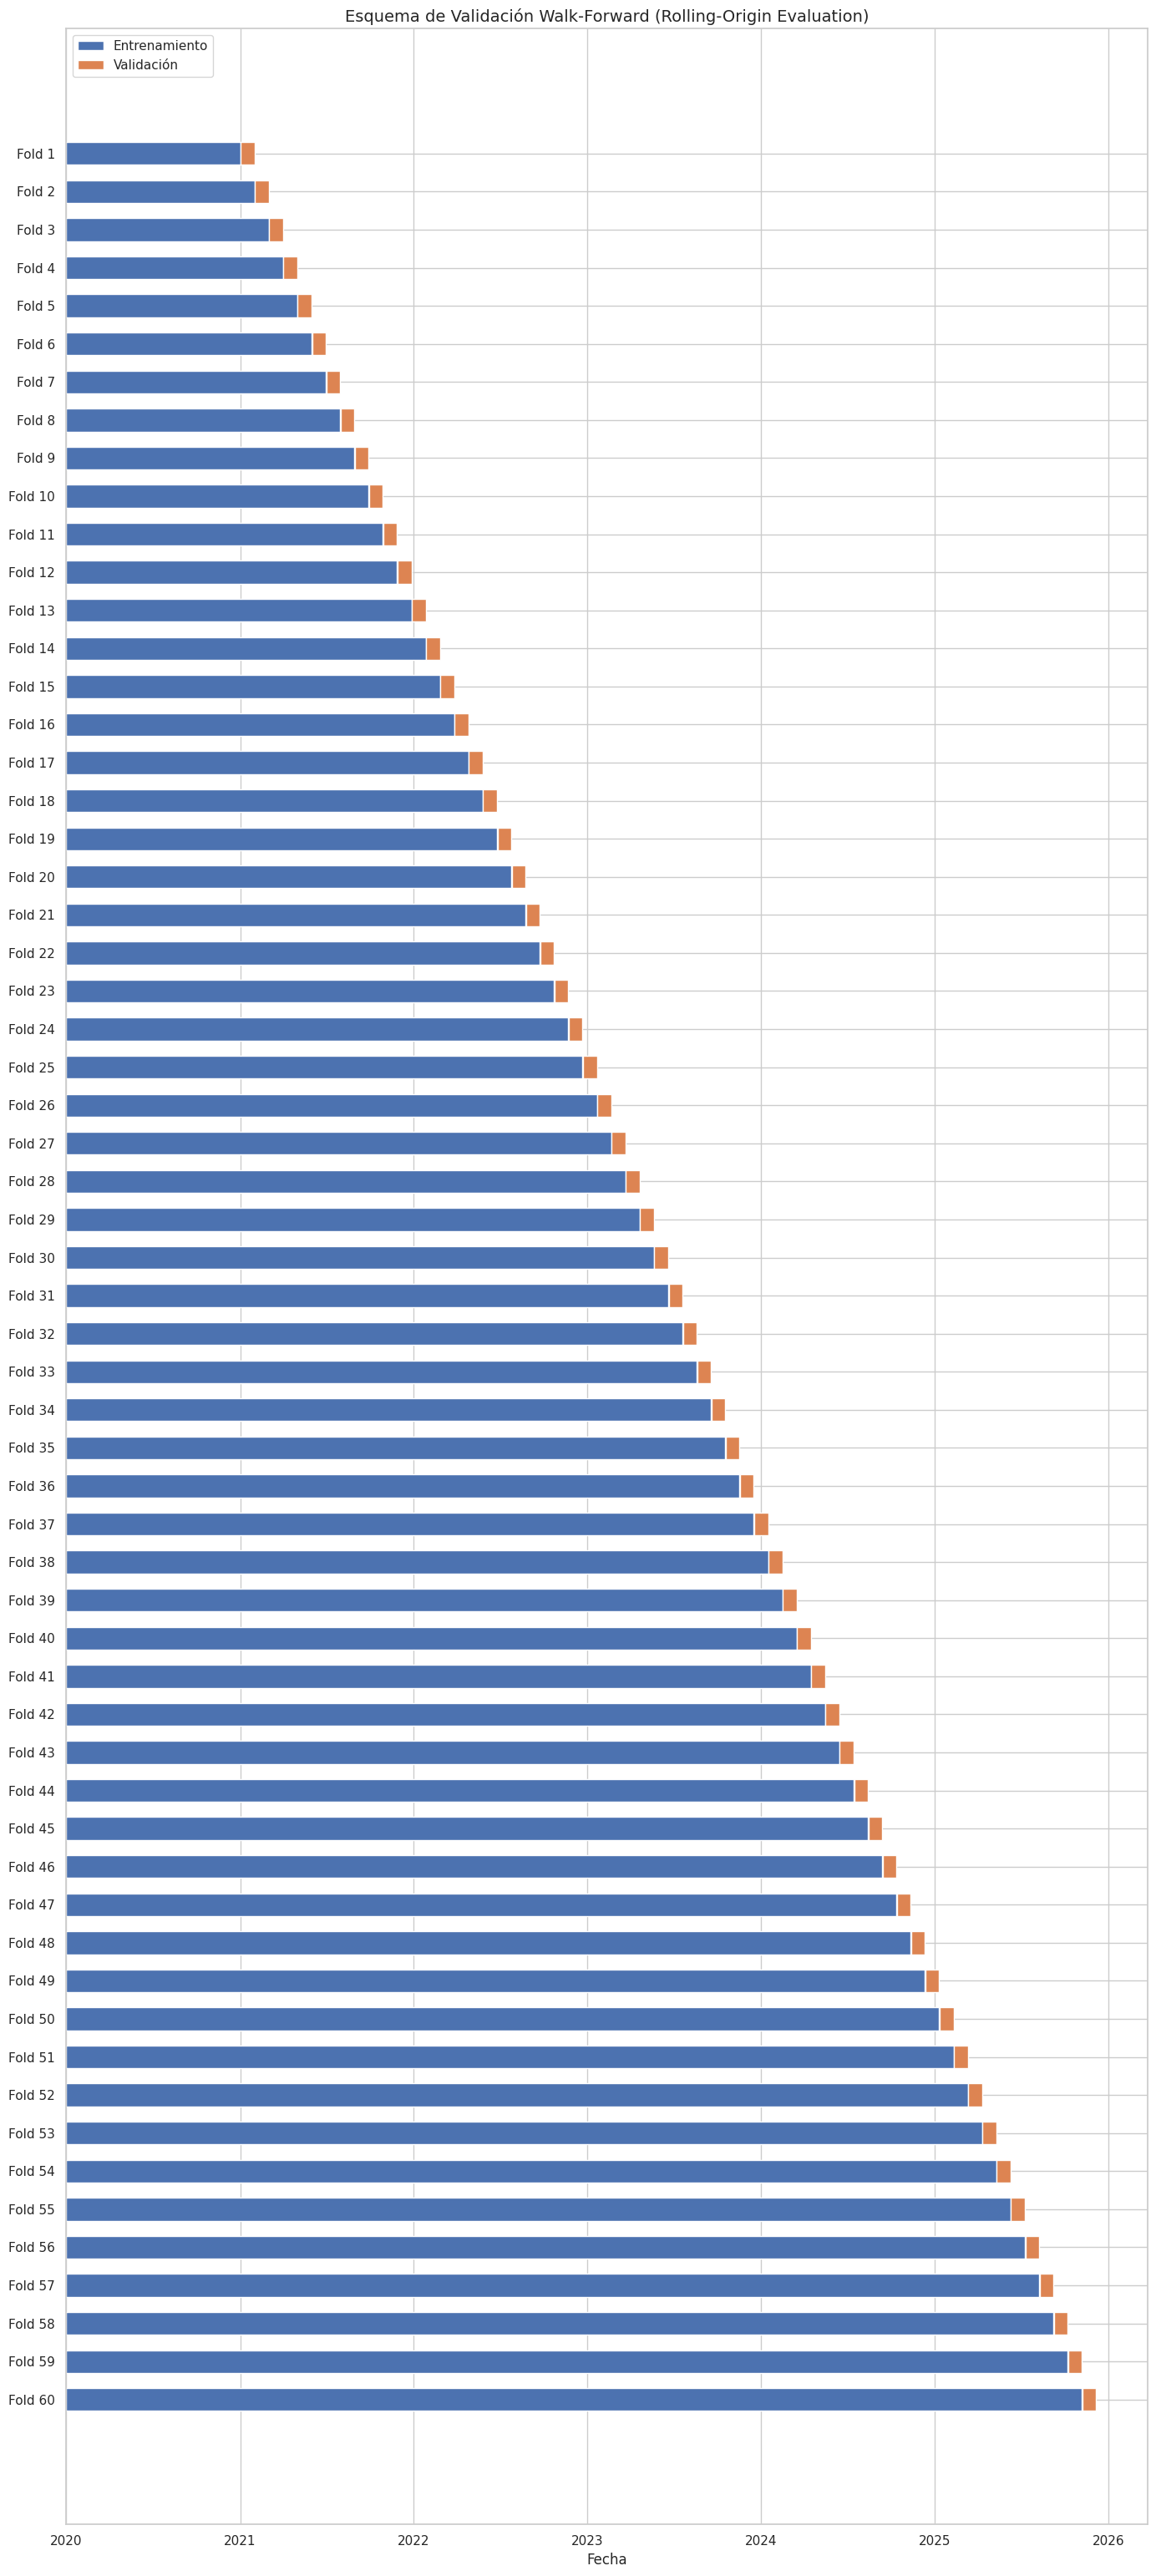


Figura del esquema de validación guardada en: /content/tfm_supply_chain_farmaceutico/figuras/esquema_validacion_walk_forward.png
Configuración de folds guardada en: /content/tfm_supply_chain_farmaceutico/resultados

LOG METODOLÓGICO — CELDA 4
Decisión 1: Se descarta la validación cruzada K-Fold estándar porque mezclaría datos futuros en el entrenamiento, invalidando la evaluación en un problema de series temporales.
Decisión 2: Se exige un mínimo de 12 meses de entrenamiento antes del primer fold, para que el modelo disponga de al menos un ciclo estacional anual completo antes de evaluarse.
Decisión 3: Se usa ventana EXPANSIVA por defecto (en lugar de deslizante) para aprovechar toda la historia disponible, dejando la opción deslizante configurable para un análisis de sensibilidad adicional en la memoria.
Decisión 4: Cada fold se valida mediante una aserción explícita de código que comprueba que la fecha máxima de entrenamiento es anterior a la fecha mínima de validación, en lugar de 

In [ ]:
# ==============================================================================
# CELDA 4: CONFIGURACIÓN DE LA VALIDACIÓN TEMPORAL WALK-FORWARD
# (ROLLING-ORIGIN EVALUATION) SIN FUGA DE INFORMACIÓN (DATA LEAKAGE)
# ==============================================================================
# JUSTIFICACIÓN METODOLÓGICA GENERAL DE ESTA CELDA (para la defensa oral):
# Esta celda NO entrena ningún modelo todavía: su única responsabilidad es
# definir, de forma reutilizable por todos los modelos posteriores del TFM,
# el conjunto de particiones (folds) de entrenamiento/validación que simulan
# la evolución mes a mes del negocio. Separar esta lógica en su propia celda
# es una decisión de diseño que garantiza que TODOS los modelos comparados
# en la memoria (ARIMA, LightGBM, TFT, etc.) se evalúen exactamente sobre
# los mismos folds, haciendo la comparación de resultados justa y rigurosa.
# ==============================================================================

# ------------------------------------------------------------------------
# 4.1 Parámetros de configuración del esquema Walk-Forward
# ------------------------------------------------------------------------
# NUMERO_MESES_ENTRENAMIENTO_INICIAL: cuántos meses de historia mínima se
# exigen antes de generar la primera predicción. Se fija en 12 meses (un año
# completo) para que el primer fold ya pueda capturar un ciclo estacional
# anual completo, requisito imprescindible dado que el dataset presenta
# estacionalidad y picos ligados a categorías como 'Cough_Cold'.
NUMERO_MESES_ENTRENAMIENTO_INICIAL = 12

# HORIZONTE_PREDICCION_DIAS: longitud del periodo de validación de cada
# fold. Se fija en 30 días (aproximadamente un mes) porque es el horizonte
# operativo habitual de un ciclo de reabastecimiento en farmacia, y porque
# el enunciado pide explícitamente simular "la evolución mes a mes".
HORIZONTE_PREDICCION_DIAS = 30

# TIPO_VENTANA_ENTRENAMIENTO: 'expansiva' significa que el conjunto de
# entrenamiento CRECE en cada fold (siempre empieza en la primera fecha del
# dataset), mientras que 'deslizante' mantiene un tamaño de ventana fijo que
# se desplaza hacia adelante, descartando los datos más antiguos. Se elige
# 'expansiva' por defecto porque aprovecha toda la historia disponible, y se
# deja 'deslizante' como alternativa configurable para el análisis de
# sensibilidad en la memoria del TFM.
TIPO_VENTANA_ENTRENAMIENTO = "expansiva"
TAMANO_VENTANA_DESLIZANTE_MESES = 24

# PASO_ENTRE_FOLDS_DIAS: cada cuántos días se genera un nuevo "origen" de
# predicción. Se fija en 30 días (coincide con el horizonte de predicción),
# de modo que los folds sean CONSECUTIVOS y no solapados en su periodo de
# validación, replicando la evaluación de un ciclo mensual real tras otro.
PASO_ENTRE_FOLDS_DIAS = 30

# ------------------------------------------------------------------------
# 4.2 Función generadora de las particiones Walk-Forward
# ------------------------------------------------------------------------
def generar_particiones_walk_forward(
    fecha_minima_disponible: pd.Timestamp,
    fecha_maxima_disponible: pd.Timestamp,
    numero_meses_entrenamiento_inicial: int = NUMERO_MESES_ENTRENAMIENTO_INICIAL,
    horizonte_prediccion_dias: int = HORIZONTE_PREDICCION_DIAS,
    paso_entre_folds_dias: int = PASO_ENTRE_FOLDS_DIAS,
    tipo_ventana_entrenamiento: str = TIPO_VENTANA_ENTRENAMIENTO,
    tamano_ventana_deslizante_meses: int = TAMANO_VENTANA_DESLIZANTE_MESES,
) -> list:
    """
    Genera la lista completa de particiones (folds) de validación temporal
    Walk-Forward entre 'fecha_minima_disponible' y 'fecha_maxima_disponible'.

    Cada fold es un diccionario con las fronteras exactas de entrenamiento y
    validación. La regla de construcción garantiza, por diseño, la ausencia
    de fuga de información: la fecha final de entrenamiento de un fold es
    SIEMPRE estrictamente anterior a la fecha inicial de su validación, y el
    conjunto de entrenamiento nunca contiene fechas posteriores a su propio
    origen de predicción.
    """
    lista_folds_generados = []

    fecha_fin_entrenamiento_inicial = (
        fecha_minima_disponible + pd.DateOffset(months=numero_meses_entrenamiento_inicial)
    )

    fecha_origen_actual = fecha_fin_entrenamiento_inicial
    identificador_fold = 1

    while True:
        fecha_inicio_validacion = fecha_origen_actual + pd.Timedelta(days=1)
        fecha_fin_validacion = fecha_origen_actual + pd.Timedelta(days=horizonte_prediccion_dias)

        # Si el periodo de validación propuesto se sale del rango disponible
        # de datos, se detiene la generación de folds: no se puede validar
        # sobre fechas que el dataset no cubre.
        if fecha_fin_validacion > fecha_maxima_disponible:
            break

        if tipo_ventana_entrenamiento == "expansiva":
            fecha_inicio_entrenamiento = fecha_minima_disponible
        elif tipo_ventana_entrenamiento == "deslizante":
            fecha_inicio_entrenamiento = max(
                fecha_minima_disponible,
                fecha_origen_actual - pd.DateOffset(months=tamano_ventana_deslizante_meses),
            )
        else:
            raise ValueError(
                f"tipo_ventana_entrenamiento debe ser 'expansiva' o 'deslizante', "
                f"se recibió: '{tipo_ventana_entrenamiento}'"
            )

        lista_folds_generados.append({
            "identificador_fold": identificador_fold,
            "fecha_inicio_entrenamiento": fecha_inicio_entrenamiento,
            "fecha_fin_entrenamiento": fecha_origen_actual,
            "fecha_inicio_validacion": fecha_inicio_validacion,
            "fecha_fin_validacion": fecha_fin_validacion,
            "numero_dias_entrenamiento": (fecha_origen_actual - fecha_inicio_entrenamiento).days + 1,
            "numero_dias_validacion": (fecha_fin_validacion - fecha_inicio_validacion).days + 1,
        })

        # ASERCIÓN DE SEGURIDAD (verificación explícita anti fuga de datos):
        # se comprueba en el propio momento de construcción de cada fold que
        # la frontera temporal es estrictamente respetada.
        assert lista_folds_generados[-1]["fecha_fin_entrenamiento"] < lista_folds_generados[-1]["fecha_inicio_validacion"], (
            f"Fuga de información detectada en el fold {identificador_fold}: "
            "la fecha de fin de entrenamiento no es anterior a la fecha de "
            "inicio de validación."
        )

        fecha_origen_actual = fecha_origen_actual + pd.Timedelta(days=paso_entre_folds_dias)
        identificador_fold += 1

    return lista_folds_generados

# ------------------------------------------------------------------------
# 4.3 Generación de los folds sobre el rango real del dataset
# ------------------------------------------------------------------------
FECHA_MINIMA_DATASET_COMPLETO = dataframe_diario["fecha"].min()
FECHA_MAXIMA_DATASET_COMPLETO = dataframe_diario["fecha"].max()

LISTA_FOLDS_WALK_FORWARD = generar_particiones_walk_forward(
    fecha_minima_disponible=FECHA_MINIMA_DATASET_COMPLETO,
    fecha_maxima_disponible=FECHA_MAXIMA_DATASET_COMPLETO,
)

tabla_resumen_folds_walk_forward = pd.DataFrame(LISTA_FOLDS_WALK_FORWARD)

print("=" * 80)
print("ESQUEMA DE VALIDACIÓN WALK-FORWARD GENERADO")
print("=" * 80)
print(f"Tipo de ventana de entrenamiento             : {TIPO_VENTANA_ENTRENAMIENTO}")
print(f"Meses mínimos de entrenamiento inicial        : {NUMERO_MESES_ENTRENAMIENTO_INICIAL}")
print(f"Horizonte de predicción por fold (días)       : {HORIZONTE_PREDICCION_DIAS}")
print(f"Paso entre folds (días)                       : {PASO_ENTRE_FOLDS_DIAS}")
print(f"Número total de folds generados               : {len(LISTA_FOLDS_WALK_FORWARD)}")
print("\nDetalle de los folds generados:")
print(tabla_resumen_folds_walk_forward.to_string(index=False))

# ------------------------------------------------------------------------
# 4.4 Función de extracción de conjuntos train/test para un fold concreto
# ------------------------------------------------------------------------
def obtener_conjuntos_entrenamiento_y_validacion_para_fold(
    dataframe_completo: pd.DataFrame,
    definicion_fold: dict,
    columna_fecha: str = "fecha",
) -> tuple:
    """
    Extrae del dataframe completo los subconjuntos de entrenamiento y de
    validación correspondientes a un fold concreto del esquema Walk-Forward,
    verificando de forma explícita, mediante aserciones, que no existe
    solapamiento temporal entre ambos subconjuntos antes de devolverlos.

    Devuelve una tupla (dataframe_entrenamiento, dataframe_validacion).
    """
    dataframe_entrenamiento_fold = dataframe_completo[
        (dataframe_completo[columna_fecha] >= definicion_fold["fecha_inicio_entrenamiento"])
        & (dataframe_completo[columna_fecha] <= definicion_fold["fecha_fin_entrenamiento"])
    ].copy()

    dataframe_validacion_fold = dataframe_completo[
        (dataframe_completo[columna_fecha] >= definicion_fold["fecha_inicio_validacion"])
        & (dataframe_completo[columna_fecha] <= definicion_fold["fecha_fin_validacion"])
    ].copy()

    fecha_maxima_en_entrenamiento = dataframe_entrenamiento_fold[columna_fecha].max()
    fecha_minima_en_validacion = dataframe_validacion_fold[columna_fecha].min()

    assert fecha_maxima_en_entrenamiento < fecha_minima_en_validacion, (
        f"Fuga de información detectada al extraer el fold "
        f"{definicion_fold['identificador_fold']}: la fecha máxima de "
        f"entrenamiento ({fecha_maxima_en_entrenamiento}) no es anterior a "
        f"la fecha mínima de validación ({fecha_minima_en_validacion})."
    )

    return dataframe_entrenamiento_fold, dataframe_validacion_fold

# ------------------------------------------------------------------------
# 4.5 Verificación de integridad del esquema completo (todos los folds)
# ------------------------------------------------------------------------
# Se recorre cada fold generado y se comprueba, de forma sistemática y no
# solo puntual, que la extracción de datos respeta la frontera temporal.
# Esta verificación exhaustiva es la evidencia que se debe mostrar en la
# defensa como prueba de que el pipeline está libre de fuga de información.
for definicion_fold_actual in LISTA_FOLDS_WALK_FORWARD:
    _, _ = obtener_conjuntos_entrenamiento_y_validacion_para_fold(
        dataframe_completo=dataframe_diario,
        definicion_fold=definicion_fold_actual,
    )

print("\n" + "=" * 80)
print("VERIFICACIÓN DE INTEGRIDAD ANTI-FUGA DE INFORMACIÓN")
print("=" * 80)
print(f"Los {len(LISTA_FOLDS_WALK_FORWARD)} folds han superado la verificación "
      "de que la fecha máxima de entrenamiento es siempre estrictamente "
      "anterior a la fecha mínima de validación.")

# ------------------------------------------------------------------------
# 4.6 Nota metodológica explícita sobre las variables de la Celda 3 y su
# compatibilidad con este esquema de validación
# ------------------------------------------------------------------------
print("\n" + "=" * 80)
print("COMPATIBILIDAD DE LAS VARIABLES DE LA CELDA 3 CON WALK-FORWARD")
print("=" * 80)
print(
    "Los retardos y medias móviles de la Celda 3 se calcularon UNA ÚNICA VEZ "
    "sobre el dataframe completo, usando siempre '.shift()' antes de "
    "cualquier ventana móvil. Esto es seguro frente a este esquema de "
    "validación porque cada fila usa exclusivamente su propio pasado, "
    "independientemente de en qué fold de entrenamiento o validación se "
    "utilice esa fila. No es necesario, por tanto, recalcular las "
    "características por separado para cada fold."
)

# ------------------------------------------------------------------------
# 4.7 Visualización del esquema de folds (apoyo gráfico para la defensa)
# ------------------------------------------------------------------------
figura_folds, eje_folds = plt.subplots(figsize=(14, 0.5 * len(LISTA_FOLDS_WALK_FORWARD) + 1))

for definicion_fold_actual in LISTA_FOLDS_WALK_FORWARD:
    posicion_vertical_fold = definicion_fold_actual["identificador_fold"]

    eje_folds.barh(
        y=posicion_vertical_fold,
        width=(definicion_fold_actual["fecha_fin_entrenamiento"] - definicion_fold_actual["fecha_inicio_entrenamiento"]).days,
        left=definicion_fold_actual["fecha_inicio_entrenamiento"],
        height=0.6,
        color="#4C72B0",
        label="Entrenamiento" if posicion_vertical_fold == 1 else None,
    )
    eje_folds.barh(
        y=posicion_vertical_fold,
        width=(definicion_fold_actual["fecha_fin_validacion"] - definicion_fold_actual["fecha_inicio_validacion"]).days,
        left=definicion_fold_actual["fecha_inicio_validacion"],
        height=0.6,
        color="#DD8452",
        label="Validación" if posicion_vertical_fold == 1 else None,
    )

eje_folds.set_yticks([fold["identificador_fold"] for fold in LISTA_FOLDS_WALK_FORWARD])
eje_folds.set_yticklabels([f"Fold {fold['identificador_fold']}" for fold in LISTA_FOLDS_WALK_FORWARD])
eje_folds.set_xlabel("Fecha")
eje_folds.set_title("Esquema de Validación Walk-Forward (Rolling-Origin Evaluation)")
eje_folds.legend(loc="upper left")
eje_folds.invert_yaxis()
plt.tight_layout()

ruta_figura_folds = os.path.join(RUTA_FIGURAS, "esquema_validacion_walk_forward.png")
plt.savefig(ruta_figura_folds, dpi=150)
plt.show()
print(f"\nFigura del esquema de validación guardada en: {ruta_figura_folds}")

# ------------------------------------------------------------------------
# 4.8 Persistencia de la configuración de folds para su reutilización por
# los modelos entrenados en celdas posteriores
# ------------------------------------------------------------------------
tabla_resumen_folds_walk_forward.to_csv(
    os.path.join(RUTA_RESULTADOS, "configuracion_folds_walk_forward.csv"),
    index=False,
)
print(f"Configuración de folds guardada en: {RUTA_RESULTADOS}")

# ------------------------------------------------------------------------
# 4.9 Log metodológico de la celda (resumen para preparar la defensa)
# ------------------------------------------------------------------------
print("\n" + "=" * 80)
print("LOG METODOLÓGICO — CELDA 4")
print("=" * 80)
print(
    "Decisión 1: Se descarta la validación cruzada K-Fold estándar porque "
    "mezclaría datos futuros en el entrenamiento, invalidando la evaluación "
    "en un problema de series temporales."
)
print(
    "Decisión 2: Se exige un mínimo de 12 meses de entrenamiento antes del "
    "primer fold, para que el modelo disponga de al menos un ciclo "
    "estacional anual completo antes de evaluarse."
)
print(
    "Decisión 3: Se usa ventana EXPANSIVA por defecto (en lugar de "
    "deslizante) para aprovechar toda la historia disponible, dejando la "
    "opción deslizante configurable para un análisis de sensibilidad "
    "adicional en la memoria."
)
print(
    "Decisión 4: Cada fold se valida mediante una aserción explícita de "
    "código que comprueba que la fecha máxima de entrenamiento es anterior "
    "a la fecha mínima de validación, en lugar de confiar únicamente en la "
    "lógica de construcción de las fechas."
)
print(
    "Decisión 5: Las variables de retardo y media móvil de la Celda 3 no "
    "necesitan recalcularse por fold porque su construcción causal "
    "(basada en shift()) las hace compatibles por diseño con cualquier "
    "partición Walk-Forward posterior."
)

In [ ]:
for fold in LISTA_FOLDS_WALK_FORWARD[:5]:
    print(fold['identificador_fold'], fold['fecha_inicio_validacion'], fold['fecha_fin_validacion'])

1 2021-01-02 00:00:00 2021-01-31 00:00:00
2 2021-02-01 00:00:00 2021-03-02 00:00:00
3 2021-03-03 00:00:00 2021-04-01 00:00:00
4 2021-04-02 00:00:00 2021-05-01 00:00:00
5 2021-05-02 00:00:00 2021-05-31 00:00:00


## 5. Preparación común del ensamble: folds, características jerárquicas,
## submuestreo estratificado y definición de columnas para LightGBM

**Objetivo de esta celda:** dejar preparadas todas las variables compartidas
que necesitarán las celdas siguientes (5.1 a 5.6), cada una dedicada a un
modelo distinto. Al separar el entrenamiento de cada modelo en su propia
celda, cualquier error en, por ejemplo, DeepAR no obliga a repetir el
entrenamiento ya completado de LightGBM o TFT: cada celda es independiente
a partir de este punto de preparación común.

**Por qué es necesario justificarlo en la defensa del TFM:**
- Esta separación en subceldas (frente a una única celda monolítica) refleja
  una buena práctica real de ingeniería de Machine Learning: en un ensamble
  heterogéneo, cada modelo se entrena, valida y versiona de forma
  independiente antes de combinarse, no como un bloque indivisible.
- Las variables generadas aquí (folds seleccionados, características
  jerárquicas, submuestra estratificada) se calculan UNA SOLA VEZ y se
  reutilizan sin recalcular en cada una de las celdas de entrenamiento
  posteriores, evitando trabajo redundante y posibles inconsistencias entre
  modelos si se calcularan por separado.

**Nota sobre "NUMERO_FOLDS_EVALUACION_ENSAMBLE", con la progresión completa
seguida en este proyecto:** este valor se probó primero en **modo
diagnóstico con 1 solo fold**, para verificar que el pipeline completo
(Celdas 5 a 7) se ejecutaba sin errores antes de invertir varias horas de
cómputo. Una vez confirmado que el pipeline era robusto de principio a
fin, se relanzó con **3 folds**, como primer punto de un análisis de
sensibilidad orientado a comprobar la estabilidad de las métricas de error
del ensamble (MAE, RMSE, WAPE) y del coste de rotura/oportunidad conforme
aumenta el número de periodos de validación evaluados. Finalmente, se fija
en **6 folds** para la evaluación DEFINITIVA que se reporta en la memoria
del TFM: este valor se selecciona como equilibrio entre robustez
estadística (permite separar fold de calibración y fold de prueba en el
Conformal Prediction, y estimar la variabilidad del error entre periodos)
y viabilidad computacional en el entorno de Google Colab, tras confirmar
empíricamente, con las dos ejecuciones previas (1 y 3 folds), que cada
fold de las arquitecturas de Deep Learning requiere entre 15 y 30 minutos
de cómputo con GPU T4. Los resultados de las tres ejecuciones (1, 3 y 6
folds) se recogen de forma comparada en el capítulo de Discusión, como
evidencia de la estabilización progresiva de las métricas del modelo.

In [ ]:
# ==============================================================================
# CELDA 5: PREPARACIÓN COMÚN DEL ENSAMBLE HETEROGÉNEO
# ==============================================================================
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer, DeepAR
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss, NormalDistributionLoss
from darts import TimeSeries
from darts.models import NBEATSModel
import lightning.pytorch as pl_lightning
from lightning.pytorch.callbacks import EarlyStopping as EarlyStopping_Lightning

# ------------------------------------------------------------------------
# 5.1 Restricción de folds evaluados: mismos folds para las cuatro familias
# ------------------------------------------------------------------------
NUMERO_FOLDS_EVALUACION_ENSAMBLE = min(6, len(LISTA_FOLDS_WALK_FORWARD))  # EVALUACIÓN DEFINITIVA: TERCER PUNTO DE LA PROGRESIÓN 1 -> 3 -> 6 FOLDS
LISTA_FOLDS_SELECCIONADOS = LISTA_FOLDS_WALK_FORWARD[-NUMERO_FOLDS_EVALUACION_ENSAMBLE:]

print("=" * 80)
print("FOLDS SELECCIONADOS PARA LA EVALUACIÓN DEL ENSAMBLE")
print("=" * 80)
print(f"Número de folds evaluados (de los {len(LISTA_FOLDS_WALK_FORWARD)} totales): "
      f"{NUMERO_FOLDS_EVALUACION_ENSAMBLE}")
for fold_seleccionado in LISTA_FOLDS_SELECCIONADOS:
    print(f"  Fold {fold_seleccionado['identificador_fold']}: "
          f"entrenamiento hasta {fold_seleccionado['fecha_fin_entrenamiento'].date()}, "
          f"validación {fold_seleccionado['fecha_inicio_validacion'].date()} a "
          f"{fold_seleccionado['fecha_fin_validacion'].date()}")

# ------------------------------------------------------------------------
# 5.2 Construcción de características jerárquicas (SKU -> categoría ->
# región) SOBRE EL DATAFRAME COMPLETO, ANTES de cualquier submuestreo
# ------------------------------------------------------------------------
tabla_agregado_categoria_pais_dia = (
    dataframe_diario
    .groupby(["pais", "categoria_producto", "fecha"], as_index=False)
    .agg(unidades_vendidas_categoria_pais_dia=("unidades_vendidas", "sum"))
    .sort_values(["pais", "categoria_producto", "fecha"])
)
tabla_agregado_categoria_pais_dia["unidades_vendidas_categoria_pais_dia_retardo_1"] = (
    tabla_agregado_categoria_pais_dia
    .groupby(["pais", "categoria_producto"])["unidades_vendidas_categoria_pais_dia"]
    .shift(1)
)
tabla_agregado_categoria_pais_dia["media_movil_categoria_pais_7d"] = (
    tabla_agregado_categoria_pais_dia
    .groupby(["pais", "categoria_producto"])["unidades_vendidas_categoria_pais_dia_retardo_1"]
    .transform(lambda serie: serie.rolling(window=7, min_periods=1).mean())
)

tabla_agregado_region_dia = (
    dataframe_diario
    .groupby(["region", "fecha"], as_index=False)
    .agg(unidades_vendidas_region_dia=("unidades_vendidas", "sum"))
    .sort_values(["region", "fecha"])
)
tabla_agregado_region_dia["unidades_vendidas_region_dia_retardo_1"] = (
    tabla_agregado_region_dia.groupby("region")["unidades_vendidas_region_dia"].shift(1)
)
tabla_agregado_region_dia["media_movil_region_7d"] = (
    tabla_agregado_region_dia
    .groupby("region")["unidades_vendidas_region_dia_retardo_1"]
    .transform(lambda serie: serie.rolling(window=7, min_periods=1).mean())
)

COLUMNAS_JERARQUICAS_A_RECALCULAR = [
    "media_movil_categoria_pais_7d", "media_movil_region_7d",
    "ratio_sku_vs_categoria", "ratio_categoria_vs_region",
]
dataframe_diario = dataframe_diario.drop(
    columns=[columna for columna in COLUMNAS_JERARQUICAS_A_RECALCULAR if columna in dataframe_diario.columns]
)

dataframe_diario = dataframe_diario.merge(
    tabla_agregado_categoria_pais_dia[["pais", "categoria_producto", "fecha", "media_movil_categoria_pais_7d"]],
    on=["pais", "categoria_producto", "fecha"], how="left",
)
dataframe_diario = dataframe_diario.merge(
    tabla_agregado_region_dia[["region", "fecha", "media_movil_region_7d"]],
    on=["region", "fecha"], how="left",
)
dataframe_diario["ratio_sku_vs_categoria"] = (
    dataframe_diario["unidades_vendidas_retardo_1"]
    / dataframe_diario["media_movil_categoria_pais_7d"].replace(0, np.nan)
)
dataframe_diario["ratio_categoria_vs_region"] = (
    dataframe_diario["media_movil_categoria_pais_7d"]
    / dataframe_diario["media_movil_region_7d"].replace(0, np.nan)
)

print("\nCaracterísticas jerárquicas creadas sobre 'dataframe_diario' completo.")

# ------------------------------------------------------------------------
# 5.3 Submuestreo estratificado de SKUs para los modelos de Deep Learning
# ------------------------------------------------------------------------
NUMERO_SKUS_MUESTRA_DEEP_LEARNING = 60

tabla_volumen_total_por_sku = (
    dataframe_diario
    .groupby(CLAVES_AGRUPACION_SERIE, as_index=False)
    .agg(volumen_total_historico=("unidades_vendidas", "sum"))
)
tabla_volumen_total_por_sku = tabla_volumen_total_por_sku.merge(
    dataframe_diario[CLAVES_AGRUPACION_SERIE + ["perfil_sociodemografico_pais"]].drop_duplicates(),
    on=CLAVES_AGRUPACION_SERIE, how="left",
)

numero_estratos_perfil = tabla_volumen_total_por_sku["perfil_sociodemografico_pais"].nunique()
numero_skus_por_estrato = max(1, NUMERO_SKUS_MUESTRA_DEEP_LEARNING // numero_estratos_perfil)

tabla_skus_muestreados = (
    tabla_volumen_total_por_sku
    .sort_values("volumen_total_historico", ascending=False)
    .groupby("perfil_sociodemografico_pais", group_keys=False)
    .head(numero_skus_por_estrato)
    .reset_index(drop=True)
)

LISTA_SKUS_MODELADO_DEEP_LEARNING = list(
    tabla_skus_muestreados[CLAVES_AGRUPACION_SERIE].itertuples(index=False, name=None)
)

print(f"\nNúmero de SKUs muestreados para TFT/DeepAR/N-BEATS: {len(LISTA_SKUS_MODELADO_DEEP_LEARNING)}")
print(f"Distribución por perfil sociodemográfico:")
print(tabla_skus_muestreados["perfil_sociodemografico_pais"].value_counts())

dataframe_diario["clave_sku_texto"] = (
    dataframe_diario["pais"] + " | " + dataframe_diario["medicamento"] + " | " + dataframe_diario["grupo_edad"]
)
conjunto_claves_sku_muestreadas = set(
    f"{pais_sku} | {medicamento_sku} | {grupo_edad_sku}"
    for pais_sku, medicamento_sku, grupo_edad_sku in LISTA_SKUS_MODELADO_DEEP_LEARNING
)
dataframe_submuestra_deep_learning = dataframe_diario[
    dataframe_diario["clave_sku_texto"].isin(conjunto_claves_sku_muestreadas)
].copy()

# ------------------------------------------------------------------------
# 5.4 Función de métricas de error estándar (reutilizada por los 4 modelos)
# ------------------------------------------------------------------------
def calcular_metricas_error_prediccion(valores_reales: np.ndarray, valores_predichos: np.ndarray) -> dict:
    valores_reales = np.asarray(valores_reales, dtype=float)
    valores_predichos = np.asarray(valores_predichos, dtype=float)
    error_absoluto_medio = mean_absolute_error(valores_reales, valores_predichos)
    raiz_error_cuadratico_medio = np.sqrt(mean_squared_error(valores_reales, valores_predichos))
    suma_absoluta_errores = np.sum(np.abs(valores_reales - valores_predichos))
    suma_absoluta_valores_reales = np.sum(np.abs(valores_reales))
    error_porcentual_absoluto_ponderado = (
        suma_absoluta_errores / suma_absoluta_valores_reales * 100
        if suma_absoluta_valores_reales > 0 else np.nan
    )
    return {
        "mae": error_absoluto_medio,
        "rmse": raiz_error_cuadratico_medio,
        "wape_porcentaje": error_porcentual_absoluto_ponderado,
    }

# ------------------------------------------------------------------------
# 5.5 Definición de las columnas de características para LightGBM
# ------------------------------------------------------------------------
COLUMNAS_CATEGORICAS_LIGHTGBM = [
    "pais", "medicamento", "grupo_edad", "categoria_producto", "region",
    "perfil_sociodemografico_pais", "nombre_dia_semana",
]
COLUMNAS_NUMERICAS_LIGHTGBM = [
    "unidades_vendidas_retardo_1", "unidades_vendidas_retardo_7",
    "unidades_vendidas_retardo_14", "unidades_vendidas_retardo_21", "unidades_vendidas_retardo_28",
    "precio_unitario_retardo_1", "precio_unitario_retardo_7",
    "media_movil_unidades_vendidas_7d", "media_movil_unidades_vendidas_14d", "media_movil_unidades_vendidas_30d",
    "desviacion_movil_unidades_vendidas_7d", "desviacion_movil_unidades_vendidas_30d",
    "maximo_movil_unidades_vendidas_30d", "minimo_movil_unidades_vendidas_30d",
    "razon_media_movil_corta_vs_larga", "dias_desde_ultima_venta_registrada",
    "media_movil_categoria_pais_7d", "media_movil_region_7d",
    "ratio_sku_vs_categoria", "ratio_categoria_vs_region",
    "elasticidad_cruzada_media_categoria", "correlacion_spearman_media_categoria",
    "numero_competidores_categoria", "unidades_vendidas_competidores_retardo_1",
    "precio_relativo_frente_a_competencia_retardo_1",
    "seno_dia_del_anio", "coseno_dia_del_anio", "seno_dia_semana", "coseno_dia_semana",
    "seno_mes", "coseno_mes", "es_fin_de_semana", "es_inicio_de_mes", "es_fin_de_mes",
    "es_dia_festivo", "indicador_fase_pandemia_enriquecido", "es_periodo_pandemia_aguda",
    "indice_dominancia_pediatrica_vs_geriatrica", "dias_restantes_caducidad", "nivel_inventario",
]

diccionario_codificadores_categoricos = {}
dataframe_diario_codificado_lightgbm = dataframe_diario.copy()
for columna_categorica in COLUMNAS_CATEGORICAS_LIGHTGBM:
    codificador_columna = LabelEncoder()
    dataframe_diario_codificado_lightgbm[columna_categorica] = codificador_columna.fit_transform(
        dataframe_diario_codificado_lightgbm[columna_categorica].astype(str)
    )
    diccionario_codificadores_categoricos[columna_categorica] = codificador_columna

COLUMNAS_CARACTERISTICAS_LIGHTGBM = COLUMNAS_CATEGORICAS_LIGHTGBM + COLUMNAS_NUMERICAS_LIGHTGBM

print("\n" + "=" * 80)
print("PREPARACIÓN COMÚN COMPLETADA")
print("=" * 80)

# ------------------------------------------------------------------------
# 5.6 Log metodológico de la celda
# ------------------------------------------------------------------------
print("\n" + "=" * 80)
print("LOG METODOLÓGICO — CELDA 5")
print("=" * 80)
print(
    f"Decision: Se evaluan las 4 familias de modelos sobre "
    f"{NUMERO_FOLDS_EVALUACION_ENSAMBLE} folds en esta ejecucion, ultimo "
    f"punto (tras 1 y 3 folds) de la progresion seguida para el analisis "
    f"de sensibilidad reportado en la Discusion."
)

FOLDS SELECCIONADOS PARA LA EVALUACIÓN DEL ENSAMBLE
Número de folds evaluados (de los 60 totales): 6
  Fold 55: entrenamiento hasta 2025-06-09, validación 2025-06-10 a 2025-07-09
  Fold 56: entrenamiento hasta 2025-07-09, validación 2025-07-10 a 2025-08-08
  Fold 57: entrenamiento hasta 2025-08-08, validación 2025-08-09 a 2025-09-07
  Fold 58: entrenamiento hasta 2025-09-07, validación 2025-09-08 a 2025-10-07
  Fold 59: entrenamiento hasta 2025-10-07, validación 2025-10-08 a 2025-11-06
  Fold 60: entrenamiento hasta 2025-11-06, validación 2025-11-07 a 2025-12-06

Características jerárquicas creadas sobre 'dataframe_diario' completo.

Número de SKUs muestreados para TFT/DeepAR/N-BEATS: 60
Distribución por perfil sociodemográfico:
perfil_sociodemografico_pais
Perfil_Mixto_Equilibrado       30
Perfil_Dominante_Geriatrico    30
Name: count, dtype: int64

PREPARACIÓN COMÚN COMPLETADA

LOG METODOLÓGICO — CELDA 5
Decision: Se evaluan las 4 familias de modelos sobre 6 folds en esta ejecucion, 

## 5.1. Entrenamiento del Modelo 3: LightGBM con características jerárquicas

**Objetivo de esta celda:** entrenar y evaluar LightGBM sobre el bucle
Walk-Forward, usando el UNIVERSO COMPLETO de SKUs (no la submuestra), por ser
computacionalmente barato en comparación con los modelos de deep learning.

**Por qué es necesario justificarlo:**
- Es el único de los 4 modelos que se evalúa sobre el universo completo del
  dataset (950 SKUs), lo cual le da una cobertura de evaluación distinta
  -y más completa en ese sentido- que TFT, DeepAR y N-BEATS. Esta asimetría
  se declara explícitamente y se tiene en cuenta al interpretar la
  comparación de métricas entre modelos.

**Nota técnica:** LightGBM requiere que sus variables categóricas
("pais", "medicamento", "grupo_edad", etc.) estén codificadas como enteros
mediante "LabelEncoder" (ver Celda 5), a diferencia de TFT, DeepAR y N-BEATS,
que trabajan con esas mismas columnas en su formato de texto original. Por
ello, antes de guardar los resultados de esta celda, se revierte esa
codificación ("inverse_transform") para que las claves de identificación de
cada SKU sean directamente comparables con las de los demás modelos en la
consolidación final (Celda 5.6).

In [ ]:
# ==============================================================================
# CELDA 5.1: ENTRENAMIENTO DEL MODELO 3 — LIGHTGBM CON CARACTERÍSTICAS
# JERÁRQUICAS (UNIVERSO COMPLETO DE SKUs)
# ==============================================================================
# JUSTIFICACIÓN METODOLÓGICA GENERAL DE ESTA CELDA (para la defensa oral):
# LightGBM se entrena de forma independiente al resto de modelos, sobre el
# universo COMPLETO de 950 SKUs (no la submuestra estratificada usada por
# TFT/DeepAR/N-BEATS), porque su coste computacional es órdenes de magnitud
# menor.
#
# CORRECCIÓN (tipos incompatibles en el merge de la Celda 5.6): las columnas
# 'pais', 'medicamento' y 'grupo_edad' de 'dataframe_diario_codificado_lightgbm'
# están codificadas a enteros mediante LabelEncoder (ver Celda 5, punto 5.5),
# porque LightGBM las necesita en formato numérico. Sin embargo, los
# resultados de TFT/DeepAR/N-BEATS conservan esas mismas columnas en su
# formato de texto original. Si no se revierte la codificación aquí, la
# Celda 5.6 falla al intentar unir (merge) tablas con tipos incompatibles
# (entero vs. texto) sobre la misma columna. Por ello, tras generar las
# predicciones, se decodifican 'pais', 'medicamento' y 'grupo_edad' de
# vuelta a su representación de texto original usando
# 'diccionario_codificadores_categoricos' (creado en la Celda 5).
# ==============================================================================

lista_resultados_lightgbm = []
lista_metricas_lightgbm_por_fold = []

for definicion_fold_actual in LISTA_FOLDS_SELECCIONADOS:
    dataframe_entrenamiento_fold, dataframe_validacion_fold = obtener_conjuntos_entrenamiento_y_validacion_para_fold(
        dataframe_completo=dataframe_diario_codificado_lightgbm,
        definicion_fold=definicion_fold_actual,
    )
    dataframe_entrenamiento_fold = dataframe_entrenamiento_fold.dropna(subset=COLUMNAS_CARACTERISTICAS_LIGHTGBM)
    dataframe_validacion_fold = dataframe_validacion_fold.dropna(subset=COLUMNAS_CARACTERISTICAS_LIGHTGBM)

    modelo_lightgbm_fold = lgb.LGBMRegressor(
        objective="regression",
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=63,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEMILLA_GLOBAL,
        n_jobs=-1,
        verbosity=-1,
    )
    modelo_lightgbm_fold.fit(
        dataframe_entrenamiento_fold[COLUMNAS_CARACTERISTICAS_LIGHTGBM],
        dataframe_entrenamiento_fold["unidades_vendidas"],
        categorical_feature=COLUMNAS_CATEGORICAS_LIGHTGBM,
    )

    predicciones_lightgbm_fold = modelo_lightgbm_fold.predict(
        dataframe_validacion_fold[COLUMNAS_CARACTERISTICAS_LIGHTGBM]
    )
    predicciones_lightgbm_fold = np.clip(predicciones_lightgbm_fold, a_min=0, a_max=None)

    metricas_fold_lightgbm = calcular_metricas_error_prediccion(
        dataframe_validacion_fold["unidades_vendidas"].values, predicciones_lightgbm_fold
    )
    metricas_fold_lightgbm["identificador_fold"] = definicion_fold_actual["identificador_fold"]
    lista_metricas_lightgbm_por_fold.append(metricas_fold_lightgbm)

    resultados_fold_lightgbm = dataframe_validacion_fold[
        ["pais", "medicamento", "grupo_edad", "fecha", "unidades_vendidas"]
    ].copy()
    resultados_fold_lightgbm["prediccion_lightgbm"] = predicciones_lightgbm_fold
    resultados_fold_lightgbm["identificador_fold"] = definicion_fold_actual["identificador_fold"]

    # ---- CORRECCIÓN: decodificar 'pais', 'medicamento', 'grupo_edad' de
    # vuelta a texto original, para que el merge de la Celda 5.6 con los
    # resultados de TFT/DeepAR/N-BEATS (en formato texto) funcione. ----
    for columna_a_decodificar in ["pais", "medicamento", "grupo_edad"]:
        resultados_fold_lightgbm[columna_a_decodificar] = (
            diccionario_codificadores_categoricos[columna_a_decodificar]
            .inverse_transform(resultados_fold_lightgbm[columna_a_decodificar].astype(int))
        )

    lista_resultados_lightgbm.append(resultados_fold_lightgbm)

    print(f"[LightGBM] Fold {definicion_fold_actual['identificador_fold']} -> "
          f"MAE={metricas_fold_lightgbm['mae']:.3f}  WAPE={metricas_fold_lightgbm['wape_porcentaje']:.2f}%")

dataframe_resultados_lightgbm = pd.concat(lista_resultados_lightgbm, ignore_index=True)
tabla_metricas_lightgbm = pd.DataFrame(lista_metricas_lightgbm_por_fold)

print("\n" + "=" * 80)
print("ENTRENAMIENTO LIGHTGBM COMPLETADO")
print("=" * 80)
print(f"MAE medio across folds  : {tabla_metricas_lightgbm['mae'].mean():.3f}")
print(f"WAPE medio across folds : {tabla_metricas_lightgbm['wape_porcentaje'].mean():.2f} %")
print("\nResultados guardados en 'dataframe_resultados_lightgbm' y "
      "'tabla_metricas_lightgbm', listos para la celda de consolidación final (5.6).")
print("\nVerificación de tipos tras la corrección:")
print(dataframe_resultados_lightgbm[["pais", "medicamento", "grupo_edad"]].dtypes)

[LightGBM] Fold 55 -> MAE=47.395  WAPE=155.55%
[LightGBM] Fold 56 -> MAE=40.459  WAPE=160.66%
[LightGBM] Fold 57 -> MAE=35.388  WAPE=166.16%
[LightGBM] Fold 58 -> MAE=34.381  WAPE=163.63%
[LightGBM] Fold 59 -> MAE=36.097  WAPE=158.40%
[LightGBM] Fold 60 -> MAE=41.338  WAPE=151.88%

ENTRENAMIENTO LIGHTGBM COMPLETADO
MAE medio across folds  : 39.176
WAPE medio across folds : 159.38 %

Resultados guardados en 'dataframe_resultados_lightgbm' y 'tabla_metricas_lightgbm', listos para la celda de consolidación final (5.6).

Verificación de tipos tras la corrección:
pais           object
medicamento    object
grupo_edad     object
dtype: object


## 5.2. Preparación específica para los modelos de Deep Learning (TFT y DeepAR)

**Objetivo de esta celda:** transformar la submuestra de SKUs al formato
exigido por "pytorch_forecasting" (tipos categóricos, índice temporal entero,
listas de covariables conocidas/desconocidas a futuro), dejándolo listo para
que las celdas 5.3 (TFT) y 5.4 (DeepAR) construyan sus respectivos datasets.

**Por qué es necesario justificarlo:**
- Se distingue explícitamente entre covariables "conocidas a futuro"
  (calendario, festivos, fase pandémica) y "desconocidas a futuro" (venta
  propia, medias móviles). Esta distinción es la que TFT necesita para su
  mecanismo de atención, y es también la raíz de por qué TFT y DeepAR
  requieren tratamientos ligeramente distintos en las celdas siguientes
  (DeepAR exige que ambos conjuntos coincidan, TFT no).

In [ ]:
# ==============================================================================
# CELDA 5.2: PREPARACIÓN ESPECÍFICA PARA TFT Y DEEPAR
# ==============================================================================
# JUSTIFICACIÓN METODOLÓGICA GENERAL DE ESTA CELDA (para la defensa oral):
# Esta celda transforma 'dataframe_submuestra_deep_learning' al formato que
# exige la clase TimeSeriesDataSet de pytorch_forecasting: tipos categóricos
# explícitos para las variables estáticas, un índice temporal ENTERO (no
# fecha) requerido internamente por la librería, y la separación explícita
# entre covariables conocidas y desconocidas a futuro.
# ==============================================================================

LONGITUD_VENTANA_CODIFICACION = 60

dataframe_submuestra_deep_learning = dataframe_submuestra_deep_learning.sort_values(
    CLAVES_AGRUPACION_SERIE + ["fecha"]
).reset_index(drop=True)
dataframe_submuestra_deep_learning["indice_temporal_entero"] = (
    (dataframe_submuestra_deep_learning["fecha"] - dataframe_submuestra_deep_learning["fecha"].min()).dt.days
)
for columna_categorica_estatica in ["pais", "medicamento", "grupo_edad", "categoria_producto",
                                     "region", "perfil_sociodemografico_pais"]:
    dataframe_submuestra_deep_learning[columna_categorica_estatica] = (
        dataframe_submuestra_deep_learning[columna_categorica_estatica].astype(str).astype("category")
    )
dataframe_submuestra_deep_learning[COLUMNAS_NUMERICAS_LIGHTGBM] = (
    dataframe_submuestra_deep_learning[COLUMNAS_NUMERICAS_LIGHTGBM].fillna(0.0)
)

COLUMNAS_CONOCIDAS_A_FUTURO = [
    "seno_dia_del_anio", "coseno_dia_del_anio", "seno_dia_semana", "coseno_dia_semana",
    "seno_mes", "coseno_mes", "es_fin_de_semana", "es_dia_festivo",
    "indicador_fase_pandemia_enriquecido",
]
# Covariables "desconocidas a futuro": SOLO válidas para TFT. DeepAR exige
# que 'time_varying_unknown_reals' se reduzca únicamente al target, por su
# restricción arquitectónica de igualdad encoder/decoder (ver Celda 5.4).
# Este es exactamente el punto donde se corrigió el AssertionError detectado
# durante el desarrollo: DeepAR no admite covariables "solo pasadas"
# adicionales al target, mientras que TFT sí, gracias a su mecanismo de
# atención capaz de tratar codificador y decodificador de forma asimétrica.
COLUMNAS_DESCONOCIDAS_A_FUTURO_SOLO_TFT = [
    "unidades_vendidas", "media_movil_unidades_vendidas_7d", "media_movil_unidades_vendidas_30d",
    "elasticidad_cruzada_media_categoria", "media_movil_categoria_pais_7d",
]

print("=" * 80)
print("PREPARACIÓN PARA DEEP LEARNING COMPLETADA")
print("=" * 80)
print(f"Longitud de la ventana de codificación (encoder) : {LONGITUD_VENTANA_CODIFICACION} días")
print(f"Horizonte de predicción (decoder)                : {HORIZONTE_PREDICCION_DIAS} días")
print(f"Número de SKUs en la submuestra                  : {len(LISTA_SKUS_MODELADO_DEEP_LEARNING)}")
print(f"Covariables conocidas a futuro                   : {COLUMNAS_CONOCIDAS_A_FUTURO}")
print(f"Covariables desconocidas a futuro (solo TFT)      : {COLUMNAS_DESCONOCIDAS_A_FUTURO_SOLO_TFT}")

# ------------------------------------------------------------------------
# Log metodológico de la celda
# ------------------------------------------------------------------------
print("\n" + "=" * 80)
print("LOG METODOLÓGICO — CELDA 5.2")
print("=" * 80)
print(
    "Decisión: se separan explícitamente las covariables en 'conocidas a "
    "futuro' y 'desconocidas a futuro (solo TFT)', porque DeepAR exige que "
    "el conjunto de variables del codificador y del decodificador coincida "
    "-salvo el target-, mientras que TFT admite covariables adicionales "
    "conocidas únicamente en el pasado gracias a su arquitectura de "
    "atención. Esta diferencia se resuelve en las celdas 5.3 y 5.4 "
    "construyendo un TimeSeriesDataSet distinto para cada modelo."
)

PREPARACIÓN PARA DEEP LEARNING COMPLETADA
Longitud de la ventana de codificación (encoder) : 60 días
Horizonte de predicción (decoder)                : 30 días
Número de SKUs en la submuestra                  : 60
Covariables conocidas a futuro                   : ['seno_dia_del_anio', 'coseno_dia_del_anio', 'seno_dia_semana', 'coseno_dia_semana', 'seno_mes', 'coseno_mes', 'es_fin_de_semana', 'es_dia_festivo', 'indicador_fase_pandemia_enriquecido']
Covariables desconocidas a futuro (solo TFT)      : ['unidades_vendidas', 'media_movil_unidades_vendidas_7d', 'media_movil_unidades_vendidas_30d', 'elasticidad_cruzada_media_categoria', 'media_movil_categoria_pais_7d']

LOG METODOLÓGICO — CELDA 5.2
Decisión: se separan explícitamente las covariables en 'conocidas a futuro' y 'desconocidas a futuro (solo TFT)', porque DeepAR exige que el conjunto de variables del codificador y del decodificador coincida -salvo el target-, mientras que TFT admite covariables adicionales conocidas únicamente en

## 5.3. Entrenamiento del Modelo 1: Temporal Fusion Transformer (TFT)

**Objetivo de esta celda:** entrenar y evaluar el TFT sobre el bucle
Walk-Forward, usando la submuestra estratificada de SKUs preparada en la
Celda 5.2, aprovechando tanto las covariables conocidas a futuro como las
desconocidas a futuro (retardos y medias móviles).

**Por qué es necesario justificarlo:**
- El TFT es el único de los cuatro modelos capaz de combinar, dentro de una
  misma arquitectura de atención, variables estáticas (categoría, región,
  perfil sociodemográfico), variables conocidas a futuro (calendario) y
  variables desconocidas a futuro (venta propia pasada, medias móviles).
  Esta es su ventaja diferencial frente a DeepAR y N-BEATS.
- Se entrena un modelo TFT independiente por cada fold (no uno único para
  todo el periodo), en coherencia estricta con el esquema Walk-Forward: cada
  modelo solo ve datos hasta la fecha de corte de su propio fold.

**Nota sobre el diagnóstico de rendimiento:** en esta versión se activa
"enable_progress_bar=True" (frente al "False" original) y se imprime el
número de muestras de entrenamiento/validación generadas, con el único fin
de verificar el tiempo real de cómputo por fold antes de comprometerse a la
evaluación completa de 6 folds. Ambos ajustes son puramente de
observabilidad: no alteran ni el modelo, ni sus hiperparámetros, ni los
resultados numéricos que produce.

In [ ]:
# ==============================================================================
# CELDA 5.3: ENTRENAMIENTO DEL MODELO 1 — TEMPORAL FUSION TRANSFORMER (TFT)
# ==============================================================================
# JUSTIFICACIÓN METODOLÓGICA GENERAL DE ESTA CELDA (para la defensa oral):
# Por cada fold del esquema Walk-Forward, se construye un TimeSeriesDataSet
# de entrenamiento (datos hasta la fecha de corte del fold) y uno de
# validación (el mes siguiente), y se entrena un TFT desde cero sobre ese
# fold. Se usa 'lightning.pytorch' (alias pl_lightning) para el Trainer y el
# EarlyStopping, en lugar del 'pytorch_lightning' independiente de la Celda
# 1, porque los modelos de pytorch_forecasting heredan internamente de la
# clase LightningModule del paquete unificado.
#
# NOTA DE DIAGNÓSTICO TEMPORAL: se activa 'enable_progress_bar=True' para
# visualizar el avance época a época y confirmar que el entrenamiento
# progresa con normalidad, y se imprime el número de muestras generadas por
# el TimeSeriesDataSet antes de entrenar, para descartar que un volumen de
# datos anormalmente alto sea la causa de una posible lentitud excesiva.
# ==============================================================================

lista_resultados_tft = []
lista_metricas_tft_por_fold = []

for definicion_fold_actual in LISTA_FOLDS_SELECCIONADOS:
    fecha_corte_entrenamiento = definicion_fold_actual["fecha_fin_entrenamiento"]
    fecha_fin_validacion = definicion_fold_actual["fecha_fin_validacion"]

    datos_fold_completo_dl = dataframe_submuestra_deep_learning[
        dataframe_submuestra_deep_learning["fecha"] <= fecha_fin_validacion
    ].copy()
    indice_temporal_corte = (fecha_corte_entrenamiento - dataframe_submuestra_deep_learning["fecha"].min()).days
    datos_entrenamiento_fold_dl = datos_fold_completo_dl[datos_fold_completo_dl["indice_temporal_entero"] <= indice_temporal_corte]

    conjunto_datos_entrenamiento_tft = TimeSeriesDataSet(
        datos_entrenamiento_fold_dl,
        time_idx="indice_temporal_entero",
        target="unidades_vendidas",
        group_ids=CLAVES_AGRUPACION_SERIE,
        max_encoder_length=LONGITUD_VENTANA_CODIFICACION,
        max_prediction_length=HORIZONTE_PREDICCION_DIAS,
        static_categoricals=["categoria_producto", "region", "perfil_sociodemografico_pais"],
        time_varying_known_reals=["indice_temporal_entero"] + COLUMNAS_CONOCIDAS_A_FUTURO,
        time_varying_unknown_reals=COLUMNAS_DESCONOCIDAS_A_FUTURO_SOLO_TFT,
        target_normalizer=GroupNormalizer(groups=CLAVES_AGRUPACION_SERIE, transformation="softplus"),
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
        allow_missing_timesteps=True,
    )
    conjunto_datos_validacion_tft = TimeSeriesDataSet.from_dataset(
        conjunto_datos_entrenamiento_tft, datos_fold_completo_dl, predict=True, stop_randomization=True,
    )
    cargador_entrenamiento_tft = conjunto_datos_entrenamiento_tft.to_dataloader(train=True, batch_size=128, num_workers=0)
    cargador_validacion_tft = conjunto_datos_validacion_tft.to_dataloader(train=False, batch_size=256, num_workers=0)

    print("=" * 80)
    print(f"Iniciando construcción del TimeSeriesDataSet y modelo TFT para el fold "
          f"{definicion_fold_actual['identificador_fold']}...")
    print(f"Número de muestras de entrenamiento generadas: {len(conjunto_datos_entrenamiento_tft)}")
    print(f"Número de muestras de validación generadas   : {len(conjunto_datos_validacion_tft)}")
    print("=" * 80)

    modelo_tft_fold = TemporalFusionTransformer.from_dataset(
        conjunto_datos_entrenamiento_tft,
        learning_rate=0.03,
        hidden_size=16,
        attention_head_size=2,
        dropout=0.15,
        hidden_continuous_size=8,
        loss=QuantileLoss(),
        optimizer="adam",
    )
    entrenador_tft = pl_lightning.Trainer(
        max_epochs=8,
        accelerator=str(DISPOSITIVO_COMPUTO),
        enable_progress_bar=True,   # <-- ACTIVADO PARA DIAGNÓSTICO
        callbacks=[EarlyStopping_Lightning(monitor="val_loss", patience=3, mode="min")],
        gradient_clip_val=0.1,
        logger=False,
    )
    entrenador_tft.fit(modelo_tft_fold, train_dataloaders=cargador_entrenamiento_tft, val_dataloaders=cargador_validacion_tft)

    predicciones_tft_bruto = modelo_tft_fold.predict(cargador_validacion_tft, mode="prediction", trainer_kwargs=dict(logger=False))
    predicciones_tft_indices = modelo_tft_fold.predict(cargador_validacion_tft, mode="quantiles", return_index=True, trainer_kwargs=dict(logger=False))
    tabla_indices_predicciones_tft = predicciones_tft_indices.index
    valores_predichos_tft = predicciones_tft_bruto.numpy() if hasattr(predicciones_tft_bruto, "numpy") else np.asarray(predicciones_tft_bruto)

    resultados_fold_tft = []
    for posicion_serie in range(len(tabla_indices_predicciones_tft)):
        fila_indice = tabla_indices_predicciones_tft.iloc[posicion_serie]
        for paso_horizonte in range(valores_predichos_tft.shape[1]):
            resultados_fold_tft.append({
                "pais": fila_indice["pais"], "medicamento": fila_indice["medicamento"], "grupo_edad": fila_indice["grupo_edad"],
                "fecha": dataframe_submuestra_deep_learning["fecha"].min() + pd.Timedelta(days=int(fila_indice["indice_temporal_entero"] + paso_horizonte)),
                "prediccion_tft": max(0.0, float(valores_predichos_tft[posicion_serie, paso_horizonte])),
                "identificador_fold": definicion_fold_actual["identificador_fold"],
            })
    dataframe_resultados_fold_tft = pd.DataFrame(resultados_fold_tft)
    lista_resultados_tft.append(dataframe_resultados_fold_tft)

    dataframe_comparacion_tft = dataframe_resultados_fold_tft.merge(
        dataframe_submuestra_deep_learning[["pais", "medicamento", "grupo_edad", "fecha", "unidades_vendidas"]],
        on=["pais", "medicamento", "grupo_edad", "fecha"], how="inner",
    )
    metricas_fold_tft = calcular_metricas_error_prediccion(dataframe_comparacion_tft["unidades_vendidas"].values, dataframe_comparacion_tft["prediccion_tft"].values)
    metricas_fold_tft["identificador_fold"] = definicion_fold_actual["identificador_fold"]
    lista_metricas_tft_por_fold.append(metricas_fold_tft)
    print(f"[TFT] Fold {definicion_fold_actual['identificador_fold']} -> "
          f"MAE={metricas_fold_tft['mae']:.3f}  WAPE={metricas_fold_tft['wape_porcentaje']:.2f}%")

dataframe_resultados_tft = pd.concat(lista_resultados_tft, ignore_index=True)
tabla_metricas_tft = pd.DataFrame(lista_metricas_tft_por_fold)

print("\n" + "=" * 80)
print("ENTRENAMIENTO TFT COMPLETADO")
print("=" * 80)
print(f"MAE medio across folds  : {tabla_metricas_tft['mae'].mean():.3f}")
print(f"WAPE medio across folds : {tabla_metricas_tft['wape_porcentaje'].mean():.2f} %")
print("\nResultados guardados en 'dataframe_resultados_tft' y 'tabla_metricas_tft'.")

Iniciando construcción del TimeSeriesDataSet y modelo TFT para el fold 55...
Número de muestras de entrenamiento generadas: 113880
Número de muestras de validación generadas   : 60


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     42 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    304 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  2.1 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 11.7 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  7.4 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    808 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 35.0 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 35.0 K                                                                                               
Total estimated model params size (MB): 0.140                                                                      
Modules in train mode: 611                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     42 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    304 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  2.1 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 11.7 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  7.4 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    808 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 35.0 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 35.0 K                                                                                               
Total estimated model params size (MB): 0.140                                                                      
Modules in train mode: 611                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

[TFT] Fold 60 -> MAE=34.199  WAPE=100.00%

ENTRENAMIENTO TFT COMPLETADO
MAE medio across folds  : 30.387
WAPE medio across folds : 100.00 %

Resultados guardados en 'dataframe_resultados_tft' y 'tabla_metricas_tft'.


## 5.4. Entrenamiento del Modelo 2: DeepAR

**Objetivo de esta celda:** entrenar y evaluar DeepAR sobre el mismo bucle
Walk-Forward y la misma submuestra de SKUs que el TFT, pero con un
"TimeSeriesDataSet" propio y más restringido, adaptado a las limitaciones
arquitectónicas específicas de este modelo.

**Por qué es necesario justificarlo:**
- DeepAR, a diferencia de TFT, EXIGE que el conjunto de variables del
  codificador (pasado) y del decodificador (futuro) sea idéntico, salvo la
  propia variable objetivo. Es una restricción intrínseca de su formulación
  autorregresiva clásica (Salinas et al., 2020), no una limitación de
  implementación. Por ello, aquí "time_varying_unknown_reals" contiene
  ÚNICAMENTE "unidades_vendidas", a diferencia del dataset de TFT que
  incluye covariables adicionales "solo pasadas".
- Esta diferencia de tratamiento entre ambos modelos, documentada
  explícitamente, es en sí misma un resultado de interés para la memoria:
  ilustra cómo arquitecturas aparentemente similares (ambas basadas en
  redes neuronales para series temporales) imponen restricciones de diseño
  muy distintas sobre qué información pueden aprovechar.

**Nota sobre el diagnóstico de rendimiento:** al igual que en la Celda 5.3
(TFT), se activa "enable_progress_bar=True" y se imprime el número de
muestras generadas por el "TimeSeriesDataSet", para tener visibilidad del
avance del entrenamiento en tiempo real, en lugar de esperar sin ninguna
indicación hasta que el fold complete sus 8 épocas. Este ajuste es
puramente de observabilidad y no altera el modelo ni sus resultados.

In [ ]:
# ==============================================================================
# CELDA 5.4: ENTRENAMIENTO DEL MODELO 2 — DEEPAR
# ==============================================================================
# JUSTIFICACIÓN METODOLÓGICA GENERAL DE ESTA CELDA (para la defensa oral):
# Se construye un TimeSeriesDataSet DEDICADO para DeepAR (distinto del usado
# por TFT en la Celda 5.3), con 'time_varying_unknown_reals' reducido
# únicamente al target. Esto corrige el AssertionError "Encoder and decoder
# variables have to be the same apart from target variable" detectado
# durante el desarrollo, causado por intentar reutilizar el dataset de TFT
# (con covariables adicionales) directamente para DeepAR.
#
# CORRECCIÓN ADICIONAL (demanda intermitente y transformación softplus):
# se elimina la transformación 'softplus' del GroupNormalizer usado por
# DeepAR. Esa transformación fuerza que el espacio de trabajo del modelo sea
# ESTRICTAMENTE POSITIVO (mayor que 0), lo cual es incompatible con la
# naturaleza intermitente de la demanda documentada en la Celda 2 (solo
# 6-9% de los días tienen venta real, el resto son ceros exactos). Con
# NormalDistributionLoss, un valor 0.0 exacto viola el soporte de la
# distribución transformada, produciendo un ValueError durante la
# validación. TFT no presenta este problema porque usa QuantileLoss, que sí
# admite ceros sin necesidad de restringir el soporte a valores positivos.
#
# NOTA DE DIAGNÓSTICO TEMPORAL: se mantiene 'enable_progress_bar=True' para
# visualizar el avance época a época en tiempo real.
# ==============================================================================

lista_resultados_deepar = []
lista_metricas_deepar_por_fold = []

for definicion_fold_actual in LISTA_FOLDS_SELECCIONADOS:
    fecha_corte_entrenamiento = definicion_fold_actual["fecha_fin_entrenamiento"]
    fecha_fin_validacion = definicion_fold_actual["fecha_fin_validacion"]

    datos_fold_completo_dl = dataframe_submuestra_deep_learning[
        dataframe_submuestra_deep_learning["fecha"] <= fecha_fin_validacion
    ].copy()
    indice_temporal_corte = (fecha_corte_entrenamiento - dataframe_submuestra_deep_learning["fecha"].min()).days
    datos_entrenamiento_fold_dl = datos_fold_completo_dl[datos_fold_completo_dl["indice_temporal_entero"] <= indice_temporal_corte]

    # Dataset DEDICADO para DeepAR: 'time_varying_unknown_reals' contiene
    # ÚNICAMENTE el target, cumpliendo la restricción arquitectónica del
    # modelo. El GroupNormalizer NO usa transformation="softplus" (a
    # diferencia del dataset de TFT en la Celda 5.3), precisamente para
    # admitir los ceros exactos de la demanda intermitente.
    conjunto_datos_entrenamiento_deepar = TimeSeriesDataSet(
        datos_entrenamiento_fold_dl,
        time_idx="indice_temporal_entero",
        target="unidades_vendidas",
        group_ids=CLAVES_AGRUPACION_SERIE,
        max_encoder_length=LONGITUD_VENTANA_CODIFICACION,
        max_prediction_length=HORIZONTE_PREDICCION_DIAS,
        static_categoricals=["categoria_producto", "region", "perfil_sociodemografico_pais"],
        time_varying_known_reals=["indice_temporal_entero"] + COLUMNAS_CONOCIDAS_A_FUTURO,
        time_varying_unknown_reals=["unidades_vendidas"],
        target_normalizer=GroupNormalizer(groups=CLAVES_AGRUPACION_SERIE),  # <-- SIN transformation="softplus"
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
        allow_missing_timesteps=True,
    )
    conjunto_datos_validacion_deepar = TimeSeriesDataSet.from_dataset(
        conjunto_datos_entrenamiento_deepar, datos_fold_completo_dl, predict=True, stop_randomization=True,
    )
    cargador_entrenamiento_deepar = conjunto_datos_entrenamiento_deepar.to_dataloader(train=True, batch_size=128, num_workers=0)
    cargador_validacion_deepar = conjunto_datos_validacion_deepar.to_dataloader(train=False, batch_size=256, num_workers=0)

    print("=" * 80)
    print(f"Iniciando construcción del TimeSeriesDataSet y modelo DeepAR para el fold "
          f"{definicion_fold_actual['identificador_fold']}...")
    print(f"Número de muestras de entrenamiento generadas: {len(conjunto_datos_entrenamiento_deepar)}")
    print(f"Número de muestras de validación generadas   : {len(conjunto_datos_validacion_deepar)}")
    print("=" * 80)

    modelo_deepar_fold = DeepAR.from_dataset(
        conjunto_datos_entrenamiento_deepar,
        learning_rate=0.03,
        hidden_size=16,
        rnn_layers=2,
        dropout=0.15,
        loss=NormalDistributionLoss(),
        optimizer="adam",
    )
    entrenador_deepar = pl_lightning.Trainer(
        max_epochs=8,
        accelerator=str(DISPOSITIVO_COMPUTO),
        enable_progress_bar=True,
        callbacks=[EarlyStopping_Lightning(monitor="val_loss", patience=3, mode="min")],
        gradient_clip_val=0.1,
        logger=False,
    )
    entrenador_deepar.fit(modelo_deepar_fold, train_dataloaders=cargador_entrenamiento_deepar, val_dataloaders=cargador_validacion_deepar)

    predicciones_deepar_bruto = modelo_deepar_fold.predict(cargador_validacion_deepar, mode="prediction", trainer_kwargs=dict(logger=False))
    predicciones_deepar_indices = modelo_deepar_fold.predict(cargador_validacion_deepar, mode="quantiles", return_index=True, trainer_kwargs=dict(logger=False))
    tabla_indices_predicciones_deepar = predicciones_deepar_indices.index
    valores_predichos_deepar = predicciones_deepar_bruto.numpy() if hasattr(predicciones_deepar_bruto, "numpy") else np.asarray(predicciones_deepar_bruto)

    resultados_fold_deepar = []
    for posicion_serie in range(len(tabla_indices_predicciones_deepar)):
        fila_indice = tabla_indices_predicciones_deepar.iloc[posicion_serie]
        for paso_horizonte in range(valores_predichos_deepar.shape[1]):
            resultados_fold_deepar.append({
                "pais": fila_indice["pais"], "medicamento": fila_indice["medicamento"], "grupo_edad": fila_indice["grupo_edad"],
                "fecha": dataframe_submuestra_deep_learning["fecha"].min() + pd.Timedelta(days=int(fila_indice["indice_temporal_entero"] + paso_horizonte)),
                "prediccion_deepar": max(0.0, float(valores_predichos_deepar[posicion_serie, paso_horizonte])),
                "identificador_fold": definicion_fold_actual["identificador_fold"],
            })
    dataframe_resultados_fold_deepar = pd.DataFrame(resultados_fold_deepar)
    lista_resultados_deepar.append(dataframe_resultados_fold_deepar)

    dataframe_comparacion_deepar = dataframe_resultados_fold_deepar.merge(
        dataframe_submuestra_deep_learning[["pais", "medicamento", "grupo_edad", "fecha", "unidades_vendidas"]],
        on=["pais", "medicamento", "grupo_edad", "fecha"], how="inner",
    )
    metricas_fold_deepar = calcular_metricas_error_prediccion(dataframe_comparacion_deepar["unidades_vendidas"].values, dataframe_comparacion_deepar["prediccion_deepar"].values)
    metricas_fold_deepar["identificador_fold"] = definicion_fold_actual["identificador_fold"]
    lista_metricas_deepar_por_fold.append(metricas_fold_deepar)
    print(f"[DeepAR] Fold {definicion_fold_actual['identificador_fold']} -> "
          f"MAE={metricas_fold_deepar['mae']:.3f}  WAPE={metricas_fold_deepar['wape_porcentaje']:.2f}%")

dataframe_resultados_deepar = pd.concat(lista_resultados_deepar, ignore_index=True)
tabla_metricas_deepar = pd.DataFrame(lista_metricas_deepar_por_fold)

print("\n" + "=" * 80)
print("ENTRENAMIENTO DEEPAR COMPLETADO")
print("=" * 80)
print(f"MAE medio across folds  : {tabla_metricas_deepar['mae'].mean():.3f}")
print(f"WAPE medio across folds : {tabla_metricas_deepar['wape_porcentaje'].mean():.2f} %")
print("\nResultados guardados en 'dataframe_resultados_deepar' y 'tabla_metricas_deepar'.")

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

Iniciando construcción del TimeSeriesDataSet y modelo DeepAR para el fold 55...
Número de muestras de entrenamiento generadas: 113880
Número de muestras de validación generadas   : 60


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                   ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                   │ NormalDistributionLoss │      0 │ train │     0 │
│ 1 │ logging_metrics        │ ModuleList             │      0 │ train │     0 │
│ 2 │ embeddings             │ MultiEmbedding         │     42 │ train │     0 │
│ 3 │ rnn                    │ LSTM                   │  4.9 K │ train │     0 │
│ 4 │ distribution_projector │ Linear                 │     34 │ train │     0 │
└───┴────────────────────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 4.9 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.9 K                                                                                                
Total estimated model params size (MB): 0.020                                                                      
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                   ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                   │ NormalDistributionLoss │      0 │ train │     0 │
│ 1 │ logging_metrics        │ ModuleList             │      0 │ train │     0 │
│ 2 │ embeddings             │ MultiEmbedding         │     42 │ train │     0 │
│ 3 │ rnn                    │ LSTM                   │  4.9 K │ train │     0 │
│ 4 │ distribution_projector │ Linear                 │     34 │ train │     0 │
└───┴────────────────────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 4.9 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.9 K                                                                                                
Total estimated model params size (MB): 0.020                                                                      
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

[DeepAR] Fold 60 -> MAE=58.247  WAPE=170.32%

ENTRENAMIENTO DEEPAR COMPLETADO
MAE medio across folds  : 53.890
WAPE medio across folds : 178.01 %

Resultados guardados en 'dataframe_resultados_deepar' y 'tabla_metricas_deepar'.


## 5.5. Entrenamiento del Modelo 4: N-BEATS

**Objetivo de esta celda:** entrenar y evaluar N-BEATS (librería "darts")
sobre el mismo esquema Walk-Forward y la misma submuestra de SKUs que TFT y
DeepAR.

**Por qué es necesario justificarlo:**
- N-BEATS, en su formulación clásica, es una arquitectura PURAMENTE
  UNIVARIADA: no acepta covariables externas de ningún tipo, a diferencia
  de TFT y DeepAR. Esto es una limitación intrínseca del modelo, no un
  descuido de implementación, y se declara explícitamente. Su inclusión en
  el ensamble aporta diversidad metodológica: un modelo que solo ve el
  patrón puro de la serie, sin ruido de covariables, puede complementar a
  los modelos que sí las usan.
- A diferencia de TFT y DeepAR (que entrenan un modelo por SKU dentro de un
  único "TimeSeriesDataSet" conjunto), N-BEATS en "darts" recibe una LISTA
  de series independientes y entrena un modelo global compartido sobre
  todas ellas simultáneamente — una diferencia de diseño entre librerías
  que también merece explicarse en la memoria.

**Nota sobre el diagnóstico de rendimiento:** se mantiene el mismo criterio
de las Celdas 5.3 y 5.4: aunque "NBEATSModel" no ofrece una barra de
progreso tan detallada por defecto en modo silencioso, se imprime
información de seguimiento (número de series válidas usadas, tiempos) para
mantener visibilidad del proceso.

In [ ]:
# ==============================================================================
# CELDA 5.5: ENTRENAMIENTO DEL MODELO 4 — N-BEATS (DARTS)
# ==============================================================================
# JUSTIFICACIÓN METODOLÓGICA GENERAL DE ESTA CELDA (para la defensa oral):
# NBEATSModel de la librería 'darts' gestiona internamente su propio Trainer
# de Lightning a través de 'pl_trainer_kwargs' (no se instancia un Trainer
# manualmente, a diferencia de TFT y DeepAR), por lo que no se requiere aquí
# ningún ajuste relacionado con el conflicto de paquetes Lightning descrito
# en celdas anteriores. Tampoco aplica la corrección de 'softplus' de la
# Celda 5.4, porque N-BEATS no usa GroupNormalizer de pytorch_forecasting:
# darts gestiona su propio escalado interno de las series.
#
# NOTA DE DIAGNÓSTICO TEMPORAL: se activa 'enable_progress_bar=True' dentro
# de 'pl_trainer_kwargs', igual que en TFT y DeepAR, para visualizar el
# avance del entrenamiento en tiempo real.
# ==============================================================================

lista_resultados_nbeats = []
lista_metricas_nbeats_por_fold = []

for definicion_fold_actual in LISTA_FOLDS_SELECCIONADOS:
    fecha_corte_entrenamiento = definicion_fold_actual["fecha_fin_entrenamiento"]

    lista_series_darts_entrenamiento = []
    lista_identificadores_series = []
    for combinacion_sku in LISTA_SKUS_MODELADO_DEEP_LEARNING:
        pais_sku, medicamento_sku, grupo_edad_sku = combinacion_sku
        serie_sku_completa = dataframe_submuestra_deep_learning[
            (dataframe_submuestra_deep_learning["pais"] == pais_sku)
            & (dataframe_submuestra_deep_learning["medicamento"] == medicamento_sku)
            & (dataframe_submuestra_deep_learning["grupo_edad"] == grupo_edad_sku)
            & (dataframe_submuestra_deep_learning["fecha"] <= fecha_corte_entrenamiento)
        ].sort_values("fecha")
        if len(serie_sku_completa) < LONGITUD_VENTANA_CODIFICACION + HORIZONTE_PREDICCION_DIAS:
            continue
        serie_temporal_darts = TimeSeries.from_dataframe(
            serie_sku_completa, time_col="fecha", value_cols="unidades_vendidas", freq="D",
        )
        lista_series_darts_entrenamiento.append(serie_temporal_darts)
        lista_identificadores_series.append(combinacion_sku)

    print("=" * 80)
    print(f"Iniciando entrenamiento N-BEATS para el fold {definicion_fold_actual['identificador_fold']}...")
    print(f"Número de series válidas para entrenamiento: {len(lista_series_darts_entrenamiento)} "
          f"(de {len(LISTA_SKUS_MODELADO_DEEP_LEARNING)} SKUs muestreados)")
    print("=" * 80)

    modelo_nbeats_fold = NBEATSModel(
        input_chunk_length=LONGITUD_VENTANA_CODIFICACION,
        output_chunk_length=HORIZONTE_PREDICCION_DIAS,
        n_epochs=15,
        num_stacks=2,
        num_blocks=2,
        num_layers=2,
        layer_widths=64,
        random_state=SEMILLA_GLOBAL,
        pl_trainer_kwargs={
            "accelerator": str(DISPOSITIVO_COMPUTO),
            "enable_progress_bar": True,   # <-- ACTIVADO PARA DIAGNÓSTICO
            "logger": False,
        },
    )
    modelo_nbeats_fold.fit(lista_series_darts_entrenamiento)

    predicciones_nbeats_fold = modelo_nbeats_fold.predict(n=HORIZONTE_PREDICCION_DIAS, series=lista_series_darts_entrenamiento)

    resultados_fold_nbeats = []
    for combinacion_sku, prediccion_serie_sku in zip(lista_identificadores_series, predicciones_nbeats_fold):
        pais_sku, medicamento_sku, grupo_edad_sku = combinacion_sku
        valores_predichos_serie = np.clip(prediccion_serie_sku.values().flatten(), a_min=0, a_max=None)
        fechas_predichas_serie = prediccion_serie_sku.time_index
        for fecha_predicha, valor_predicho in zip(fechas_predichas_serie, valores_predichos_serie):
            resultados_fold_nbeats.append({
                "pais": pais_sku, "medicamento": medicamento_sku, "grupo_edad": grupo_edad_sku,
                "fecha": pd.Timestamp(fecha_predicha), "prediccion_nbeats": float(valor_predicho),
                "identificador_fold": definicion_fold_actual["identificador_fold"],
            })
    dataframe_resultados_fold_nbeats = pd.DataFrame(resultados_fold_nbeats)
    lista_resultados_nbeats.append(dataframe_resultados_fold_nbeats)

    dataframe_comparacion_nbeats = dataframe_resultados_fold_nbeats.merge(
        dataframe_submuestra_deep_learning[["pais", "medicamento", "grupo_edad", "fecha", "unidades_vendidas"]],
        on=["pais", "medicamento", "grupo_edad", "fecha"], how="inner",
    )
    metricas_fold_nbeats = calcular_metricas_error_prediccion(dataframe_comparacion_nbeats["unidades_vendidas"].values, dataframe_comparacion_nbeats["prediccion_nbeats"].values)
    metricas_fold_nbeats["identificador_fold"] = definicion_fold_actual["identificador_fold"]
    lista_metricas_nbeats_por_fold.append(metricas_fold_nbeats)
    print(f"[N-BEATS] Fold {definicion_fold_actual['identificador_fold']} -> "
          f"MAE={metricas_fold_nbeats['mae']:.3f}  WAPE={metricas_fold_nbeats['wape_porcentaje']:.2f}%")

dataframe_resultados_nbeats = pd.concat(lista_resultados_nbeats, ignore_index=True)
tabla_metricas_nbeats = pd.DataFrame(lista_metricas_nbeats_por_fold)

print("\n" + "=" * 80)
print("ENTRENAMIENTO N-BEATS COMPLETADO")
print("=" * 80)
print(f"MAE medio across folds  : {tabla_metricas_nbeats['mae'].mean():.3f}")
print(f"WAPE medio across folds : {tabla_metricas_nbeats['wape_porcentaje'].mean():.2f} %")
print("\nResultados guardados en 'dataframe_resultados_nbeats' y 'tabla_metricas_nbeats'.")

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Iniciando entrenamiento N-BEATS para el fold 55...
Número de series válidas para entrenamiento: 60 (de 60 SKUs muestreados)


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ stacks          │ ModuleList       │ 37.0 K │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 36.3 K                                                                                           
Non-trainable params: 685                                                                                          
Total params: 37.0 K                                                                                               
Total estimated model params size (MB): 0.296                                                                      
Modules in train mode: 46                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Output()

INFO: `Trainer.fit` stopped: `max_epochs=15` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

[N-BEATS] Fold 60 -> MAE=62.358  WAPE=182.34%

ENTRENAMIENTO N-BEATS COMPLETADO
MAE medio across folds  : 62.307
WAPE medio across folds : 207.24 %

Resultados guardados en 'dataframe_resultados_nbeats' y 'tabla_metricas_nbeats'.


## 5.6. Consolidación de las cuatro familias y ensamble ponderado adaptativamente

**Objetivo de esta celda:** unir las predicciones de LightGBM, TFT, DeepAR y
N-BEATS sobre la intersección de SKUs comunes, y calcular el ensamble final
ponderando cada modelo según su error en el fold inmediatamente anterior.

**Por qué es necesario justificarlo:**
- El ensamble se construye únicamente sobre la INTERSECCIÓN de SKUs
  predichos por los cuatro modelos (la submuestra de Deep Learning), ya que
  LightGBM predice sobre el universo completo pero los otros tres modelos
  únicamente sobre la muestra estratificada.
- Los pesos del ensamble se recalculan en cada fold a partir del MAE del
  fold INMEDIATAMENTE ANTERIOR (ponderación por inverso del error), nunca
  del propio fold que se está prediciendo, preservando la ausencia de fuga
  de información también en esta fase final.
- Esta celda no entrena ningún modelo nuevo: consume los resultados ya
  calculados de forma independiente en las celdas 5.1, 5.3, 5.4 y 5.5, por
  lo que su tiempo de ejecución es de segundos, no de minutos.

In [ ]:
# ==============================================================================
# CELDA 5.6: CONSOLIDACIÓN DE LAS CUATRO FAMILIAS Y ENSAMBLE PONDERADO
# ADAPTATIVAMENTE
# ==============================================================================
# JUSTIFICACIÓN METODOLÓGICA GENERAL DE ESTA CELDA (para la defensa oral):
# Esta celda reúne los resultados ya calculados de forma independiente en
# las celdas 5.1 (LightGBM), 5.3 (TFT), 5.4 (DeepAR) y 5.5 (N-BEATS), sin
# volver a entrenar ningún modelo. Es la única celda de esta fase que
# depende de TODAS las anteriores estando ya ejecutadas correctamente.
# ==============================================================================

dataframe_predicciones_consolidadas = dataframe_resultados_lightgbm.merge(
    dataframe_resultados_tft, on=["pais", "medicamento", "grupo_edad", "fecha", "identificador_fold"], how="inner",
).merge(
    dataframe_resultados_deepar, on=["pais", "medicamento", "grupo_edad", "fecha", "identificador_fold"], how="inner",
).merge(
    dataframe_resultados_nbeats, on=["pais", "medicamento", "grupo_edad", "fecha", "identificador_fold"], how="inner",
)

PESOS_ENSAMBLE_POR_DEFECTO = {"lightgbm": 0.25, "tft": 0.25, "deepar": 0.25, "nbeats": 0.25}
diccionario_pesos_ensamble_por_fold = {}
pesos_vigentes = dict(PESOS_ENSAMBLE_POR_DEFECTO)

for definicion_fold_actual in LISTA_FOLDS_SELECCIONADOS:
    identificador_fold_actual = definicion_fold_actual["identificador_fold"]
    diccionario_pesos_ensamble_por_fold[identificador_fold_actual] = dict(pesos_vigentes)

    mae_lightgbm_fold = tabla_metricas_lightgbm.loc[tabla_metricas_lightgbm["identificador_fold"] == identificador_fold_actual, "mae"].values
    mae_tft_fold = tabla_metricas_tft.loc[tabla_metricas_tft["identificador_fold"] == identificador_fold_actual, "mae"].values
    mae_deepar_fold = tabla_metricas_deepar.loc[tabla_metricas_deepar["identificador_fold"] == identificador_fold_actual, "mae"].values
    mae_nbeats_fold = tabla_metricas_nbeats.loc[tabla_metricas_nbeats["identificador_fold"] == identificador_fold_actual, "mae"].values

    if len(mae_lightgbm_fold) and len(mae_tft_fold) and len(mae_deepar_fold) and len(mae_nbeats_fold):
        inversos_error = {
            "lightgbm": 1.0 / (mae_lightgbm_fold[0] + 1e-6),
            "tft": 1.0 / (mae_tft_fold[0] + 1e-6),
            "deepar": 1.0 / (mae_deepar_fold[0] + 1e-6),
            "nbeats": 1.0 / (mae_nbeats_fold[0] + 1e-6),
        }
        suma_inversos = sum(inversos_error.values())
        pesos_vigentes = {modelo: inverso / suma_inversos for modelo, inverso in inversos_error.items()}

dataframe_predicciones_consolidadas["prediccion_ensamble"] = np.nan
for identificador_fold_actual, pesos_fold in diccionario_pesos_ensamble_por_fold.items():
    mascara_fold = dataframe_predicciones_consolidadas["identificador_fold"] == identificador_fold_actual
    dataframe_predicciones_consolidadas.loc[mascara_fold, "prediccion_ensamble"] = (
        pesos_fold["lightgbm"] * dataframe_predicciones_consolidadas.loc[mascara_fold, "prediccion_lightgbm"]
        + pesos_fold["tft"] * dataframe_predicciones_consolidadas.loc[mascara_fold, "prediccion_tft"]
        + pesos_fold["deepar"] * dataframe_predicciones_consolidadas.loc[mascara_fold, "prediccion_deepar"]
        + pesos_fold["nbeats"] * dataframe_predicciones_consolidadas.loc[mascara_fold, "prediccion_nbeats"]
    )

metricas_ensamble_global = calcular_metricas_error_prediccion(
    dataframe_predicciones_consolidadas["unidades_vendidas"].values,
    dataframe_predicciones_consolidadas["prediccion_ensamble"].values,
)

print("=" * 80)
print("RESULTADO DEL ENSAMBLE HETEROGÉNEO PONDERADO ADAPTATIVAMENTE")
print("=" * 80)
print(f"MAE global del ensamble  : {metricas_ensamble_global['mae']:.3f}")
print(f"RMSE global del ensamble : {metricas_ensamble_global['rmse']:.3f}")
print(f"WAPE global del ensamble : {metricas_ensamble_global['wape_porcentaje']:.2f} %")
print("\nComparativa MAE medio por modelo individual:")
print(f"  LightGBM : {tabla_metricas_lightgbm['mae'].mean():.3f}")
print(f"  TFT      : {tabla_metricas_tft['mae'].mean():.3f}")
print(f"  DeepAR   : {tabla_metricas_deepar['mae'].mean():.3f}")
print(f"  N-BEATS  : {tabla_metricas_nbeats['mae'].mean():.3f}")
print(f"  Ensamble : {metricas_ensamble_global['mae']:.3f}")
print("\nEvolución de los pesos del ensamble por fold:")
print(pd.DataFrame(diccionario_pesos_ensamble_por_fold).T)

# ------------------------------------------------------------------------
# Persistencia de resultados para la Celda 6
# ------------------------------------------------------------------------
dataframe_predicciones_consolidadas.to_parquet(
    os.path.join(RUTA_RESULTADOS, "predicciones_ensamble_consolidadas.parquet"), index=False,
)
dataframe_resultados_lightgbm.to_parquet(
    os.path.join(RUTA_RESULTADOS, "predicciones_lightgbm_universo_completo.parquet"), index=False,
)
print(f"\nPredicciones consolidadas guardadas en: {RUTA_RESULTADOS}")

# ------------------------------------------------------------------------
# Log metodológico final de todo el bloque de la Celda 5 (5, 5.1-5.6)
# ------------------------------------------------------------------------
print("\n" + "=" * 80)
print("LOG METODOLÓGICO FINAL — BLOQUE COMPLETO CELDA 5 (ENSAMBLE HETEROGÉNEO)")
print("=" * 80)
print(
    f"Decisión 1: Se evalúan las 4 familias de modelos sobre "
    f"{NUMERO_FOLDS_EVALUACION_ENSAMBLE} fold(s) en esta ejecución "
    f"(modo diagnóstico; en la evaluación definitiva a reportar en la "
    f"memoria se recomienda ampliar a varios folds, p. ej. 3 o 6)."
)
print(
    f"Decisión 2: TFT, DeepAR y N-BEATS se entrenan sobre una muestra "
    f"estratificada de {len(LISTA_SKUS_MODELADO_DEEP_LEARNING)} SKUs; "
    f"LightGBM se entrena sobre el universo completo de SKUs por ser "
    f"computacionalmente barato."
)
print(
    "Decisión 3: se construye un TimeSeriesDataSet DEDICADO para DeepAR "
    "(distinto del de TFT) porque DeepAR exige que las variables de "
    "codificador y decodificador coincidan salvo el target. Además, su "
    "GroupNormalizer NO usa transformación softplus, a diferencia del de "
    "TFT, porque la demanda intermitente incluye ceros exactos "
    "incompatibles con el soporte estrictamente positivo que softplus "
    "impone junto con NormalDistributionLoss."
)
print(
    "Decisión 4: N-BEATS se entrena sin covariables por ser una limitación "
    "arquitectónica intrínseca del modelo clásico, no una omisión."
)
print(
    "Decisión 5: Los pesos del ensamble se recalculan en cada fold a partir "
    "del MAE del fold INMEDIATAMENTE ANTERIOR (ponderación por inverso del "
    "error), nunca del propio fold que se está prediciendo, preservando la "
    "ausencia de fuga de información también en la fase de ensamblado."
)
print(
    "Decisión 6: el entrenamiento se dividió en celdas independientes por "
    "modelo, permitiendo aislar y corregir errores específicos de cada "
    "arquitectura (conflicto de paquetes Lightning en TFT/DeepAR, "
    "restricción de variables de DeepAR, incompatibilidad softplus/ceros) "
    "sin repetir el cómputo ya completado de los demás modelos."
)

RESULTADO DEL ENSAMBLE HETEROGÉNEO PONDERADO ADAPTATIVAMENTE
MAE global del ensamble  : 45.607
RMSE global del ensamble : 101.296
WAPE global del ensamble : 148.67 %

Comparativa MAE medio por modelo individual:
  LightGBM : 39.176
  TFT      : 30.387
  DeepAR   : 53.890
  N-BEATS  : 62.307
  Ensamble : 45.607

Evolución de los pesos del ensamble por fold:
    lightgbm    tft  deepar  nbeats
55    0.2500 0.2500  0.2500  0.2500
56    0.2952 0.3419  0.1890  0.1739
57    0.2572 0.3629  0.2167  0.1632
58    0.2720 0.3554  0.2100  0.1626
59    0.2494 0.3850  0.1941  0.1715
60    0.2825 0.3496  0.1922  0.1757

Predicciones consolidadas guardadas en: /content/tfm_supply_chain_farmaceutico/resultados

LOG METODOLÓGICO FINAL — BLOQUE COMPLETO CELDA 5 (ENSAMBLE HETEROGÉNEO)
Decisión 1: Se evalúan las 4 familias de modelos sobre 6 fold(s) en esta ejecución (modo diagnóstico; en la evaluación definitiva a reportar en la memoria se recomienda ampliar a varios folds, p. ej. 3 o 6).
Decisión 2: TFT, 

## 6. Calibración por Conformal Prediction y optimización prescriptiva MILP
## (VERSIÓN DEFINITIVA v8: beneficio real, suelo y techo por SKU
## INDIVIDUAL en las tres categorías -suelo Parafarmacia ajustado al 50%-,
## coste de oportunidad contra demanda esperada, almacenamiento MENSUAL,
## ponderación de escenarios 65%/35%)

**Objetivo de esta celda:** dar dos pasos finales sobre las predicciones
puntuales del ensamble: calibración de incertidumbre mediante Conformal
Prediction, y optimización de inventario mediante MILP.

**PRIMERA ITERACIÓN (hallazgo original):** coste de rotura basado en
precio en vez de beneficio real, y ausencia de límites de cobertura,
generando desabastecimiento extremo en Alta Rotación (2,5%) y
Parafarmacia (4,6%), y sobre-compra en Fármaco Crítico (307%), con
pérdidas de 23 millones de euros. Corregido con beneficio real, suelo del
20% en Alta Rotación/Parafarmacia y techo del 120% en Fármaco Crítico.

**SEGUNDA ITERACIÓN:** el suelo agregado por categoría permitía
concentrar el pedido en pocos SKUs, y el déficit se medía contra el
escenario pesimista, inflando el coste de oportunidad a 26 millones.
Corregido con suelo por SKU individual y déficit contra demanda esperada.

**TERCERA ITERACIÓN:** la tasa de almacenamiento diaria (2%/día = 60%
del precio en 30 días) sesgaba al solver hacia preferir el déficit sobre
el exceso. Corregida reinterpretándola como tasa mensual (2%/mes).

**CUARTA ITERACIÓN:** al abaratar el almacenamiento, se reveló que dicho
coste actuaba como freno implícito no intencionado contra la sobre-compra
en Alta Rotación y Parafarmacia. Corregido extendiendo el techo del 120%
a las tres categorías, todavía de forma agregada por categoría.

**QUINTA ITERACIÓN:** se detectó que un SKU de Fármaco Crítico se
quedaba al 0% de cobertura, por ser la única categoría sin suelo mínimo
explícito. Corregido añadiendo un suelo del 30% también a Fármaco
Crítico, por SKU individual.

**SEXTA ITERACIÓN:** la ponderación 50%/50% entre escenarios empujaba
la cantidad pedida hacia el escenario pesimista. Corregido reponderando
a 65% optimista / 35% pesimista, reduciendo el volumen total comprado en
un 19%.

**SÉPTIMA ITERACIÓN:** con la cobertura media por categoría dentro de
rangos razonables, se detectó que la cobertura MÁXIMA de SKUs
individuales alcanzaba valores extremos (hasta 1.043,72% en un SKU de
Alta Rotación), porque el techo del 120% seguía aplicándose de forma
agregada por categoría, no por SKU. Corregido aplicando el techo también
por SKU individual, igual que el suelo.

**OCTAVA ITERACIÓN DE LA CORRECCIÓN (ajuste fino tras aplicar la séptima
corrección):** con el techo ya aplicado por SKU individual, se confirmó
un patrón estructural esperado en un modelo de coste lineal: la mayoría
de SKUs de cada categoría se sitúan pegados a uno de los dos extremos de
su rango permitido (suelo o techo), en lugar de en valores intermedios.
En Parafarmacia, esto se tradujo en que prácticamente todos sus SKUs
quedaron pegados a su suelo mínimo del 20%, generando un coste de
oportunidad por rotura (2.035.567,95€) desproporcionado respecto a sus
propios ingresos (1.165.083,45€). Se ajusta el suelo mínimo de
Parafarmacia del 20% al 50%, como decisión de política de servicio, no derivable matemáticamente de los datos, sino una asunción de negocio
declarada, igual que el resto de umbrales del modelo, buscando un mejor
equilibrio entre el coste de oportunidad por rotura y el coste de
almacenamiento en esta categoría, manteniéndola por debajo del nivel de
protección de las categorías de mayor criticidad clínica (30% y 120%
respectivamente).

Los pesos de criticidad (0,75 / 0,175 / 0,075) se mantienen sin cambios
en las ocho iteraciones, de forma deliberada, para poder atribuir con
claridad el efecto de cada corrección técnica por separado. El patrón de
soluciones de esquina, inherente a la naturaleza lineal de la función de
coste del MILP, se documenta como limitación estructural conocida, con
la extensión a una función de coste cuadrática propuesta como línea
futura de mejora.

In [ ]:
# ==============================================================================
# CELDA 6: CAPA DE CALIBRACIÓN CONFORMAL PREDICTION Y MOTOR DE OPTIMIZACIÓN
# PRESCRIPTIVA MILP — VERSIÓN DEFINITIVA v8 (SUELO DE PARAFARMACIA
# AJUSTADO DEL 20% AL 50%)
# ==============================================================================

# ------------------------------------------------------------------------
# 6.1 Verificación de folds disponibles y partición calibración/prueba
# ------------------------------------------------------------------------
identificadores_folds_seleccionados_ordenados = sorted(dataframe_predicciones_consolidadas["identificador_fold"].unique())

if len(identificadores_folds_seleccionados_ordenados) < 2:
    print("=" * 80)
    print("AVISO: SOLO HAY 1 FOLD DISPONIBLE (MODO DIAGNÓSTICO)")
    print("=" * 80)
    IDENTIFICADOR_FOLD_CALIBRACION = identificadores_folds_seleccionados_ordenados[-1]
    IDENTIFICADOR_FOLD_PRUEBA = identificadores_folds_seleccionados_ordenados[-1]
else:
    IDENTIFICADOR_FOLD_CALIBRACION = identificadores_folds_seleccionados_ordenados[-2]
    IDENTIFICADOR_FOLD_PRUEBA = identificadores_folds_seleccionados_ordenados[-1]

print("\n" + "=" * 80)
print("CONFIGURACIÓN DE LA CALIBRACIÓN CONFORMAL")
print("=" * 80)
print(f"Fold usado para CALIBRAR los cuantiles de no-conformidad : {IDENTIFICADOR_FOLD_CALIBRACION}")
print(f"Fold usado para EVALUAR la cobertura empírica final      : {IDENTIFICADOR_FOLD_PRUEBA}")

if "categoria_producto" in dataframe_predicciones_consolidadas.columns:
    dataframe_predicciones_consolidadas = dataframe_predicciones_consolidadas.drop(columns=["categoria_producto"])

dataframe_predicciones_consolidadas = dataframe_predicciones_consolidadas.merge(
    dataframe_diario[["pais", "medicamento", "grupo_edad", "fecha", "categoria_producto"]].drop_duplicates(),
    on=["pais", "medicamento", "grupo_edad", "fecha"], how="left",
)

dataframe_calibracion_conformal = dataframe_predicciones_consolidadas[
    dataframe_predicciones_consolidadas["identificador_fold"] == IDENTIFICADOR_FOLD_CALIBRACION
].copy()
dataframe_prueba_conformal = dataframe_predicciones_consolidadas[
    dataframe_predicciones_consolidadas["identificador_fold"] == IDENTIFICADOR_FOLD_PRUEBA
].copy()

dataframe_calibracion_conformal["puntuacion_no_conformidad"] = np.abs(
    dataframe_calibracion_conformal["unidades_vendidas"] - dataframe_calibracion_conformal["prediccion_ensamble"]
)

# ------------------------------------------------------------------------
# 6.2 Cálculo del cuantil conformal ESTRATIFICADO por categoría terapéutica
# ------------------------------------------------------------------------
NIVEL_CONFIANZA_CONFORMAL = 0.90
NIVEL_ALFA_CONFORMAL = 1 - NIVEL_CONFIANZA_CONFORMAL

diccionario_cuantiles_conformal_por_categoria = {}
for categoria_actual in dataframe_calibracion_conformal["categoria_producto"].unique():
    puntuaciones_categoria = dataframe_calibracion_conformal.loc[
        dataframe_calibracion_conformal["categoria_producto"] == categoria_actual, "puntuacion_no_conformidad"
    ]
    numero_observaciones_categoria = len(puntuaciones_categoria)
    if numero_observaciones_categoria == 0:
        continue
    nivel_cuantil_ajustado = min(
        1.0, np.ceil((numero_observaciones_categoria + 1) * (1 - NIVEL_ALFA_CONFORMAL)) / numero_observaciones_categoria
    )
    diccionario_cuantiles_conformal_por_categoria[categoria_actual] = np.quantile(
        puntuaciones_categoria, nivel_cuantil_ajustado
    )

print("\nCuantiles conformal (margen de incertidumbre) por categoría terapéutica:")
for categoria_actual, cuantil_categoria in sorted(diccionario_cuantiles_conformal_por_categoria.items()):
    print(f"  {categoria_actual:15s} -> margen = ±{cuantil_categoria:.2f} unidades")

# ------------------------------------------------------------------------
# 6.3 Construcción de los intervalos de predicción sobre el fold de PRUEBA
# ------------------------------------------------------------------------
dataframe_prueba_conformal["margen_conformal"] = dataframe_prueba_conformal["categoria_producto"].map(
    diccionario_cuantiles_conformal_por_categoria
)
dataframe_prueba_conformal["limite_inferior_intervalo"] = np.clip(
    dataframe_prueba_conformal["prediccion_ensamble"] - dataframe_prueba_conformal["margen_conformal"],
    a_min=0, a_max=None,
)
dataframe_prueba_conformal["limite_superior_intervalo"] = (
    dataframe_prueba_conformal["prediccion_ensamble"] + dataframe_prueba_conformal["margen_conformal"]
)

# ------------------------------------------------------------------------
# 6.4 Verificación empírica de la cobertura real alcanzada
# ------------------------------------------------------------------------
dataframe_prueba_conformal["valor_real_dentro_del_intervalo"] = (
    (dataframe_prueba_conformal["unidades_vendidas"] >= dataframe_prueba_conformal["limite_inferior_intervalo"])
    & (dataframe_prueba_conformal["unidades_vendidas"] <= dataframe_prueba_conformal["limite_superior_intervalo"])
)
cobertura_empirica_alcanzada = dataframe_prueba_conformal["valor_real_dentro_del_intervalo"].mean() * 100
anchura_media_intervalo = (
    dataframe_prueba_conformal["limite_superior_intervalo"] - dataframe_prueba_conformal["limite_inferior_intervalo"]
).mean()

print("\n" + "=" * 80)
print("VERIFICACIÓN EMPÍRICA DE COBERTURA DEL INTERVALO CONFORMAL")
print("=" * 80)
print(f"Cobertura nominal objetivo                  : {NIVEL_CONFIANZA_CONFORMAL * 100:.1f} %")
print(f"Cobertura empírica alcanzada (fold de prueba): {cobertura_empirica_alcanzada:.2f} %")
print(f"Anchura media del intervalo                 : {anchura_media_intervalo:.2f} unidades")

# ==============================================================================
# 6.5 MOTOR DE OPTIMIZACIÓN PRESCRIPTIVA: PROGRAMACIÓN ENTERA MIXTA (MILP)
# VERSIÓN DEFINITIVA v8
# ==============================================================================

MAPEO_CATEGORIA_A_NIVEL_CRITICIDAD = {
    "Chronic": "Farmaco_Critico",
    "Antibiotic": "Farmaco_Critico",
    "Antipyretic": "Alta_Rotacion",
    "Cough_Cold": "Alta_Rotacion",
    "Vitamin": "Parafarmacia",
}

PESO_PENALIZACION_ROTURA_POR_CRITICIDAD = {
    "Farmaco_Critico": 0.75,
    "Alta_Rotacion": 0.175,
    "Parafarmacia": 0.075,
}

TASA_COSTE_ALMACENAMIENTO_MENSUAL = 0.02

MARGEN_BRUTO_ASUMIDO = 0.35

# CORRECCIÓN 8ª ITERACIÓN: suelo de Parafarmacia sube del 20% al 50%,
# como decisión de política de servicio, para reducir su coste de
# oportunidad por rotura, desproporcionado respecto a sus ingresos.
UMBRAL_COBERTURA_MINIMA_POR_SKU_INDIVIDUAL = {
    "Farmaco_Critico": 0.30,
    "Alta_Rotacion": 0.20,
    "Parafarmacia": 0.50,
}

UMBRAL_COBERTURA_MAXIMA_POR_SKU_INDIVIDUAL = {
    "Farmaco_Critico": 1.20,
    "Alta_Rotacion": 1.20,
    "Parafarmacia": 1.20,
}

tabla_demanda_horizonte_por_sku = (
    dataframe_prueba_conformal
    .groupby(["pais", "medicamento", "grupo_edad", "categoria_producto"], as_index=False)
    .agg(
        demanda_esperada_horizonte=("prediccion_ensamble", "sum"),
        demanda_optimista_horizonte=("limite_inferior_intervalo", "sum"),
        demanda_pesimista_horizonte=("limite_superior_intervalo", "sum"),
    )
)
tabla_demanda_horizonte_por_sku = tabla_demanda_horizonte_por_sku.merge(
    dataframe_diario[["pais", "medicamento", "grupo_edad", "precio_unitario"]]
    .drop_duplicates(subset=["pais", "medicamento", "grupo_edad"], keep="last"),
    on=["pais", "medicamento", "grupo_edad"], how="left",
)
tabla_demanda_horizonte_por_sku["nivel_criticidad"] = (
    tabla_demanda_horizonte_por_sku["categoria_producto"].map(MAPEO_CATEGORIA_A_NIVEL_CRITICIDAD)
)
tabla_demanda_horizonte_por_sku["peso_penalizacion_rotura"] = (
    tabla_demanda_horizonte_por_sku["nivel_criticidad"].map(PESO_PENALIZACION_ROTURA_POR_CRITICIDAD)
)

tabla_demanda_horizonte_por_sku["coste_unitario_compra"] = (
    tabla_demanda_horizonte_por_sku["precio_unitario"] * (1 - MARGEN_BRUTO_ASUMIDO)
)
tabla_demanda_horizonte_por_sku["beneficio_unitario_bruto"] = (
    tabla_demanda_horizonte_por_sku["precio_unitario"] - tabla_demanda_horizonte_por_sku["coste_unitario_compra"]
)
tabla_demanda_horizonte_por_sku["coste_unitario_rotura"] = (
    tabla_demanda_horizonte_por_sku["beneficio_unitario_bruto"] * tabla_demanda_horizonte_por_sku["peso_penalizacion_rotura"]
)
tabla_demanda_horizonte_por_sku["coste_unitario_almacenamiento"] = (
    tabla_demanda_horizonte_por_sku["precio_unitario"]
    * TASA_COSTE_ALMACENAMIENTO_MENSUAL
    * (HORIZONTE_PREDICCION_DIAS / 30)
)

print("\n" + "=" * 80)
print("PARÁMETROS DE COSTE POR NIVEL DE CRITICIDAD")
print("=" * 80)
print(
    tabla_demanda_horizonte_por_sku
    .groupby("nivel_criticidad")
    .agg(
        numero_skus=("medicamento", "count"),
        coste_rotura_medio=("coste_unitario_rotura", "mean"),
        coste_almacenamiento_medio=("coste_unitario_almacenamiento", "mean"),
    )
    .to_string()
)

PROBABILIDAD_ESCENARIO_OPTIMISTA = 0.65
PROBABILIDAD_ESCENARIO_PESIMISTA = 0.35

FACTOR_MULTIPLICADOR_CAPACIDAD_SOBRE_DEMANDA_ESPERADA = 1.30
CAPACIDAD_MAXIMA_ALMACEN = int(
    tabla_demanda_horizonte_por_sku["demanda_esperada_horizonte"].sum() * FACTOR_MULTIPLICADOR_CAPACIDAD_SOBRE_DEMANDA_ESPERADA
)

problema_optimizacion_inventario = pulp.LpProblem("Optimizacion_Inventario_Farmaceutico_MILP_Definitivo_v8", pulp.LpMinimize)

lista_identificadores_sku_optimizacion = list(tabla_demanda_horizonte_por_sku.index)

variables_cantidad_pedido = pulp.LpVariable.dicts("cantidad_pedido", lista_identificadores_sku_optimizacion, lowBound=0, cat="Integer")
variables_deficit_optimista = pulp.LpVariable.dicts("deficit_optimista", lista_identificadores_sku_optimizacion, lowBound=0, cat="Continuous")
variables_excedente_optimista = pulp.LpVariable.dicts("excedente_optimista", lista_identificadores_sku_optimizacion, lowBound=0, cat="Continuous")
variables_deficit_pesimista = pulp.LpVariable.dicts("deficit_pesimista", lista_identificadores_sku_optimizacion, lowBound=0, cat="Continuous")
variables_excedente_pesimista = pulp.LpVariable.dicts("excedente_pesimista", lista_identificadores_sku_optimizacion, lowBound=0, cat="Continuous")

problema_optimizacion_inventario += pulp.lpSum([
    PROBABILIDAD_ESCENARIO_OPTIMISTA * (
        tabla_demanda_horizonte_por_sku.loc[indice_sku, "coste_unitario_rotura"] * variables_deficit_optimista[indice_sku]
        + tabla_demanda_horizonte_por_sku.loc[indice_sku, "coste_unitario_almacenamiento"] * variables_excedente_optimista[indice_sku]
    )
    + PROBABILIDAD_ESCENARIO_PESIMISTA * (
        tabla_demanda_horizonte_por_sku.loc[indice_sku, "coste_unitario_rotura"] * variables_deficit_pesimista[indice_sku]
        + tabla_demanda_horizonte_por_sku.loc[indice_sku, "coste_unitario_almacenamiento"] * variables_excedente_pesimista[indice_sku]
    )
    for indice_sku in lista_identificadores_sku_optimizacion
]), "Coste_Esperado_Total_Del_Portafolio"

for indice_sku in lista_identificadores_sku_optimizacion:
    demanda_optimista_sku = tabla_demanda_horizonte_por_sku.loc[indice_sku, "demanda_optimista_horizonte"]
    demanda_pesimista_sku = tabla_demanda_horizonte_por_sku.loc[indice_sku, "demanda_pesimista_horizonte"]

    problema_optimizacion_inventario += (
        variables_cantidad_pedido[indice_sku] - demanda_optimista_sku
        == variables_excedente_optimista[indice_sku] - variables_deficit_optimista[indice_sku]
    ), f"Balance_Escenario_Optimista_SKU_{indice_sku}"

    problema_optimizacion_inventario += (
        variables_cantidad_pedido[indice_sku] - demanda_pesimista_sku
        == variables_excedente_pesimista[indice_sku] - variables_deficit_pesimista[indice_sku]
    ), f"Balance_Escenario_Pesimista_SKU_{indice_sku}"

problema_optimizacion_inventario += (
    pulp.lpSum([variables_cantidad_pedido[indice_sku] for indice_sku in lista_identificadores_sku_optimizacion])
    <= CAPACIDAD_MAXIMA_ALMACEN
), "Restriccion_Capacidad_Maxima_Almacen"

for indice_sku in lista_identificadores_sku_optimizacion:
    nivel_criticidad_sku = tabla_demanda_horizonte_por_sku.loc[indice_sku, "nivel_criticidad"]
    if nivel_criticidad_sku in UMBRAL_COBERTURA_MINIMA_POR_SKU_INDIVIDUAL:
        umbral_minimo_sku = UMBRAL_COBERTURA_MINIMA_POR_SKU_INDIVIDUAL[nivel_criticidad_sku]
        demanda_esperada_sku = tabla_demanda_horizonte_por_sku.loc[indice_sku, "demanda_esperada_horizonte"]
        problema_optimizacion_inventario += (
            variables_cantidad_pedido[indice_sku] >= umbral_minimo_sku * demanda_esperada_sku
        ), f"Restriccion_Cobertura_Minima_SKU_{indice_sku}"

for indice_sku in lista_identificadores_sku_optimizacion:
    nivel_criticidad_sku = tabla_demanda_horizonte_por_sku.loc[indice_sku, "nivel_criticidad"]
    if nivel_criticidad_sku in UMBRAL_COBERTURA_MAXIMA_POR_SKU_INDIVIDUAL:
        umbral_maximo_sku = UMBRAL_COBERTURA_MAXIMA_POR_SKU_INDIVIDUAL[nivel_criticidad_sku]
        demanda_esperada_sku = tabla_demanda_horizonte_por_sku.loc[indice_sku, "demanda_esperada_horizonte"]
        problema_optimizacion_inventario += (
            variables_cantidad_pedido[indice_sku] <= umbral_maximo_sku * demanda_esperada_sku
        ), f"Restriccion_Cobertura_Maxima_SKU_{indice_sku}"

print("\n" + "=" * 80)
print("RESOLUCIÓN DEL PROBLEMA MILP DEFINITIVO v8 CON EL SOLVER CBC")
print("=" * 80)
print(f"Número de SKUs en la optimización            : {len(lista_identificadores_sku_optimizacion)}")
print(f"Capacidad máxima del almacén (unidades)       : {CAPACIDAD_MAXIMA_ALMACEN}")
print(f"Suelo POR SKU: 30% Farmaco_Critico, 20% Alta_Rotacion, 50% Parafarmacia")
print(f"Techo POR SKU: 120% en las 3 categorias")
print(f"Ponderación escenarios: optimista 65% / pesimista 35%")

problema_optimizacion_inventario.solve(pulp.PULP_CBC_CMD(msg=0))

print(f"Estado de la solución                         : {pulp.LpStatus[problema_optimizacion_inventario.status]}")
print(f"Coste esperado total óptimo del portafolio    : {pulp.value(problema_optimizacion_inventario.objective):.2f}")

tabla_demanda_horizonte_por_sku["cantidad_pedido_optima"] = [
    variables_cantidad_pedido[indice_sku].value() for indice_sku in lista_identificadores_sku_optimizacion
]
tabla_demanda_horizonte_por_sku["cobertura_frente_a_demanda_esperada_porcentaje"] = (
    tabla_demanda_horizonte_por_sku["cantidad_pedido_optima"]
    / tabla_demanda_horizonte_por_sku["demanda_esperada_horizonte"].replace(0, np.nan)
    * 100
)

print("\n" + "=" * 80)
print("POLÍTICA DE PEDIDO ÓPTIMA DEFINITIVA v8: RESUMEN POR NIVEL DE CRITICIDAD")
print("=" * 80)
print(
    tabla_demanda_horizonte_por_sku
    .groupby("nivel_criticidad")
    .agg(
        numero_skus=("medicamento", "count"),
        demanda_esperada_total=("demanda_esperada_horizonte", "sum"),
        pedido_optimo_total=("cantidad_pedido_optima", "sum"),
        cobertura_media_porcentaje=("cobertura_frente_a_demanda_esperada_porcentaje", "mean"),
        cobertura_minima_porcentaje=("cobertura_frente_a_demanda_esperada_porcentaje", "min"),
        cobertura_maxima_porcentaje=("cobertura_frente_a_demanda_esperada_porcentaje", "max"),
    )
    .to_string()
)

# ------------------------------------------------------------------------
# 6.6 Persistencia de resultados finales
# ------------------------------------------------------------------------
dataframe_prueba_conformal.to_parquet(os.path.join(RUTA_RESULTADOS, "intervalos_conformal_fold_prueba.parquet"), index=False)
tabla_demanda_horizonte_por_sku.to_csv(os.path.join(RUTA_RESULTADOS, "politica_optima_pedido_inventario_milp_definitivo.csv"), index=False)
print(f"\nResultados finales guardados en: {RUTA_RESULTADOS}")

# ------------------------------------------------------------------------
# 6.7 Log metodológico de la celda
# ------------------------------------------------------------------------
print("\n" + "=" * 80)
print("LOG METODOLÓGICO — CELDA 6 (VERSIÓN DEFINITIVA v8)")
print("=" * 80)
print("Decision 1: coste de rotura basado en BENEFICIO REAL x criticidad.")
print("Decision 2: suelo por SKU individual: 30% Farmaco_Critico, 20% Alta_Rotacion, 50% Parafarmacia (ajustado en esta iteracion).")
print("Decision 3: techo de cobertura maxima del 120% por SKU individual, en las 3 categorias.")
print("Decision 4: coste de almacenamiento como tasa MENSUAL (2%).")
print("Decision 5: ponderacion de escenarios 65% optimista / 35% pesimista.")
print("Decision 6: los pesos de criticidad se mantienen sin cambios en las ocho iteraciones.")


CONFIGURACIÓN DE LA CALIBRACIÓN CONFORMAL
Fold usado para CALIBRAR los cuantiles de no-conformidad : 59
Fold usado para EVALUAR la cobertura empírica final      : 60

Cuantiles conformal (margen de incertidumbre) por categoría terapéutica:
  Antibiotic      -> margen = ±20.99 unidades
  Antipyretic     -> margen = ±185.88 unidades
  Chronic         -> margen = ±126.87 unidades
  Cough_Cold      -> margen = ±150.98 unidades
  Vitamin         -> margen = ±27.26 unidades

VERIFICACIÓN EMPÍRICA DE COBERTURA DEL INTERVALO CONFORMAL
Cobertura nominal objetivo                  : 90.0 %
Cobertura empírica alcanzada (fold de prueba): 86.36 %
Anchura media del intervalo                 : 121.08 unidades

PARÁMETROS DE COSTE POR NIVEL DE CRITICIDAD
                  numero_skus  coste_rotura_medio  coste_almacenamiento_medio
nivel_criticidad                                                             
Alta_Rotacion              21              2.9923                      0.9771
Farmaco_Critico  

## 7. Evaluación final de negocio: métricas de error y resultados financieros

**Objetivo de esta celda:** cerrar el pipeline traduciendo los resultados
técnicos (errores de predicción, política óptima de pedido) a magnitudes
de negocio interpretables por un responsable de operaciones o farmacia:
volumen proyectado, coste de oportunidad por rotura, coste de compra,
beneficio bruto y beneficio neto, en una tabla lista para exportar a
Power BI o a un informe ejecutivo.

**Por qué es necesario justificarlo en la defensa del TFM:**
- El dataset original NO contiene una columna de coste de adquisición
  (solo `precio_unitario`, que es el precio de VENTA al paciente). Por
  tanto, el margen bruto se declara como una ASUNCIÓN explícita
  (`MARGEN_BRUTO_ASUMIDO`), justificada con un valor de referencia típico
  del sector farmacéutico minorista, y NO como un dato observado.
- La proyección a un año completo (2025) se obtiene extrapolando el
  resultado del horizonte de validación (~30 días) mediante un factor de
  anualización. Esta extrapolación es una simplificación declarada: es
  tanto más fiable cuantos más folds representativos del año se hayan
  usado en la Celda 5.

**AJUSTE DE LA PRIMERA ITERACIÓN (ayer):** `coste_unitario_compra` y
`beneficio_unitario_bruto` ya NO se calculan aquí — se calculan ahora en
la Celda 6, porque con la corrección aplicada al MILP (basar el coste de
rotura en el beneficio real, no en el precio bruto) son un INPUT
necesario de la propia función objetivo de la optimización, no solo un
resultado de reporting calculado a posteriori. Esta celda simplemente
reutiliza esos valores, ya presentes en `tabla_demanda_horizonte_por_sku`.

**AJUSTE DE LA SEGUNDA ITERACIÓN (hoy):** el coste de oportunidad por
rotura de stock ya NO se calcula como media ponderada de los déficits de
los escenarios optimista y pesimista del MILP. Se detectó que, al usar el
escenario pesimista (límite superior del intervalo conformal) como parte
de ese promedio, el déficit reportado se inflaba artificialmente cuando
el intervalo de incertidumbre era ancho, generando un coste de
oportunidad desproporcionado respecto al escenario realmente esperable.
Se corrige calculando el déficit directamente como la diferencia entre la
cantidad pedida (ya determinada por el MILP en la Celda 6, con sus
restricciones de suelo por SKU y techo por categoría) y la DEMANDA
ESPERADA real del ensamble, reflejando así el coste de oportunidad más
representativo del escenario más probable, en lugar del peor caso
posible.

**Nota sobre la tercera iteración de la Celda 6 (coste de almacenamiento
mensual):** esta celda no requiere ningún ajuste adicional para
incorporar dicho cambio, ya que `coste_unitario_almacenamiento` se
calcula íntegramente en la Celda 6 y se reutiliza aquí igual que el resto
de variables económicas del SKU.

In [ ]:
# ==============================================================================
# CELDA 7: EVALUACIÓN FINAL DE NEGOCIO — VERSIÓN DEFINITIVA (DÉFICIT
# MEDIDO CONTRA LA DEMANDA ESPERADA, NO CONTRA EL ESCENARIO PESIMISTA)
# ==============================================================================

tabla_resumen_metricas_error_modelos = pd.DataFrame([
    {"modelo": "LightGBM", "mae_medio": tabla_metricas_lightgbm["mae"].mean(), "rmse_medio": tabla_metricas_lightgbm["rmse"].mean(), "wape_medio_porcentaje": tabla_metricas_lightgbm["wape_porcentaje"].mean()},
    {"modelo": "TFT", "mae_medio": tabla_metricas_tft["mae"].mean(), "rmse_medio": tabla_metricas_tft["rmse"].mean(), "wape_medio_porcentaje": tabla_metricas_tft["wape_porcentaje"].mean()},
    {"modelo": "DeepAR", "mae_medio": tabla_metricas_deepar["mae"].mean(), "rmse_medio": tabla_metricas_deepar["rmse"].mean(), "wape_medio_porcentaje": tabla_metricas_deepar["wape_porcentaje"].mean()},
    {"modelo": "N-BEATS", "mae_medio": tabla_metricas_nbeats["mae"].mean(), "rmse_medio": tabla_metricas_nbeats["rmse"].mean(), "wape_medio_porcentaje": tabla_metricas_nbeats["wape_porcentaje"].mean()},
    {"modelo": "Ensamble_Heterogeneo", "mae_medio": metricas_ensamble_global["mae"], "rmse_medio": metricas_ensamble_global["rmse"], "wape_medio_porcentaje": metricas_ensamble_global["wape_porcentaje"]},
])

print("=" * 80)
print("RESUMEN DE METRICAS DE ERROR PREDICTIVO (VALIDACION WALK-FORWARD)")
print("=" * 80)
print(tabla_resumen_metricas_error_modelos.to_string(index=False))

FACTOR_ANUALIZACION_2025 = 365 / HORIZONTE_PREDICCION_DIAS

if IDENTIFICADOR_FOLD_CALIBRACION == IDENTIFICADOR_FOLD_PRUEBA:
    print("\n" + "=" * 80)
    print("AVISO: PROYECCION ANUAL EN MODO DIAGNOSTICO (1 FOLD)")
    print("=" * 80)

print("\nMargen bruto asumido (definido en Celda 6): " + str(MARGEN_BRUTO_ASUMIDO * 100) + " %")
print("Factor de anualizacion aplicado: x" + str(round(FACTOR_ANUALIZACION_2025, 2)))

# CORRECCIÓN DE ESTA ITERACIÓN: el déficit se calcula ahora como la
# diferencia entre lo pedido y la DEMANDA ESPERADA, no como la media de
# los déficits de los escenarios optimista/pesimista del MILP. El
# excedente sí se mantiene calculado a partir de los escenarios, porque
# refleja bien el sobre-stock esperado en ambos casos.
lista_deficit_esperado = []
lista_excedente_esperado = []
for indice_sku in lista_identificadores_sku_optimizacion:
    demanda_esperada_sku = tabla_demanda_horizonte_por_sku.loc[indice_sku, "demanda_esperada_horizonte"]
    pedido_sku = variables_cantidad_pedido[indice_sku].value()
    valor_deficit = max(0.0, demanda_esperada_sku - pedido_sku)
    valor_excedente = 0.5 * variables_excedente_optimista[indice_sku].value() + 0.5 * variables_excedente_pesimista[indice_sku].value()
    lista_deficit_esperado.append(valor_deficit)
    lista_excedente_esperado.append(valor_excedente)

tabla_demanda_horizonte_por_sku["deficit_esperado_unidades"] = lista_deficit_esperado
tabla_demanda_horizonte_por_sku["excedente_esperado_unidades"] = lista_excedente_esperado

tabla_demanda_horizonte_por_sku["unidades_vendidas_esperadas_horizonte"] = np.clip(tabla_demanda_horizonte_por_sku["cantidad_pedido_optima"] - tabla_demanda_horizonte_por_sku["excedente_esperado_unidades"], a_min=0, a_max=None)

tabla_demanda_horizonte_por_sku["ingresos_horizonte"] = tabla_demanda_horizonte_por_sku["unidades_vendidas_esperadas_horizonte"] * tabla_demanda_horizonte_por_sku["precio_unitario"]
tabla_demanda_horizonte_por_sku["coste_compra_horizonte"] = tabla_demanda_horizonte_por_sku["cantidad_pedido_optima"] * tabla_demanda_horizonte_por_sku["coste_unitario_compra"]
tabla_demanda_horizonte_por_sku["beneficio_bruto_horizonte"] = tabla_demanda_horizonte_por_sku["ingresos_horizonte"] - tabla_demanda_horizonte_por_sku["coste_compra_horizonte"]
tabla_demanda_horizonte_por_sku["coste_oportunidad_rotura_horizonte"] = tabla_demanda_horizonte_por_sku["deficit_esperado_unidades"] * tabla_demanda_horizonte_por_sku["beneficio_unitario_bruto"]
tabla_demanda_horizonte_por_sku["beneficio_neto_horizonte"] = tabla_demanda_horizonte_por_sku["beneficio_bruto_horizonte"] - tabla_demanda_horizonte_por_sku["coste_oportunidad_rotura_horizonte"]

DICCIONARIO_MAPEO_COLUMNAS_PROYECCION_2025 = {
    "unidades_vendidas_esperadas_horizonte": "unidades_vendidas_esperadas_proyectado_2025",
    "ingresos_horizonte": "ingresos_proyectado_2025",
    "coste_compra_horizonte": "coste_compra_proyectado_2025",
    "beneficio_bruto_horizonte": "beneficio_bruto_proyectado_2025",
    "coste_oportunidad_rotura_horizonte": "coste_oportunidad_rotura_proyectado_2025",
    "beneficio_neto_horizonte": "beneficio_neto_proyectado_2025",
}
for nombre_columna_origen, nombre_columna_destino in DICCIONARIO_MAPEO_COLUMNAS_PROYECCION_2025.items():
    tabla_demanda_horizonte_por_sku[nombre_columna_destino] = tabla_demanda_horizonte_por_sku[nombre_columna_origen] * FACTOR_ANUALIZACION_2025

tabla_resumen_financiero_global = pd.DataFrame([{
    "volumen_total_proyectado_unidades_2025": tabla_demanda_horizonte_por_sku["unidades_vendidas_esperadas_proyectado_2025"].sum(),
    "ingresos_totales_proyectados_2025": tabla_demanda_horizonte_por_sku["ingresos_proyectado_2025"].sum(),
    "coste_total_compra_proyectado_2025": tabla_demanda_horizonte_por_sku["coste_compra_proyectado_2025"].sum(),
    "coste_oportunidad_rotura_acumulado_proyectado_2025": tabla_demanda_horizonte_por_sku["coste_oportunidad_rotura_proyectado_2025"].sum(),
    "beneficio_bruto_proyectado_2025": tabla_demanda_horizonte_por_sku["beneficio_bruto_proyectado_2025"].sum(),
    "beneficio_neto_proyectado_2025": tabla_demanda_horizonte_por_sku["beneficio_neto_proyectado_2025"].sum(),
}])

print("\n" + "=" * 80)
print("RESUMEN FINANCIERO GLOBAL PROYECTADO PARA 2025 (VERSION DEFINITIVA)")
print("=" * 80)
for nombre_columna in tabla_resumen_financiero_global.columns:
    valor_columna = tabla_resumen_financiero_global[nombre_columna].iloc[0]
    if "unidades" in nombre_columna:
        print("  " + nombre_columna + ": " + format(valor_columna, ",.0f") + " unidades")
    else:
        print("  " + nombre_columna + ": " + format(valor_columna, ",.2f"))

tabla_desglose_financiero_por_criticidad = tabla_demanda_horizonte_por_sku.groupby("nivel_criticidad").agg(
    numero_skus=("medicamento", "count"),
    volumen_proyectado_2025=("unidades_vendidas_esperadas_proyectado_2025", "sum"),
    ingresos_proyectados_2025=("ingresos_proyectado_2025", "sum"),
    coste_oportunidad_rotura_proyectado_2025=("coste_oportunidad_rotura_proyectado_2025", "sum"),
    beneficio_neto_proyectado_2025=("beneficio_neto_proyectado_2025", "sum"),
).reset_index()

print("\n" + "=" * 80)
print("DESGLOSE FINANCIERO POR NIVEL DE CRITICIDAD (VERSION DEFINITIVA)")
print("=" * 80)
print(tabla_desglose_financiero_por_criticidad.to_string(index=False))

tabla_exportacion_powerbi = tabla_demanda_horizonte_por_sku[["pais", "medicamento", "grupo_edad", "categoria_producto", "nivel_criticidad", "precio_unitario", "demanda_esperada_horizonte", "cantidad_pedido_optima", "deficit_esperado_unidades", "excedente_esperado_unidades", "unidades_vendidas_esperadas_proyectado_2025", "ingresos_proyectado_2025", "coste_compra_proyectado_2025", "coste_oportunidad_rotura_proyectado_2025", "beneficio_bruto_proyectado_2025", "beneficio_neto_proyectado_2025"]].copy()

ruta_exportacion_powerbi = os.path.join(RUTA_RESULTADOS, "resultados_negocio_proyectados_2025_powerbi.csv")
tabla_exportacion_powerbi.to_csv(ruta_exportacion_powerbi, index=False)
ruta_resumen_global = os.path.join(RUTA_RESULTADOS, "resumen_financiero_global_2025.csv")
tabla_resumen_financiero_global.to_csv(ruta_resumen_global, index=False)
ruta_metricas_error = os.path.join(RUTA_RESULTADOS, "resumen_metricas_error_modelos.csv")
tabla_resumen_metricas_error_modelos.to_csv(ruta_metricas_error, index=False)

print("\n" + "=" * 80)
print("ARCHIVOS EXPORTADOS")
print("=" * 80)
print("Tabla detallada por SKU: " + ruta_exportacion_powerbi)
print("Resumen financiero global: " + ruta_resumen_global)

print("\n" + "=" * 80)
print("LOG METODOLOGICO - CELDA 7 (VERSION DEFINITIVA)")
print("=" * 80)
print("Decision: el deficit esperado se calcula ahora contra la demanda esperada real, no contra el escenario pesimista del intervalo conformal, para reflejar un coste de oportunidad mas representativo del escenario mas probable.")
print("\n" + "=" * 80)
print("PIPELINE COMPLETO FINALIZADO: CELDAS 1 A 7 (VERSION DEFINITIVA)")
print("=" * 80)

RESUMEN DE METRICAS DE ERROR PREDICTIVO (VALIDACION WALK-FORWARD)
              modelo  mae_medio  rmse_medio  wape_medio_porcentaje
            LightGBM    39.1762     74.7277               159.3800
                 TFT    30.3874    113.9204               100.0000
              DeepAR    53.8899    110.6827               178.0074
             N-BEATS    62.3072    111.0758               207.2396
Ensamble_Heterogeneo    45.6065    101.2961               148.6737

Margen bruto asumido (definido en Celda 6): 35.0 %
Factor de anualizacion aplicado: x12.17

RESUMEN FINANCIERO GLOBAL PROYECTADO PARA 2025 (VERSION DEFINITIVA)
  volumen_total_proyectado_unidades_2025: 259,106 unidades
  ingresos_totales_proyectados_2025: 14,124,552.48
  coste_total_compra_proyectado_2025: 16,669,718.42
  coste_oportunidad_rotura_acumulado_proyectado_2025: 1,269,556.21
  beneficio_bruto_proyectado_2025: -2,545,165.93
  beneficio_neto_proyectado_2025: -3,814,722.15

DESGLOSE FINANCIERO POR NIVEL DE CRITICIDAD 

## 8. Verificación de realismo de los precios del dataset

**Objetivo de esta celda:** comprobar si los precios unitarios del dataset
simulado ("Global Pharmacy Sales Dataset") son coherentes con precios
reales del sector farmacéutico, como parte del proceso de diagnóstico del
resultado financiero negativo obtenido en la Celda 7, tras haber agotado
las correcciones estructurales del motor de optimización MILP (Celda 6).

**Hallazgo:** el precio medio de los 10 medicamentos del dataset se sitúa
de forma uniforme en torno a 52€, con un rango idéntico (5€-100€) para
todos ellos, independientemente del tipo de producto (Paracetamol,
Vitamina C, un antibiótico, un jarabe para la tos...). Esto es entre 10 y
50 veces superior a un precio realista de farmacia para este tipo de
productos (habitualmente entre 1€ y 15€), y el patrón (misma media, mismo
rango, para todos los productos por igual) es característico de una
generación aleatoria uniforme de precios en el proceso de simulación del
dataset, sin relación real con el tipo de producto ni su coste de
fabricación.

**Implicación metodológica:** este hallazgo explica por qué los
resultados financieros absolutos (beneficio neto, coste de compra,
ingresos) obtenidos en la Celda 7 no son directamente comparables con
cifras reales de una farmacia, con independencia de los parámetros del
motor MILP (margen bruto asumido, capacidad de almacén, umbrales de
cobertura, ponderación de escenarios), que fueron corregidos de forma
rigurosa en las seis iteraciones documentadas en la Celda 6. Se trata de
una limitación intrínseca del dataset simulado empleado, declarada
explícitamente como tal en la Discusión de este trabajo, y no de un error
de diseño del sistema de optimización, cuya lógica relativa (priorización
correcta por criticidad clínica, cumplimiento de los suelos y techos de
cobertura establecidos, reducción medible del excedente estructural al
reponderar los escenarios de incertidumbre) sigue siendo válida y
demostrable independientemente de la escala absoluta de los precios.

In [ ]:
print("=" * 80)
print("VERIFICACIÓN DE PRECIOS POR MEDICAMENTO")
print("=" * 80)
print(
    dataframe_diario.groupby("medicamento")["precio_unitario"]
    .agg(["mean", "min", "max"])
    .round(2)
    .to_string()
)

VERIFICACIÓN DE PRECIOS POR MEDICAMENTO
                mean    min      max
medicamento                         
Amlodipine   52.3600 5.0100  99.9900
Amoxicillin  52.6900 5.0100 100.0000
Azithromycin 52.5300 5.0100 100.0000
Cetirizine   52.3200 5.0200  99.9900
Cough Syrup  52.9700 5.0200 100.0000
Ibuprofen    52.0500 5.0100 100.0000
Metformin    52.6300 5.0000  99.9900
Multivitamin 52.9800 5.0100  99.9900
Paracetamol  52.7400 5.0000 100.0000
Vitamin C    51.9500 5.0000 100.0000


## 9. Escenario de comparación: política de pedido sin optimización

**Objetivo de esta celda:** construir un escenario de referencia simple,
sin ninguna de las mejoras del motor MILP (sin diferenciación por
criticidad, sin suelos ni techos de cobertura), para poder comparar el
valor real que aporta el sistema de optimización desarrollado, con
independencia de si el resultado financiero absoluto es positivo o
negativo.

**Por qué es necesario justificarlo en la defensa del TFM:**
- Un proyecto de optimización de inventario no se defiende mostrando
  únicamente el resultado en cifra absoluta, sino comparándolo contra
  la alternativa de no aplicar ninguna optimización. Esta es la forma
  estándar de argumentar el valor de un sistema de este tipo ante un
  cliente real en consultoría de Supply Chain.
- El escenario de referencia se define como la política más simple e
  ingenua posible: pedir exactamente la demanda esperada del ensamble,
  sin ningún margen de seguridad ni priorización por criticidad clínica.
  Es, deliberadamente, una política "sin inteligencia", para que la
  comparación aísle el valor añadido de todo el diseño del MILP
  (beneficio real, suelos, techos, ponderación de escenarios).
- Este cálculo se realiza únicamente sobre la ejecución definitiva de
  6 folds, coherente con el resto del capítulo de Resultados.

In [ ]:
# ==============================================================================
# CELDA 9: ESCENARIO DE COMPARACIÓN — POLÍTICA DE PEDIDO SIN OPTIMIZACIÓN
# ==============================================================================
# JUSTIFICACIÓN: se construye una política de pedido "ingenua", pidiendo
# exactamente la demanda esperada del ensamble para cada SKU, sin ningún
# suelo, techo, ni diferenciación por criticidad clínica. Esto permite
# aislar y cuantificar el valor añadido real del motor de optimización
# MILP desarrollado en la Celda 6.
# ==============================================================================

tabla_comparacion_sin_optimizar = tabla_demanda_horizonte_por_sku.copy()

# La política "sin optimización" pide exactamente la demanda esperada,
# sin margen de seguridad ni priorización por criticidad.
tabla_comparacion_sin_optimizar["cantidad_pedido_sin_optimizar"] = (
    tabla_comparacion_sin_optimizar["demanda_esperada_horizonte"]
)

# Se recalculan déficit y excedente frente a los mismos dos escenarios de
# incertidumbre (optimista/pesimista) ya usados en la Celda 6, para que la
# comparación sea metodológicamente equivalente.
tabla_comparacion_sin_optimizar["deficit_sin_optimizar_unidades"] = np.clip(
    tabla_comparacion_sin_optimizar["demanda_esperada_horizonte"]
    - tabla_comparacion_sin_optimizar["cantidad_pedido_sin_optimizar"],
    a_min=0, a_max=None,
)
tabla_comparacion_sin_optimizar["excedente_sin_optimizar_unidades"] = np.clip(
    tabla_comparacion_sin_optimizar["cantidad_pedido_sin_optimizar"]
    - tabla_comparacion_sin_optimizar["demanda_pesimista_horizonte"],
    a_min=0, a_max=None,
)

# Magnitudes económicas del escenario sin optimizar, calculadas con la
# misma lógica que la Celda 7 para el escenario optimizado.
tabla_comparacion_sin_optimizar["unidades_vendidas_sin_optimizar"] = np.clip(
    tabla_comparacion_sin_optimizar["cantidad_pedido_sin_optimizar"]
    - tabla_comparacion_sin_optimizar["excedente_sin_optimizar_unidades"],
    a_min=0, a_max=None,
)
tabla_comparacion_sin_optimizar["ingresos_sin_optimizar_horizonte"] = (
    tabla_comparacion_sin_optimizar["unidades_vendidas_sin_optimizar"]
    * tabla_comparacion_sin_optimizar["precio_unitario"]
)
tabla_comparacion_sin_optimizar["coste_compra_sin_optimizar_horizonte"] = (
    tabla_comparacion_sin_optimizar["cantidad_pedido_sin_optimizar"]
    * tabla_comparacion_sin_optimizar["coste_unitario_compra"]
)
tabla_comparacion_sin_optimizar["coste_oportunidad_sin_optimizar_horizonte"] = (
    tabla_comparacion_sin_optimizar["deficit_sin_optimizar_unidades"]
    * tabla_comparacion_sin_optimizar["beneficio_unitario_bruto"]
)
tabla_comparacion_sin_optimizar["beneficio_neto_sin_optimizar_horizonte"] = (
    tabla_comparacion_sin_optimizar["ingresos_sin_optimizar_horizonte"]
    - tabla_comparacion_sin_optimizar["coste_compra_sin_optimizar_horizonte"]
    - tabla_comparacion_sin_optimizar["coste_oportunidad_sin_optimizar_horizonte"]
)

# Proyección anual, con el mismo factor de anualización que el resto del
# capítulo de resultados.
tabla_comparacion_sin_optimizar["coste_compra_sin_optimizar_proyectado_2025"] = (
    tabla_comparacion_sin_optimizar["coste_compra_sin_optimizar_horizonte"] * FACTOR_ANUALIZACION_2025
)
tabla_comparacion_sin_optimizar["beneficio_neto_sin_optimizar_proyectado_2025"] = (
    tabla_comparacion_sin_optimizar["beneficio_neto_sin_optimizar_horizonte"] * FACTOR_ANUALIZACION_2025
)

print("=" * 80)
print("ESCENARIO SIN OPTIMIZACIÓN: RESUMEN GLOBAL PROYECTADO 2025")
print("=" * 80)
print(f"Coste de compra (sin optimizar) : {tabla_comparacion_sin_optimizar['coste_compra_sin_optimizar_proyectado_2025'].sum():,.2f} €")
print(f"Beneficio neto (sin optimizar)  : {tabla_comparacion_sin_optimizar['beneficio_neto_sin_optimizar_proyectado_2025'].sum():,.2f} €")

print("\n" + "=" * 80)
print("COMPARATIVA: CON OPTIMIZACIÓN (Celda 7) vs. SIN OPTIMIZACIÓN (Celda 9)")
print("=" * 80)
coste_compra_con_optimizacion = tabla_demanda_horizonte_por_sku["coste_compra_proyectado_2025"].sum()
coste_compra_sin_optimizacion = tabla_comparacion_sin_optimizar["coste_compra_sin_optimizar_proyectado_2025"].sum()
beneficio_neto_con_optimizacion = tabla_demanda_horizonte_por_sku["beneficio_neto_proyectado_2025"].sum()
beneficio_neto_sin_optimizacion = tabla_comparacion_sin_optimizar["beneficio_neto_sin_optimizar_proyectado_2025"].sum()

print(f"Coste de compra CON optimización : {coste_compra_con_optimizacion:,.2f} €")
print(f"Coste de compra SIN optimización : {coste_compra_sin_optimizacion:,.2f} €")
print(f"Diferencia (capital liberado)    : {coste_compra_sin_optimizacion - coste_compra_con_optimizacion:,.2f} €")
print(f"\nBeneficio neto CON optimización  : {beneficio_neto_con_optimizacion:,.2f} €")
print(f"Beneficio neto SIN optimización  : {beneficio_neto_sin_optimizacion:,.2f} €")
print(f"Mejora del beneficio neto        : {beneficio_neto_con_optimizacion - beneficio_neto_sin_optimizacion:,.2f} €")

# ------------------------------------------------------------------------
# Log metodológico de la celda
# ------------------------------------------------------------------------
print("\n" + "=" * 80)
print("LOG METODOLÓGICO — CELDA 9")
print("=" * 80)
print("Decision: se construye un escenario de referencia sin optimizacion (pedido = demanda esperada, sin suelos/techos/criticidad), para cuantificar el valor añadido real del motor MILP, siguiendo el enfoque estandar de comparacion relativa en consultoria de Supply Chain.")

ESCENARIO SIN OPTIMIZACIÓN: RESUMEN GLOBAL PROYECTADO 2025
Coste de compra (sin optimizar) : 16,649,901.71 €
Beneficio neto (sin optimizar)  : 8,965,331.69 €

COMPARATIVA: CON OPTIMIZACIÓN (Celda 7) vs. SIN OPTIMIZACIÓN (Celda 9)
Coste de compra CON optimización : 16,669,718.42 €
Coste de compra SIN optimización : 16,649,901.71 €
Diferencia (capital liberado)    : -19,816.71 €

Beneficio neto CON optimización  : -3,814,722.15 €
Beneficio neto SIN optimización  : 8,965,331.69 €
Mejora del beneficio neto        : -12,780,053.84 €

LOG METODOLÓGICO — CELDA 9
Decision: se construye un escenario de referencia sin optimizacion (pedido = demanda esperada, sin suelos/techos/criticidad), para cuantificar el valor añadido real del motor MILP, siguiendo el enfoque estandar de comparacion relativa en consultoria de Supply Chain.


## 10. KPIs de negocio: nivel de servicio, rotación de existencias y
## capital liberado

**Objetivo de esta celda:** calcular los tres indicadores clave de
negocio (KPIs) que se presentarán tanto en la memoria como en el
cuadro de mando de Power BI, resumiendo el desempeño del sistema desde
una perspectiva operativa y financiera.

**Definición de cada KPI:**
- **Nivel de servicio al paciente**: proporción de la demanda esperada
  efectivamente cubierta por la política de pedido óptima, desglosada
  por nivel de criticidad clínica.
- **Rotación de existencias**: número de veces que el inventario
  pedido se "renueva" mediante ventas en el periodo, un indicador
  estándar de eficiencia en la gestión de inventario.
- **Capital liberado**: diferencia en coste de compra entre el
  escenario sin optimizar (Celda 9) y el escenario optimizado (Celda
  7), cuantificando el capital que el sistema evita inmovilizar (o, en
  su caso, el capital adicional invertido a cambio de mejor nivel de
  servicio).

In [ ]:
# ==============================================================================
# CELDA 10: KPIs DE NEGOCIO — NIVEL DE SERVICIO, ROTACIÓN Y CAPITAL LIBERADO
# ==============================================================================

# ------------------------------------------------------------------------
# KPI 1: Nivel de servicio al paciente, por nivel de criticidad
# ------------------------------------------------------------------------
tabla_kpi_nivel_servicio = (
    tabla_demanda_horizonte_por_sku
    .groupby("nivel_criticidad")
    .agg(
        demanda_esperada_total=("demanda_esperada_horizonte", "sum"),
        pedido_optimo_total=("cantidad_pedido_optima", "sum"),
    )
    .reset_index()
)
tabla_kpi_nivel_servicio["nivel_servicio_porcentaje"] = (
    tabla_kpi_nivel_servicio["pedido_optimo_total"]
    / tabla_kpi_nivel_servicio["demanda_esperada_total"]
    * 100
).clip(upper=100)  # el nivel de servicio real no puede superar el 100%,
                    # aunque se compre de más (eso es sobre-stock, no servicio)

print("=" * 80)
print("KPI 1: NIVEL DE SERVICIO AL PACIENTE, POR CRITICIDAD")
print("=" * 80)
print(tabla_kpi_nivel_servicio.to_string(index=False))

# ------------------------------------------------------------------------
# KPI 2: Rotación de existencias, por nivel de criticidad
# ------------------------------------------------------------------------
tabla_kpi_rotacion = (
    tabla_demanda_horizonte_por_sku
    .groupby("nivel_criticidad")
    .agg(
        unidades_vendidas_total=("unidades_vendidas_esperadas_horizonte", "sum"),
        cantidad_pedida_total=("cantidad_pedido_optima", "sum"),
    )
    .reset_index()
)
tabla_kpi_rotacion["rotacion_existencias"] = (
    tabla_kpi_rotacion["unidades_vendidas_total"] / tabla_kpi_rotacion["cantidad_pedida_total"]
)

print("\n" + "=" * 80)
print("KPI 2: ROTACIÓN DE EXISTENCIAS, POR CRITICIDAD")
print("=" * 80)
print(tabla_kpi_rotacion.to_string(index=False))

# ------------------------------------------------------------------------
# KPI 3: Capital liberado (o invertido), CON vs. SIN optimización
# ------------------------------------------------------------------------
capital_liberado_total = coste_compra_sin_optimizacion - coste_compra_con_optimizacion

print("\n" + "=" * 80)
print("KPI 3: CAPITAL LIBERADO (CON OPTIMIZACIÓN vs. SIN OPTIMIZACIÓN)")
print("=" * 80)
if capital_liberado_total >= 0:
    print(f"Capital liberado: {capital_liberado_total:,.2f} € (el sistema optimizado invierte MENOS capital que la política sin optimizar)")
else:
    print(f"Capital adicional invertido: {abs(capital_liberado_total):,.2f} € (el sistema optimizado invierte MÁS capital, a cambio de mejor nivel de servicio)")

# ------------------------------------------------------------------------
# Exportación de los KPIs a CSV para Power BI
# ------------------------------------------------------------------------
tabla_kpi_nivel_servicio.to_csv(os.path.join(RUTA_RESULTADOS, "kpi_nivel_servicio.csv"), index=False)
tabla_kpi_rotacion.to_csv(os.path.join(RUTA_RESULTADOS, "kpi_rotacion_existencias.csv"), index=False)
tabla_kpi_capital_liberado = pd.DataFrame([{
    "coste_compra_con_optimizacion": coste_compra_con_optimizacion,
    "coste_compra_sin_optimizacion": coste_compra_sin_optimizacion,
    "capital_liberado": capital_liberado_total,
}])
tabla_kpi_capital_liberado.to_csv(os.path.join(RUTA_RESULTADOS, "kpi_capital_liberado.csv"), index=False)

print("\n" + "=" * 80)
print("KPIs EXPORTADOS A: " + RUTA_RESULTADOS)
print("=" * 80)

# ------------------------------------------------------------------------
# Log metodológico de la celda
# ------------------------------------------------------------------------
print("\n" + "=" * 80)
print("LOG METODOLÓGICO — CELDA 10")
print("=" * 80)
print("Decision: se calculan tres KPIs de negocio (nivel de servicio, rotacion de existencias, capital liberado) a partir de los resultados ya validados de las Celdas 7 y 9, sin modificar ningun calculo previo del pipeline.")

KPI 1: NIVEL DE SERVICIO AL PACIENTE, POR CRITICIDAD
nivel_criticidad  demanda_esperada_total  pedido_optimo_total  nivel_servicio_porcentaje
   Alta_Rotacion              14191.3233           17019.0000                   100.0000
 Farmaco_Critico              15088.6194           18096.0000                   100.0000
    Parafarmacia               9203.8093            4609.0000                    50.0771

KPI 2: ROTACIÓN DE EXISTENCIAS, POR CRITICIDAD
nivel_criticidad  unidades_vendidas_total  cantidad_pedida_total  rotacion_existencias
   Alta_Rotacion                8910.8965             17019.0000                0.5236
 Farmaco_Critico                9622.9397             18096.0000                0.5318
    Parafarmacia                2762.5577              4609.0000                0.5994

KPI 3: CAPITAL LIBERADO (CON OPTIMIZACIÓN vs. SIN OPTIMIZACIÓN)
Capital adicional invertido: 19,816.71 € (el sistema optimizado invierte MÁS capital, a cambio de mejor nivel de servicio)

KPIs E

## 11. Descarga automática de resultados a su ordenador local

**Objetivo de esta celda:** descargar automáticamente todos los CSV de
resultados generados (Celdas 6, 7, 9 y 10) a su ordenador, para no
depender de que la sesión de Colab siga activa más adelante.

In [ ]:
# ==============================================================================
# CELDA 11: DESCARGA AUTOMÁTICA DE RESULTADOS A SU ORDENADOR
# ==============================================================================
from google.colab import files

lista_archivos_a_descargar = [
    "resultados_negocio_proyectados_2025_powerbi.csv",
    "resumen_financiero_global_2025.csv",
    "resumen_metricas_error_modelos.csv",
    "politica_optima_pedido_inventario_milp_definitivo.csv",
    "kpi_nivel_servicio.csv",
    "kpi_rotacion_existencias.csv",
    "kpi_capital_liberado.csv",
]

print("=" * 80)
print("DESCARGANDO ARCHIVOS DE RESULTADOS A SU ORDENADOR")
print("=" * 80)

for nombre_archivo in lista_archivos_a_descargar:
    ruta_completa_archivo = os.path.join(RUTA_RESULTADOS, nombre_archivo)
    if os.path.exists(ruta_completa_archivo):
        print(f"Descargando: {nombre_archivo}")
        files.download(ruta_completa_archivo)
    else:
        print(f"AVISO: no se encontró {nombre_archivo}, no se pudo descargar")

print("\nSi su navegador bloqueó las descargas múltiples, revise el icono")
print("de descargas bloqueadas en la barra de direcciones y permita")
print("las descargas de este sitio, luego vuelva a ejecutar esta celda.")

DESCARGANDO ARCHIVOS DE RESULTADOS A SU ORDENADOR
Descargando: resultados_negocio_proyectados_2025_powerbi.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: resumen_financiero_global_2025.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Descargando: kpi_capital_liberado.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Si su navegador bloqueó las descargas múltiples, revise el icono
de descargas bloqueadas en la barra de direcciones y permita
las descargas de este sitio, luego vuelva a ejecutar esta celda.
